**Upload the CSV files**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bpdbhoney-bee routes → binary toxicity classification.csv to bpdbhoney-bee routes → binary toxicity classification.csv
Saving ecotoxhoney-bee routes → binary toxicity classification.csv to ecotoxhoney-bee routes → binary toxicity classification.csv
Saving ppdbhoney-bee routes → binary toxicity classification.csv to ppdbhoney-bee routes → binary toxicity classification.csv


In [12]:
 !pip install -q rdkit-pypi

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


**Step 1 — Upload the CSV files**

In [13]:
import os, glob
import pandas as pd

csv_files = glob.glob('/content/*.csv')
print(csv_files)

def find_file(keyword):
    matches = [f for f in csv_files if keyword in os.path.basename(f).lower()]
    return matches[0] if matches else None

bpdb_path   = find_file('bpdb')
ecotox_path = find_file('ecotox')
ppdb_path   = find_file('ppdb')

print(bpdb_path)
print(ecotox_path)
print(ppdb_path)

['/content/ppdbhoney-bee routes → binary toxicity classification.csv', '/content/ecotoxhoney-bee routes → binary toxicity classification.csv', '/content/bpdbhoney-bee routes → binary toxicity classification.csv']
/content/bpdbhoney-bee routes → binary toxicity classification.csv
/content/ecotoxhoney-bee routes → binary toxicity classification.csv
/content/ppdbhoney-bee routes → binary toxicity classification.csv


**Step 2 — Load and combine the three datasets**

In [14]:
dfs = []

for source_name, path in [
    ('BPDB', bpdb_path),
    ('ECOTOX', ecotox_path),
    ('PPDB', ppdb_path)
]:
    if path is not None:
        df = pd.read_csv(path)
        df['source_file'] = source_name
        dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

(1842, 13)


,name,CID,CAS,SMILES,source,toxicity_type,herbicide,fungicide,insecticide,other_agrochemical,label,ppdb_level,source_file
0,(E)-dec-5-enyl acetate,5363095,38421-90-8,CCCCC=CCCCCOC(=O)C,BPDB,Oral,0,0,0,1,0,1,BPDB
1,(E)-dodec-8-enyl acetate,5363237,38363-29-0,CCCC=CCCCCCCCOC(=O)C,BPDB,Oral,0,0,0,1,0,1,BPDB
2,(Z)-dodec-8-enyl acetate (Ref: BAS 284 I),5363377,28079-04-1,CCCC=CCCCCCCCOC(=O)C,BPDB,Oral,0,0,0,1,1,2,BPDB
3,"1,7-dioxaspiro(5.5)undecane",67437,180-84-7,C1CCOC2(C1)CCCCO2,BPDB,Other,0,0,0,1,0,1,BPDB
4,"1,8-cineole",2758,470-82-6,CC1(C2CCC(O1)(CC2)C)C,BPDB,Contact,0,0,0,1,0,0,BPDB


**Step 3 — Simplify columns and clean data**

In [15]:
!pip install rdkit


In [16]:
# Keep only useful columns
keep_cols = [
    'name', 'CID', 'CAS', 'SMILES', 'source', 'toxicity_type',
    'herbicide', 'fungicide', 'insecticide', 'other_agrochemical',
    'label', 'ppdb_level', 'source_file'
]
df = df[[c for c in keep_cols if c in df.columns]].copy()
for col in ['herbicide', 'fungicide', 'insecticide',
            'other_agrochemical', 'label', 'ppdb_level']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['SMILES', 'label']).copy()
df['label'] = df['label'].astype(int)
from rdkit import Chem
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except Exception:
        return None
df['canonical_smiles'] = df['SMILES'].apply(canonicalize_smiles)
df = df[df['canonical_smiles'].notna()].copy()

print(df.shape)
df[['name', 'canonical_smiles', 'label']].head()

(1842, 14)


,name,canonical_smiles,label
0,(E)-dec-5-enyl acetate,CCCCC=CCCCCOC(C)=O,0
1,(E)-dodec-8-enyl acetate,CCCC=CCCCCCCCOC(C)=O,0
2,(Z)-dodec-8-enyl acetate (Ref: BAS 284 I),CCCC=CCCCCCCCOC(C)=O,1
3,"1,7-dioxaspiro(5.5)undecane",C1CCC2(CCCCO2)OC1,0
4,"1,8-cineole",CC12CCC(CC1)C(C)(C)O2,0


**Step 4 — Deduplicate and simplify agrochemical class**

In [17]:
def majority_label(x):
    modes = x.mode()
    if len(modes) > 0:
        return int(modes.iloc[0])
    return int(x.mean() >= 0.5)
agg_dict = {
    'name': 'first',
    'CID': 'first',
    'CAS': 'first',
    'source': lambda x: '|'.join(sorted(set(x.dropna().astype(str)))),
    'toxicity_type': lambda x: '|'.join(sorted(set(x.dropna().astype(str)))),
    'label': majority_label,
    'ppdb_level': 'max',
    'herbicide': 'max',
    'fungicide': 'max',
    'insecticide': 'max',
    'other_agrochemical': 'max',
    'source_file': lambda x: '|'.join(sorted(set(x.dropna().astype(str))))
}

df_clean = df.groupby('canonical_smiles').agg(agg_dict).reset_index()
def get_agro_class(row):
    classes = []
    if row.get('herbicide', 0) == 1:
        classes.append('Herbicide')
    if row.get('fungicide', 0) == 1:
        classes.append('Fungicide')
    if row.get('insecticide', 0) == 1:
        classes.append('Insecticide')
    if row.get('other_agrochemical', 0) == 1:
        classes.append('Other')
    if len(classes) == 0:
        return 'Unknown'
    if len(classes) == 1:
        return classes[0]
    return 'Multi'
df_clean['agro_class'] = df_clean.apply(get_agro_class, axis=1)
print(df_clean.shape)
print(df_clean['label'].value_counts())
print(df_clean['agro_class'].value_counts())
df_clean.head()

(925, 14)
label
0    682
1    243
Name: count, dtype: int64
agro_class
Herbicide      326
Insecticide    214
Other          198
Fungicide      180
Multi            7
Name: count, dtype: int64


,canonical_smiles,name,CID,CAS,source,toxicity_type,label,ppdb_level,herbicide,fungicide,insecticide,other_agrochemical,source_file,agro_class
0,C#CC(C)(C)NC(=O)c1cc(Cl)cc(Cl)c1,Propyzamide (Ref: RH 315),32154,23950-58-5,PPDB,Oral,0,1,1,0,0,0,ECOTOX|PPDB,Herbicide
1,C#CCC1=C(C)C(OC(=O)C2C(C=C(C)C)C2(C)C)CC1=O,Prallethrin (Ref: OMS 3033),9839306,23031-36-9,PPDB,Contact,1,2,0,0,0,1,ECOTOX|PPDB,Other
2,C#CCN1C(=O)C(F)(F)Oc2cc(F)c(-n3c(=O)n(C)c(=S)n...,Trifludimoxazin,49831143,1258836-72-4,PPDB,Contact,0,1,1,0,0,0,ECOTOX|PPDB,Herbicide
3,C#CCN1C(=O)COc2cc(F)c(N3C(=O)C4=C(CCCC4)C3=O)cc21,Flumioxazin (Ref: S 53482),92425,103361-09-7,PPDB,Contact,0,0,1,0,0,0,ECOTOX|PPDB,Herbicide
4,C#CCN1CC(=O)N(COC(=O)C2C(C=C(C)C)C2(C)C)C1=O,Imiprothrin (Ref: S 41311),123622,72963-72-5,PPDB,Contact,1,2,0,0,0,1,ECOTOX|PPDB,Other


In [18]:
# Keep only useful columns
keep_cols = [
    'name', 'CID', 'CAS', 'SMILES', 'source', 'toxicity_type',
    'herbicide', 'fungicide', 'insecticide', 'other_agrochemical',
    'label', 'ppdb_level', 'source_file'
]
df = df[[c for c in keep_cols if c in df.columns]].copy()
# Convert numeric columns
for col in ['herbicide', 'fungicide', 'insecticide',
            'other_agrochemical', 'label', 'ppdb_level']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop rows without SMILES or label
df = df.dropna(subset=['SMILES', 'label']).copy()
df['label'] = df['label'].astype(int)
# Canonicalize SMILES
from rdkit import Chem
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except Exception:
        return None
df['canonical_smiles'] = df['SMILES'].apply(canonicalize_smiles)
df = df[df['canonical_smiles'].notna()].copy()
print(df.shape)
df[['name', 'canonical_smiles', 'label']].head()

(1842, 14)


,name,canonical_smiles,label
0,(E)-dec-5-enyl acetate,CCCCC=CCCCCOC(C)=O,0
1,(E)-dodec-8-enyl acetate,CCCC=CCCCCCCCOC(C)=O,0
2,(Z)-dodec-8-enyl acetate (Ref: BAS 284 I),CCCC=CCCCCCCCOC(C)=O,1
3,"1,7-dioxaspiro(5.5)undecane",C1CCC2(CCCCO2)OC1,0
4,"1,8-cineole",CC12CCC(CC1)C(C)(C)O2,0


**Step 5 — Quick exploratory analysis**

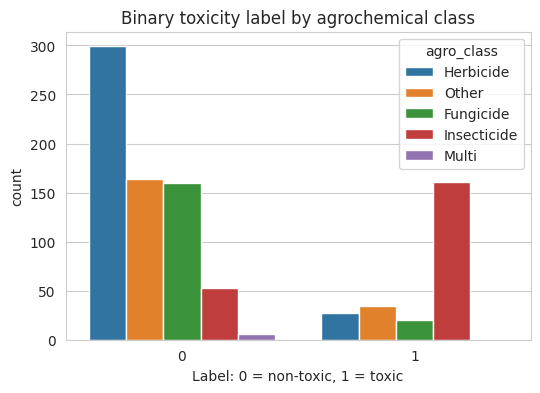

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='label', hue='agro_class')
plt.title('Binary toxicity label by agrochemical class')
plt.xlabel('Label: 0 = non-toxic, 1 = toxic')
plt.show()

**Step 6 — Molecular featurization with RDKit**

In [20]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, AllChem, DataStructs
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        'MolWt': Descriptors.MolWt(mol),
        'MolLogP': Crippen.MolLogP(mol),
        'NumHDonors': Lipinski.NumHDonors(mol),
        'NumHAcceptors': Lipinski.NumHAcceptors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'RingCount': Descriptors.RingCount(mol),
        'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'NumAliphaticRings': rdMolDescriptors.CalcNumAliphaticRings(mol),
        'NumSaturatedRings': rdMolDescriptors.CalcNumSaturatedRings(mol),
        'NumHeteroatoms': rdMolDescriptors.CalcNumHeteroatoms(mol),
    }

**6.2 Morgan fingerprints**

In [21]:
N_BITS = 2048
RADIUS = 2

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(N_BITS, dtype=int)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    arr = np.zeros((N_BITS,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

**6.3 Build feature matrix**

In [22]:
desc_df = df_clean['canonical_smiles'].apply(compute_descriptors).apply(pd.Series)
fp_df = pd.DataFrame([morgan_fp(s) for s in df_clean['canonical_smiles']])
fp_df.columns = [f'MorganFP_{i}' for i in range(fp_df.shape[1])]
X = pd.concat([desc_df, fp_df], axis=1).fillna(0)
y = df_clean['label'].values
feature_columns = X.columns.tolist()
print(X.shape, y.shape)

[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerator
[17:06:28] DEPRECATION WARNING: please use MorganGenerat

(925, 2061) (925,)


**Step 7 — Train/test split**

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(X_train.shape, X_test.shape)

(740, 2061) (185, 2061)


**Step 8 — Train AI models**

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
import xgboost as xgb
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}

for name, model in models.items():
    print(f'\n===== {name} =====')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print('ROC-AUC:', roc_auc_score(y_test, y_proba))
    print('PR-AUC :', average_precision_score(y_test, y_proba))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))

    trained_models[name] = model


===== RandomForest =====
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       136
           1       0.84      0.55      0.67        49

    accuracy                           0.85       185
   macro avg       0.85      0.76      0.79       185
weighted avg       0.85      0.85      0.84       185

ROC-AUC: 0.7926170468187276
PR-AUC : 0.7067487443799976
Confusion matrix:
[[131   5]
 [ 22  27]]

===== XGBoost =====
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       136
           1       0.79      0.53      0.63        49

    accuracy                           0.84       185
   macro avg       0.82      0.74      0.76       185
weighted avg       0.83      0.84      0.83       185

ROC-AUC: 0.796218487394958
PR-AUC : 0.6782874295109942
Confusion matrix:
[[129   7]
 [ 23  26]]


In [27]:
best_model = trained_models['RandomForest']

**Step 9 — Interpret the model**

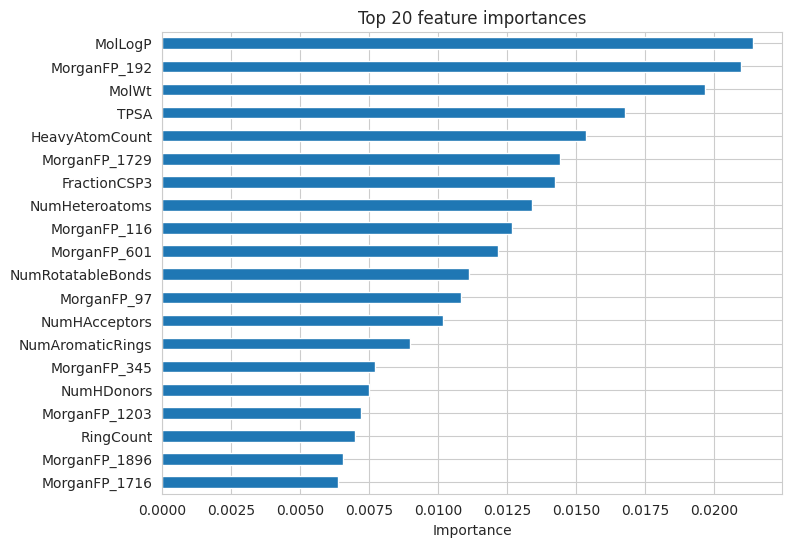

,0
MolLogP,0.021390
MorganFP_192,0.020971
MolWt,0.019645
TPSA,0.016769
HeavyAtomCount,0.015367
MorganFP_1729,0.014411
FractionCSP3,0.014242
NumHeteroatoms,0.013391
MorganFP_116,0.012678
MorganFP_601,0.012170


In [28]:
import matplotlib.pyplot as plt
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 feature importances')
plt.xlabel('Importance')
plt.show()
feat_imp.head(20)

In [29]:
best_model = trained_models['XGBoost']

In [ ]:
SHAP explanation


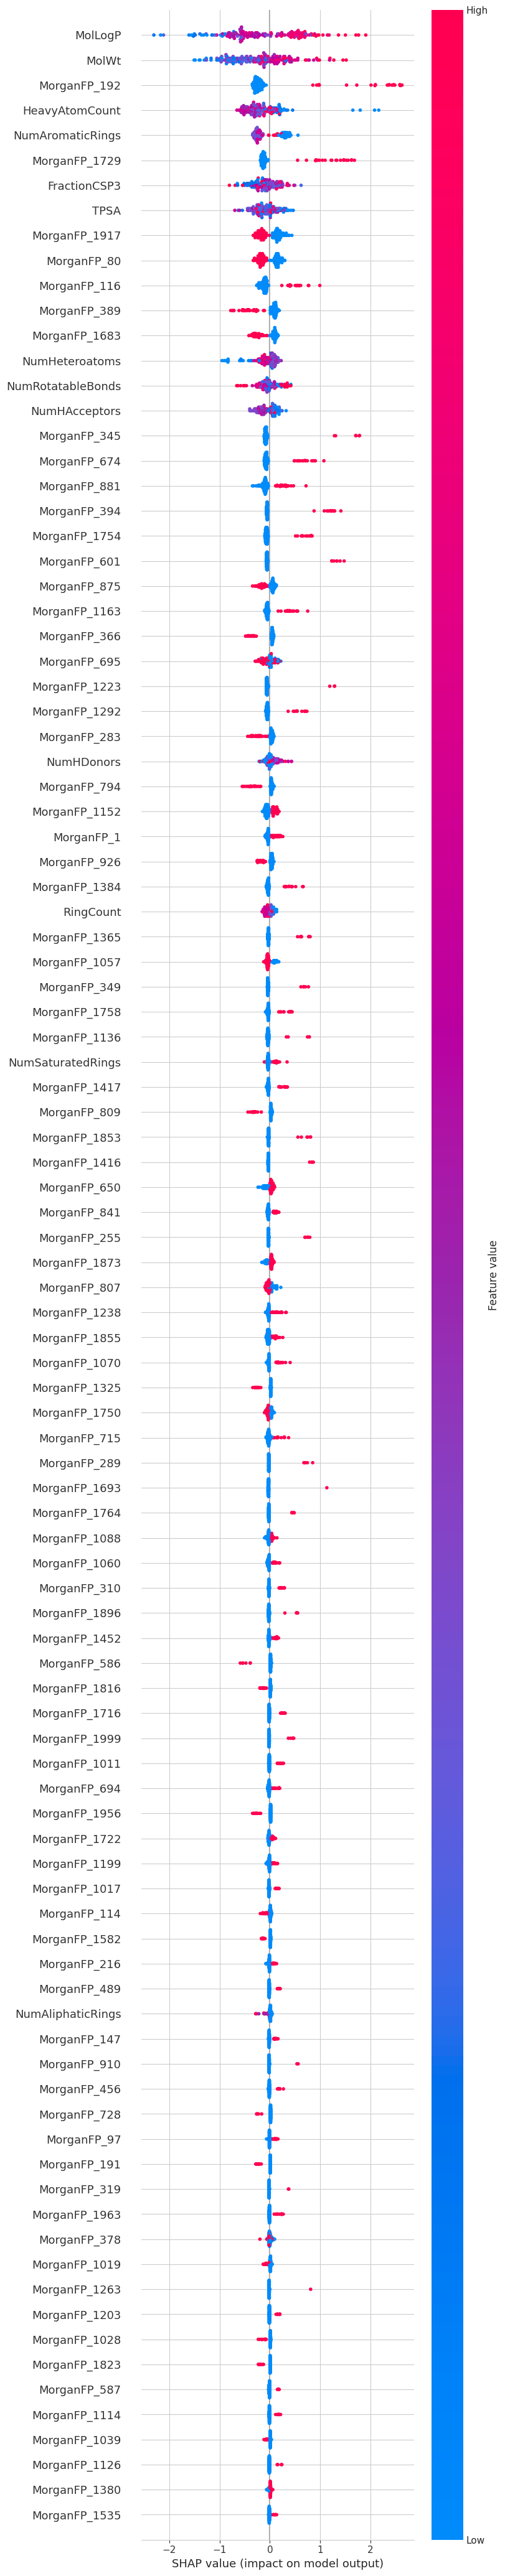

In [31]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:200])

if isinstance(shap_values, list):
    sv = shap_values[1]   # class 1 = toxic
else:
    sv = shap_values

shap.summary_plot(sv, X_test.iloc[:300], max_display=100)

**Step 11 — Predict new molecules**

In [32]:
def featurize_smiles(smiles):
    desc = compute_descriptors(smiles)
    fp = morgan_fp(smiles)
    row = {**desc}
    for i, v in enumerate(fp):
        row[f'MorganFP_{i}'] = v
    return row

def predict_smiles(smiles_list, model, feature_columns):
    rows = [featurize_smiles(s) for s in smiles_list]
    X_new = pd.DataFrame(rows).reindex(columns=feature_columns, fill_value=0)
    preds = model.predict(X_new)
    probs = model.predict_proba(X_new)[:, 1]
    return preds, probs

new_smiles = [
    'CC(=O)NP(=O)(OC)SC',          # Acephate example
    'C1=CC=C(C=C1)C=CC=O'          # Cinnamaldehyde example
]

preds, probs = predict_smiles(new_smiles, best_model, feature_columns)

for smi, p, prob in zip(new_smiles, preds, probs):
    print(f'{smi} -> label={p}, P(toxic)={prob:.3f}')

[17:08:43] DEPRECATION WARNING: please use MorganGenerator
[17:08:43] DEPRECATION WARNING: please use MorganGenerator


CC(=O)NP(=O)(OC)SC -> label=1, P(toxic)=0.997
C1=CC=C(C=C1)C=CC=O -> label=0, P(toxic)=0.001


In [33]:
import joblib

joblib.dump(best_model, 'honeybee_toxicity_model.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print('Saved: honeybee_toxicity_model.pkl')
print('Saved: feature_columns.pkl')

Saved: honeybee_toxicity_model.pkl
Saved: feature_columns.pkl


**Check missing values in the raw combined DataFrame**

In [35]:
def missing_report(df, name="DataFrame"):
    print(f"\n=== Missing values in {name} ===")
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if len(miss) == 0:
        print("No missing values.")
    else:
        print(miss)
    print(f"Total rows: {len(df)}")

missing_report(df, "raw combined")
missing_report(df_clean, "deduplicated")



=== Missing values in raw combined ===
No missing values.
Total rows: 1842

=== Missing values in deduplicated ===
No missing values.
Total rows: 925


**Compute descriptors with missing handling**

In [36]:
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, AllChem, DataStructs

def compute_descriptors_safe(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # Return dict of NaNs for all descriptor keys
        return {
            'MolWt': np.nan, 'MolLogP': np.nan, 'NumHDonors': np.nan,
            'NumHAcceptors': np.nan, 'TPSA': np.nan, 'NumRotatableBonds': np.nan,
            'RingCount': np.nan, 'HeavyAtomCount': np.nan, 'FractionCSP3': np.nan,
            'NumAromaticRings': np.nan, 'NumAliphaticRings': np.nan,
            'NumSaturatedRings': np.nan, 'NumHeteroatoms': np.nan,
        }
    try:
        return {
            'MolWt': Descriptors.MolWt(mol),
            'MolLogP': Crippen.MolLogP(mol),
            'NumHDonors': Lipinski.NumHDonors(mol),
            'NumHAcceptors': Lipinski.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol),
            'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
            'RingCount': Descriptors.RingCount(mol),
            'HeavyAtomCount': Descriptors.HeavyAtomCount(mol),
            'FractionCSP3': Descriptors.FractionCSP3(mol),
            'NumAromaticRings': rdMolDescriptors.CalcNumAromaticRings(mol),
            'NumAliphaticRings': rdMolDescriptors.CalcNumAliphaticRings(mol),
            'NumSaturatedRings': rdMolDescriptors.CalcNumSaturatedRings(mol),
            'NumHeteroatoms': rdMolDescriptors.CalcNumHeteroatoms(mol),
        }
    except Exception:
        return {k: np.nan for k in [
            'MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
            'NumRotatableBonds', 'RingCount', 'HeavyAtomCount', 'FractionCSP3',
            'NumAromaticRings', 'NumAliphaticRings', 'NumSaturatedRings', 'NumHeteroatoms'
        ]}

desc_df = df_clean['canonical_smiles'].apply(compute_descriptors_safe).apply(pd.Series)

print("Descriptor NaN counts:")
print(desc_df.isnull().sum()[desc_df.isnull().sum() > 0])

Descriptor NaN counts:
Series([], dtype: int64)


**Morgan fingerprints (missing bits are simply 0)**

In [37]:
N_BITS = 2048
RADIUS = 2

def morgan_fp_safe(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(N_BITS, dtype=int)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    arr = np.zeros((N_BITS,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_df = pd.DataFrame([morgan_fp_safe(s) for s in df_clean['canonical_smiles']])
fp_df.columns = [f'MorganFP_{i}' for i in range(fp_df.shape[1])]

print("Fingerprint shape:", fp_df.shape)

[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerator
[17:09:30] DEPRECATION WARNING: please use MorganGenerat

Fingerprint shape: (925, 2048)


**Combine descriptors + fingerprints**

In [39]:
X = pd.concat([desc_df, fp_df], axis=1)
y = df_clean['label'].values

print("Feature matrix shape:", X.shape)
print("Any NaN in features?", X.isnull().any().any())

Feature matrix shape: (925, 2061)
Any NaN in features? False


**Impute missing descriptors and train with a Pipeline**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=45
)

# Pipeline: impute NaNs with median, then RandomForest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fills descriptor NaNs
    ('clf', RandomForestClassifier(
        n_estimators=1800,
        class_weight='balanced',
        random_state=45,
        n_jobs=1
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       205
           1       0.89      0.53      0.67        73

    accuracy                           0.86       278
   macro avg       0.87      0.75      0.79       278
weighted avg       0.86      0.86      0.85       278

ROC-AUC: 0.8372870030070164


**Check which features were imputed**

In [41]:
imputer = pipeline.named_steps['imputer']
# Number of NaNs per column in training set
nan_counts = X_train.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]
print("Columns with NaNs in training set:")
print(nan_counts)

# After imputation, verify no NaNs
X_train_imputed = imputer.transform(X_train)
print("NaNs after imputation:", np.isnan(X_train_imputed).sum())

Columns with NaNs in training set:
Series([], dtype: int64)
NaNs after imputation: 0


**Drop columns that are entirely missing**

In [42]:
high_missing = X.columns[X.isnull().mean() > 0.9].tolist()
print("Columns with >90% missing:", high_missing)

X = X.drop(columns=high_missing)
print("New shape after dropping high-missing columns:", X.shape)

Columns with >90% missing: []
New shape after dropping high-missing columns: (925, 2061)


In [43]:
!pip install -q rdkit pandas numpy scikit-learn xgboost lightgbm shap joblib tqdm
!pip install -q transformers torch
# Optional: !pip install -q mordredcommunity

In [45]:

from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import (
    Descriptors, AllChem, MACCSkeys, rdmolops, DataStructs, Descriptors3D
)
from rdkit.Chem.AtomPairs import Pairs, Torsions

try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
except ImportError:
    HAS_AVALON = False

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score
)
import xgboost as xgb

**All RDKit 2D descriptors**

In [46]:
DESC_LIST = Descriptors._descList

def calc_rdkit_descriptors(mol):
    if mol is None:
        return {name: np.nan for name, _ in DESC_LIST}
    out = {}
    for name, func in DESC_LIST:
        try:
            out[name] = func(mol)
        except Exception:
            out[name] = np.nan
    return out

**Multiple fingerprints**

In [47]:
N_BITS = 2048

def calc_fingerprints(mol):
    if mol is None:
        return {
            'Morgan_r2': np.zeros(N_BITS, dtype=int),
            'Morgan_r3': np.zeros(N_BITS, dtype=int),
            'MACCS': np.zeros(167, dtype=int),
            'Avalon': np.zeros(N_BITS, dtype=int),
            'AtomPair': np.zeros(N_BITS, dtype=int),
            'Torsion': np.zeros(N_BITS, dtype=int),
            'RDKit': np.zeros(N_BITS, dtype=int),
        }

    fp = {}

    # Morgan radius 2 and 3
    for radius in [2, 3]:
        v = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=N_BITS)
        arr = np.zeros(N_BITS, dtype=int)
        DataStructs.ConvertToNumpyArray(v, arr)
        fp[f'Morgan_r{radius}'] = arr

    # MACCS keys (167 bits)
    maccs = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(167, dtype=int)
    DataStructs.ConvertToNumpyArray(maccs, arr)
    fp['MACCS'] = arr

    # Avalon
    if HAS_AVALON:
        avalon = pyAvalonTools.GetAvalonFP(mol, nBits=N_BITS)
        arr = np.zeros(N_BITS, dtype=int)
        DataStructs.ConvertToNumpyArray(avalon, arr)
        fp['Avalon'] = arr
    else:
        fp['Avalon'] = np.zeros(N_BITS, dtype=int)

    # AtomPair
    ap = Pairs.GetAtomPairFingerprintAsBitVect(mol, nBits=N_BITS)
    arr = np.zeros(N_BITS, dtype=int)
    DataStructs.ConvertToNumpyArray(ap, arr)
    fp['AtomPair'] = arr

    # Topological Torsion
    tt = Torsions.GetTopologicalTorsionFingerprintAsBitVect(mol, nBits=N_BITS)
    arr = np.zeros(N_BITS, dtype=int)
    DataStructs.ConvertToNumpyArray(tt, arr)
    fp['Torsion'] = arr

    # RDKit fingerprint
    rdkit_fp = rdmolops.RDKFingerprint(mol, fpSize=N_BITS)
    arr = np.zeros(N_BITS, dtype=int)
    DataStructs.ConvertToNumpyArray(rdkit_fp, arr)
    fp['RDKit'] = arr

    return fp

**3D descriptors**

In [48]:
DESC3D_KEYS = [
    'Asphericity', 'Eccentricity', 'InertialShapeFactor',
    'NPR1', 'NPR2', 'PMI1', 'PMI2', 'PMI3',
    'RadiusOfGyration', 'SpherocityIndex'
]

def calc_3d_descriptors(mol):
    if mol is None:
        return {k: np.nan for k in DESC3D_KEYS}

    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, randomSeed=42) != 0:
        return {k: np.nan for k in DESC3D_KEYS}

    out = {}
    try:
        out['Asphericity'] = Descriptors3D.Asphericity(mol)
        out['Eccentricity'] = Descriptors3D.Eccentricity(mol)
        out['InertialShapeFactor'] = Descriptors3D.InertialShapeFactor(mol)
        out['NPR1'] = Descriptors3D.NPR1(mol)
        out['NPR2'] = Descriptors3D.NPR2(mol)
        out['PMI1'] = Descriptors3D.PMI1(mol)
        out['PMI2'] = Descriptors3D.PMI2(mol)
        out['PMI3'] = Descriptors3D.PMI3(mol)
        out['RadiusOfGyration'] = Descriptors3D.RadiusOfGyration(mol)
        out['SpherocityIndex'] = Descriptors3D.SpherocityIndex(mol)
    except Exception:
        for k in DESC3D_KEYS:
            out.setdefault(k, np.nan)
    return out

**ChemBERTa embeddings (optional, but powerful)**

In [49]:
USE_CHEMBERTA = True   # set False if too slow

if USE_CHEMBERTA:
    from transformers import AutoTokenizer, AutoModel
    import torch

    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    model.eval()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    def chemberta_embedding(smiles, max_length=128):
        inputs = tokenizer(
            smiles, return_tensors="pt",
            padding=True, truncation=True, max_length=max_length
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        # CLS token embedding
        return outputs.last_hidden_state[:, 0, :].cpu().numpy().flatten()

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/9.43k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.21k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  179MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  179MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**Build the advanced feature matrix**

In [50]:
from rdkit.Chem import AllChem, MACCSkeys, rdmolops, DataStructs
from rdkit.Chem.AtomPairs import Pairs, Torsions

N_BITS = 2048

def _safe_bitvect_to_array(fp_getter, mol, n_bits, label):
    try:
        fp = fp_getter(mol, nBits=n_bits)
        arr = np.zeros(n_bits, dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except TypeError:
        # Newer RDKit: hashed variants
        try:
            if label == 'AtomPair':
                fp = Pairs.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=n_bits)
            elif label == 'Torsion':
                fp = Torsions.GetHashedTopologicalTorsionFingerprintAsBitVect(mol, nBits=n_bits)
            else:
                raise
            arr = np.zeros(n_bits, dtype=int)
            DataStructs.ConvertToNumpyArray(fp, arr)
            return arr
        except Exception:
            return np.zeros(n_bits, dtype=int)
    except Exception:
        return np.zeros(n_bits, dtype=int)
def calc_fingerprints(mol):
    if mol is None:
        return {
            'Morgan_r2': np.zeros(N_BITS, dtype=int),
            'Morgan_r3': np.zeros(N_BITS, dtype=int),
            'MACCS': np.zeros(167, dtype=int),
            'Avalon': np.zeros(N_BITS, dtype=int),
            'AtomPair': np.zeros(N_BITS, dtype=int),
            'Torsion': np.zeros(N_BITS, dtype=int),
            'RDKit': np.zeros(N_BITS, dtype=int),
        }

    fp = {}


    for radius in [2, 3]:
        try:
            from rdkit.Chem import rdFingerprintGenerator
            gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=N_BITS)
            v = gen.GetFingerprint(mol)
        except Exception:
            v = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=N_BITS)
        arr = np.zeros(N_BITS, dtype=int)
        DataStructs.ConvertToNumpyArray(v, arr)
        fp[f'Morgan_r{radius}'] = arr


    try:
        maccs = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros(167, dtype=int)
        DataStructs.ConvertToNumpyArray(maccs, arr)
        fp['MACCS'] = arr
    except Exception:
        fp['MACCS'] = np.zeros(167, dtype=int)
    if HAS_AVALON:
        try:
            avalon = pyAvalonTools.GetAvalonFP(mol, nBits=N_BITS)
            arr = np.zeros(N_BITS, dtype=int)
            DataStructs.ConvertToNumpyArray(avalon, arr)
            fp['Avalon'] = arr
        except Exception:
            fp['Avalon'] = np.zeros(N_BITS, dtype=int)
    else:
        fp['Avalon'] = np.zeros(N_BITS, dtype=int)


    fp['AtomPair'] = _safe_bitvect_to_array(
        Pairs.GetAtomPairFingerprintAsBitVect, mol, N_BITS, 'AtomPair'
    )


    fp['Torsion'] = _safe_bitvect_to_array(
        Torsions.GetTopologicalTorsionFingerprintAsBitVect, mol, N_BITS, 'Torsion'
    )


    try:
        rdkit_fp = rdmolops.RDKFingerprint(mol, fpSize=N_BITS)
        arr = np.zeros(N_BITS, dtype=int)
        DataStructs.ConvertToNumpyArray(rdkit_fp, arr)
        fp['RDKit'] = arr
    except Exception:
        fp['RDKit'] = np.zeros(N_BITS, dtype=int)

    return fp

**Handle missing values and train the model**

In [51]:
missing_frac = X.isnull().mean()
cols_to_drop = missing_frac[missing_frac > 0.9].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >90% missing")
X = X.drop(columns=cols_to_drop)
# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

print("Final feature matrix shape:", X.shape)
print("Any NaN?", X.isnull().any().any())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline with imputation + XGBoost
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

Dropping 0 columns with >90% missing
Final feature matrix shape: (925, 2061)
Any NaN? False
              precision    recall  f1-score   support

           0       0.84      0.93      0.89       136
           1       0.74      0.51      0.60        49

    accuracy                           0.82       185
   macro avg       0.79      0.72      0.74       185
weighted avg       0.81      0.82      0.81       185

ROC-AUC: 0.8038715486194479
PR-AUC : 0.6877188508001129


**Save the advanced pipeline**

In [52]:
import joblib

joblib.dump(pipeline, 'honeybee_toxicity_advanced_pipeline.pkl')
print("Saved: honeybee_toxicity_advanced_pipeline.pkl")

Saved: honeybee_toxicity_advanced_pipeline.pkl


 **Feature selection (if dimensionality is too high)**

In [53]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)
print("Shape after variance threshold:", X_selected.shape)

# Then re-run train/test split and pipeline on X_selected

Shape after variance threshold: (925, 664)


** Install extra librarie**s

In [54]:
!pip install -q umap-learn plotly kaleido yellowbrick


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.7 MB/s eta 0:00:00


**Add new engineered features**

In [63]:
from rdkit.Chem import Descriptors, Fragments, Lipinski, rdMolDescriptors
# SMARTS patterns for toxicologically relevant groups
SMARTS_PATTERNS = {
    # Toxicophores / reactive groups
    'nitro':            '[N+](=O)[O-]',
    'azo':              'N=N',
    'epoxide':          'C1OC1',
    'aldehyde':         '[CX3H1](=O)[#6]',
    'isocyanate':       'N=C=O',
    'isothiocyanate':   'N=C=S',
    'nitrile':          'C#N',
    'sulfonate':        'S(=O)(=O)O',
    'phosphate':        'P(=O)(O)(O)',
    'phosphorothioate': 'P(=S)(O)(O)',
    'carbamate':        'NC(=O)O',
    'organophosphate':  'OP(=O)(O)O',
    'halide_aromatic':  'c[F,Cl,Br,I]',
    'halide_aliphatic': '[CX4][F,Cl,Br,I]',
    'ester':            'C(=O)O[C]',
    'amide':            'C(=O)N',
    'urea':             'NC(=O)N',
    'ketone':           'C(=O)C',
    'ether':            'COC',
    'thioether':        'CSC',
    'pyridine':         'c1ccncc1',
    'pyrimidine':       'c1cncnc1',
    'triazine':         'c1ncncn1',
    'imidazole':        'c1cnc[nH]1',
    'triazole':         'c1ncnn1',
    'morpholine':       'C1COCCN1',
    'piperidine':       'C1CCNCC1',
    'benzene_ring':     'c1ccccc1',
}

COMPILED_PATTERNS = {k: Chem.MolFromSmarts(v) for k, v in SMARTS_PATTERNS.items()}

def calc_substructure_features(mol):
    if mol is None:
        return {f'has_{k}': 0 for k in SMARTS_PATTERNS} | \
               {f'count_{k}': 0 for k in SMARTS_PATTERNS}
    out = {}
    for name, patt in COMPILED_PATTERNS.items():
        if patt is None:
            out[f'has_{name}'] = 0
            out[f'count_{name}'] = 0
        else:
            matches = mol.GetSubstructMatches(patt)
            out[f'has_{name}'] = int(len(matches) > 0)
            out[f'count_{name}'] = len(matches)
    return out

**Drug‑likeness / rule‑based features**

In [62]:
def calc_druglikeness_features(mol):
    if mol is None:
        keys = ['Lipinski_violations', 'Veber_pass', 'Ghose_pass',
                'Egan_pass', 'Muegge_pass', 'QED', 'SA_score_approx',
                'FractionCSP3', 'Stereocenters', 'NumAmideBonds',
                'NumBridgehead', 'NumSpiro', 'NumAromaticHeterocycles',
                'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles']
        return {k: np.nan for k in keys}

    out = {}
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Lipinski.NumHDonors(mol)
    hba  = Lipinski.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rotb = Descriptors.NumRotatableBonds(mol)
    # Lipinski rule of 5
    violations = int(mw > 500) + int(logp > 5) + int(hbd > 5) + int(hba > 10)
    out['Lipinski_violations'] = violations
    # Veber
    out['Veber_pass'] = int(rotb <= 10 and tpsa <= 140)
    # Ghose
    out['Ghose_pass'] = int(160 <= mw <= 480 and -0.4 <= logp <= 5.6
                            and 20 <= Descriptors.HeavyAtomCount(mol) <= 70)
    # Egan
    out['Egan_pass'] = int(tpsa <= 131.6 and -1.5 <= logp <= 5.9)
    # Muegge
    out['Muegge_pass'] = int(
        200 <= mw <= 600 and -2 <= logp <= 5 and tpsa <= 150
        and rotb <= 15 and hbd <= 5 and hba <= 10
    )
    # QED
    try:
        from rdkit.Chem import QED
        out['QED'] = QED.qed(mol)
    except Exception:
        out['QED'] = np.nan
    # Crude SA proxy
    out['SA_score_approx'] = Descriptors.NumRotatableBonds(mol) / max(Descriptors.HeavyAtomCount(mol), 1)
    # Other
    out['FractionCSP3'] = Descriptors.FractionCSP3(mol)
    out['Stereocenters'] = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
    out['NumAmideBonds'] = rdMolDescriptors.CalcNumAmideBonds(mol)
    out['NumBridgehead'] = rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    out['NumSpiro'] = rdMolDescriptors.CalcNumSpiroAtoms(mol)
    out['NumAromaticHeterocycles'] = rdMolDescriptors.CalcNumAromaticHeterocycles(mol)
    out['NumSaturatedHeterocycles'] = rdMolDescriptors.CalcNumSaturatedHeterocycles(mol)
    out['NumAliphaticHeterocycles'] = rdMolDescriptors.CalcNumAliphaticHeterocycles(mol)

    return out

 **Element composition features**


In [64]:
def calc_element_features(mol):
    if mol is None:
        return {f'frac_{el}': np.nan for el in
                ['C','H','N','O','S','P','F','Cl','Br','I','Si','Sn','As','Hg','Cu','Zn','Mn']}
    counts = {}
    for atom in mol.GetAtoms():
        sym = atom.GetSymbol()
        counts[sym] = counts.get(sym, 0) + 1
    heavy = max(mol.GetNumHeavyAtoms(), 1)
    elements = ['C','H','N','O','S','P','F','Cl','Br','I','Si','Sn','As','Hg','Cu','Zn','Mn']
    return {f'frac_{el}': counts.get(el, 0) / heavy for el in elements}

**Recombine all features**

In [66]:
from tqdm.auto import tqdm
from rdkit.Chem import AllChem, Descriptors, Descriptors3D
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
# 1. Load + clean the source data -> df_clean (single source of truth)
df_raw = df.copy() if 'df' in globals() else pd.read_csv("your_file.csv")
# Keep only useful columns
keep_cols = [
    'name', 'CID', 'CAS', 'SMILES', 'source', 'toxicity_type',
    'herbicide', 'fungicide', 'insecticide', 'other_agrochemical',
    'label', 'ppdb_level', 'source_file',
]
df_raw = df_raw[[c for c in keep_cols if c in df_raw.columns]].copy()

# Numeric coercion
for col in ['herbicide', 'fungicide', 'insecticide',
            'other_agrochemical', 'label', 'ppdb_level']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Drop rows without SMILES or label
df_clean = df_raw.dropna(subset=['SMILES', 'label']).copy()
df_clean['label'] = df_clean['label'].astype(int)

# Canonicalize SMILES
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except Exception:
        return None

df_clean['canonical_smiles'] = df_clean['SMILES'].apply(canonicalize_smiles)
df_clean = df_clean[df_clean['canonical_smiles'].notna()].copy()
df_clean = df_clean.reset_index(drop=True)
N = len(df_clean)
print(f"df_clean: {df_clean.shape}")
print(df_clean[['name', 'canonical_smiles', 'label']].head())

y = df_clean['label'].to_numpy()   # labels built from the SAME rows as features
print("labels:", y.shape, "| positives:", int((y == 1).sum()))
# 2. 2D descriptors
DESC2D_FUNCS = {name: fn for name, fn in Descriptors.descList}

def compute_2d(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {k: np.nan for k in DESC2D_FUNCS}
    out = {}
    for k, fn in DESC2D_FUNCS.items():
        try:
            out[k] = fn(mol)
        except Exception:
            out[k] = np.nan
    return out

desc_rows = [compute_2d(s) for s in tqdm(df_clean['canonical_smiles'],
                                         desc='2D desc')]
desc_df = pd.DataFrame(desc_rows, index=df_clean.index).reset_index(drop=True)
assert len(desc_df) == N
print("desc_df:", desc_df.shape)
# 3. 3D descriptors (embed + optimize; NaN on failure)
DESC3D_NAMES = ['Asphericity', 'Eccentricity', 'InertialShapeFactor',
                'NPR1', 'NPR2', 'PMI1', 'PMI2', 'PMI3',
                'RadiusOfGyration', 'SpherocityIndex']

def compute_3d(smi):
    nan_row = {k: np.nan for k in DESC3D_NAMES}
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return nan_row
        mol = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        if AllChem.EmbedMolecule(mol, params) != 0:
            if AllChem.EmbedMolecule(mol, useRandomCoords=True,
                                     randomSeed=42) != 0:
                return nan_row
        try:
            AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
        except Exception:
            pass
        return {
            'Asphericity':          Descriptors3D.Asphericity(mol),
            'Eccentricity':         Descriptors3D.Eccentricity(mol),
            'InertialShapeFactor':  Descriptors3D.InertialShapeFactor(mol),
            'NPR1':                 Descriptors3D.NPR1(mol),
            'NPR2':                 Descriptors3D.NPR2(mol),
            'PMI1':                 Descriptors3D.PMI1(mol),
            'PMI2':                 Descriptors3D.PMI2(mol),
            'PMI3':                 Descriptors3D.PMI3(mol),
            'RadiusOfGyration':     Descriptors3D.RadiusOfGyration(mol),
            'SpherocityIndex':      Descriptors3D.SpherocityIndex(mol),
        }
    except Exception:
        return nan_row

desc3d_rows = [compute_3d(s) for s in tqdm(df_clean['canonical_smiles'],
                                           desc='3D desc')]
desc3d_df = pd.DataFrame(desc3d_rows, index=df_clean.index).reset_index(drop=True)
assert len(desc3d_df) == N
print("desc3d_df:", desc3d_df.shape,
      "| all-NaN rows:", int(desc3d_df.isnull().all(axis=1).sum()))

# 4. Morgan fingerprints (ECFP4, 2048 bits)
morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def compute_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(2048, dtype=np.uint8)
    fp = morgan.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_rows = [compute_fp(s) for s in tqdm(df_clean['canonical_smiles'],
                                       desc='Morgan FP')]
fp_df = pd.DataFrame(
    fp_rows,
    columns=[f'morgan_{i}' for i in range(2048)],
    index=df_clean.index,
).reset_index(drop=True)
assert len(fp_df) == N
print("fp_df:", fp_df.shape)
# 5. Engineered features (edit to match your own new_feat_df)
def compute_new_feats(row):
    smi = row['canonical_smiles']
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {'mw': np.nan, 'logp': np.nan, 'tpsa': np.nan,
                'hbd': np.nan, 'hba': np.nan, 'rotb': np.nan,
                'n_heavy': np.nan, 'n_rings': np.nan, 'n_arom_rings': np.nan,
                'frac_csp3': np.nan}
    return {
        'mw':            Descriptors.MolWt(mol),
        'logp':          Descriptors.MolLogP(mol),
        'tpsa':          Descriptors.TPSA(mol),
        'hbd':           Descriptors.NumHDonors(mol),
        'hba':           Descriptors.NumHAcceptors(mol),
        'rotb':          Descriptors.NumRotatableBonds(mol),
        'n_heavy':       mol.GetNumHeavyAtoms(),
        'n_rings':       Descriptors.RingCount(mol),
        'n_arom_rings':  Descriptors.NumAromaticRings(mol),
        'frac_csp3':     Descriptors.FractionCSP3(mol),
    }

new_feat_df = pd.DataFrame(
    [compute_new_feats(r) for _, r in df_clean.iterrows()],
    index=df_clean.index,
).reset_index(drop=True)
assert len(new_feat_df) == N
print("new_feat_df:", new_feat_df.shape)
# 6. Optional ChemBERTa embeddings
USE_CHEMBERTA = False       # flip to True only if you build chemberta_df below
chemberta_df = None

if USE_CHEMBERTA:
    # import torch
    # tok = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
    # mdl = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1").eval()
    # embs = []
    # with torch.no_grad():
    #     for smi in tqdm(df_clean['canonical_smiles'], desc='ChemBERTa'):
    #         enc = tok(smi, return_tensors='pt', truncation=True, max_length=128)
    #         out = mdl(**enc).last_hidden_state.mean(dim=1).squeeze(0).numpy()
    #         embs.append(out)
    # chemberta_df = pd.DataFrame(
    #     np.vstack(embs),
    #     columns=[f'chemberta_{i}' for i in range(embs[0].shape[0])],
    #     index=df_clean.index,
    # ).reset_index(drop=True)
    # assert len(chemberta_df) == N
    pass
# 7. Alignment guard — fail loudly before concat
def assert_same_rows(objs: dict, n: int):
    bad = {k: len(v) for k, v in objs.items() if v is not None and len(v) != n}
    if bad:
        raise ValueError(
            f"Row-count mismatch (expected {n}): {bad}. "
            "Rebuild the offending frame from df_clean."
        )

assert_same_rows(
    {'desc_df': desc_df, 'desc3d_df': desc3d_df, 'fp_df': fp_df,
     'new_feat_df': new_feat_df, 'chemberta_df': chemberta_df,
     'y': y},
    N,
)
# 8. Build the full feature matrix
def _align(x):
    return x.reset_index(drop=True) if x is not None else None

desc_df, desc3d_df, fp_df, new_feat_df = map(
    _align, [desc_df, desc3d_df, fp_df, new_feat_df]
)
chemberta_df = _align(chemberta_df)

parts = [desc_df]
if desc3d_df is not None and not desc3d_df.empty:
    parts.append(desc3d_df)
else:
    print("[warn] desc3d_df unavailable — using 2D + FP only")
parts.append(fp_df)

X_advanced = pd.concat(parts, axis=1)

if USE_CHEMBERTA and chemberta_df is not None:
    X_advanced = pd.concat([X_advanced, chemberta_df], axis=1)

X_full = pd.concat([X_advanced, new_feat_df], axis=1).reset_index(drop=True)
y = df_clean['label'].to_numpy()

assert len(X_full) == len(y), (len(X_full), len(y))
# Replace inf BEFORE measuring missingness
X_full = X_full.replace([np.inf, -np.inf], np.nan)
# Drop >90% missing columns
missing_frac = X_full.isnull().mean()
cols_to_drop = missing_frac[missing_frac > 0.9].index.tolist()
X_full = X_full.drop(columns=cols_to_drop)
# Drop constant + duplicate columns (defensive)
nunique = X_full.nunique(dropna=True)
const_cols = nunique[nunique <= 1].index.tolist()
X_full = X_full.drop(columns=const_cols)
X_full = X_full.loc[:, ~X_full.columns.duplicated()]

print(f"X_full: {X_full.shape}  |  "
      f"dropped >90% NaN: {len(cols_to_drop)}  |  "
      f"dropped constant: {len(const_cols)}  |  "
      f"y: {y.shape}")
# 9. Sanity check — no infinite values, correct shapes
assert np.isfinite(X_full.select_dtypes(include=[np.number]).to_numpy(
    na_value=0.0)).all(), "Non-finite values still present"
assert X_full.shape[0] == y.shape[0]

print("Pipeline OK.")

df_clean: (1842, 14)
                                        name       canonical_smiles  label
0                     (E)-dec-5-enyl acetate     CCCCC=CCCCCOC(C)=O      0
1                   (E)-dodec-8-enyl acetate   CCCC=CCCCCCCCOC(C)=O      0
2  (Z)-dodec-8-enyl acetate (Ref: BAS 284 I)   CCCC=CCCCCCCCOC(C)=O      1
3                1,7-dioxaspiro(5.5)undecane      C1CCC2(CCCCO2)OC1      0
4                                1,8-cineole  CC12CCC(CC1)C(C)(C)O2      0
labels: (1842,) | positives: 504


2D desc:   0%|          | 0/1842 [00:00<?, ?it/s]

desc_df: (1842, 217)


3D desc:   0%|          | 0/1842 [00:00<?, ?it/s]

[17:15:29] UFFTYPER: Warning: hybridization set to SP3 for atom 0
[17:15:29] UFFTYPER: Unrecognized charge state for atom: 0
[17:15:29] UFFTYPER: Warning: hybridization set to SP3 for atom 0
[17:15:29] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[17:15:30] UFFTYPER: Unrecognized atom type: B_1 (1)
[17:15:30] UFFTYPER: Unrecognized atom type: B_1 (9)
[17:15:30] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[17:15:30] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[17:15:30] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[17:15:30] UFFTYPER: Unrecognized atom type: Ca+2 (0)
[17:15:41] UFFTYPER: Unrecognized atom type: Cu5+1 (0)
[17:15:41] UFFTYPER: Unrecognized atom type: Cu5+1 (0)
[17:15:41] UFFTYPER: Unrecognized atom type: Cu6+1 (1)
[17:15:41] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[17:15:41] UFFTYPER: Unrecognized charge state for atom: 1
[17:15:45] UFFTYPER: Unrecognized atom type: Fe2+2 (0)
[17:15:46] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[17:15:46]

desc3d_df: (1842, 10) | all-NaN rows: 0


[17:17:44] UFFTYPER: Unrecognized charge state for atom: 0
[17:17:44] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[17:17:44] UFFTYPER: Unrecognized charge state for atom: 0
[17:17:44] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[17:17:44] UFFTYPER: Unrecognized charge state for atom: 0
[17:17:44] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[17:17:44] UFFTYPER: Unrecognized charge state for atom: 0
[17:17:44] UFFTYPER: Unrecognized atom type: Zn+2 (0)
[17:17:44] UFFTYPER: Unrecognized charge state for atom: 0
[17:17:44] UFFTYPER: Unrecognized atom type: Zn+2 (0)


Morgan FP:   0%|          | 0/1842 [00:00<?, ?it/s]

fp_df: (1842, 2048)
new_feat_df: (1842, 10)
X_full: (1842, 2187)  |  dropped >90% NaN: 0  |  dropped constant: 98  |  y: (1842,)
Pipeline OK.


**Dimensionality reduction for visualization**



In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Impute for visualization only
from sklearn.impute import SimpleImputer
X_vis = SimpleImputer(strategy='median').fit_transform(X_full)
X_vis = StandardScaler().fit_transform(X_vis)

# PCA
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_vis)
print("Explained variance (first 10):", pca.explained_variance_ratio_[:10])

# t-SNE (2D & 3D)
tsne2 = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne2 = tsne2.fit_transform(X_pca50[:, :20])

tsne3 = TSNE(n_components=3, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne3 = tsne3.fit_transform(X_pca50[:, :20])

# UMAP (2D & 3D)
umap2 = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap2 = umap2.fit_transform(X_pca50[:, :20])

umap3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap3 = umap3.fit_transform(X_pca50[:, :20])

print("Done: PCA, t-SNE, UMAP")

Explained variance (first 10): [0.02462456 0.01413779 0.01215108 0.00893984 0.00841011 0.00804876
 0.00732261 0.0071617  0.00713302 0.00678962]


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Done: PCA, t-SNE, UMAP


**PCA / t‑SNE / UMAP (2D) side by side**

**Class distribution**

agro_class value counts:
agro_class
Herbicide      671
Insecticide    442
Fungicide      370
Other          343
Multi           16
Name: count, dtype: int64

Columns now: ['name', 'CID', 'CAS', 'SMILES', 'source', 'toxicity_type', 'herbicide', 'fungicide', 'insecticide', 'other_agrochemical', 'label', 'ppdb_level', 'source_file', 'canonical_smiles', 'agro_class']

✔ len(y) = 1842  |  df_clean rows = 1842


/tmp/ipykernel_1056/1920349483.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_1056/1920349483.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='agro_class', order=order,
/tmp/ipykernel_1056/1920349483.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=ppdb, ax=axes[2], palette='magma')


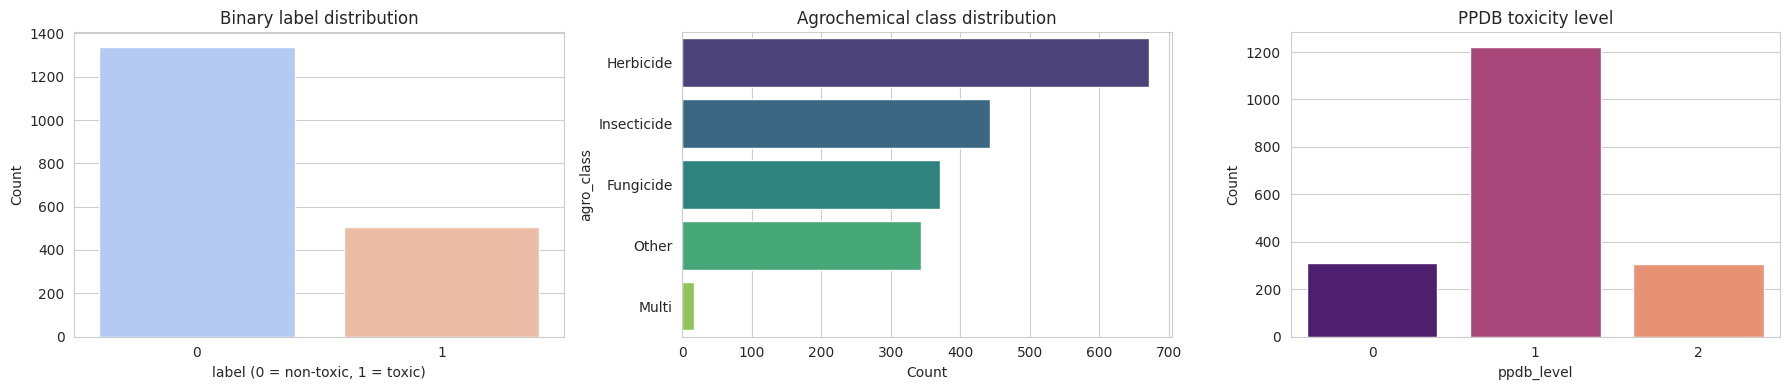

In [71]:
for col in ['herbicide', 'fungicide', 'insecticide', 'other_agrochemical']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

# 2. Recreate agro_class
def get_agro_class(row):
    classes = []
    if row.get('herbicide', 0) == 1:            classes.append('Herbicide')
    if row.get('fungicide', 0) == 1:            classes.append('Fungicide')
    if row.get('insecticide', 0) == 1:          classes.append('Insecticide')
    if row.get('other_agrochemical', 0) == 1:   classes.append('Other')
    if len(classes) == 0:   return 'Unknown'
    if len(classes) == 1:   return classes[0]
    return 'Multi'

df_clean['agro_class'] = df_clean.apply(get_agro_class, axis=1)

# Sanity check
print("agro_class value counts:")
print(df_clean['agro_class'].value_counts())
print()
print("Columns now:", df_clean.columns.tolist())

# 3. Also make sure y is a plain numpy array
y = np.asarray(df_clean['label'].values).astype(int).ravel()
assert len(y) == len(df_clean), f"len(y)={len(y)}, len(df_clean)={len(df_clean)}"
print(f"\n✔ len(y) = {len(y)}  |  df_clean rows = {len(df_clean)}")

# ---------- 4. Plot ----------
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Binary label distribution
sns.countplot(x=y, ax=axes[0], palette='coolwarm')
axes[0].set_title('Binary label distribution')
axes[0].set_xlabel('label (0 = non-toxic, 1 = toxic)')
axes[0].set_ylabel('Count')

# (b) Agrochemical class
order = df_clean['agro_class'].value_counts().index
sns.countplot(data=df_clean, y='agro_class', order=order,
              ax=axes[1], palette='viridis')
axes[1].set_title('Agrochemical class distribution')
axes[1].set_xlabel('Count')

# (c) PPDB toxicity level
if 'ppdb_level' in df_clean.columns:
    ppdb = df_clean['ppdb_level'].fillna(-1).astype(int)
    sns.countplot(x=ppdb, ax=axes[2], palette='magma')
    axes[2].set_title('PPDB toxicity level')
    axes[2].set_xlabel('ppdb_level')
    axes[2].set_ylabel('Count')
else:
    axes[2].text(0.5, 0.5, 'ppdb_level not available',
                 ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

Correlation heatmap of top **descriptors**

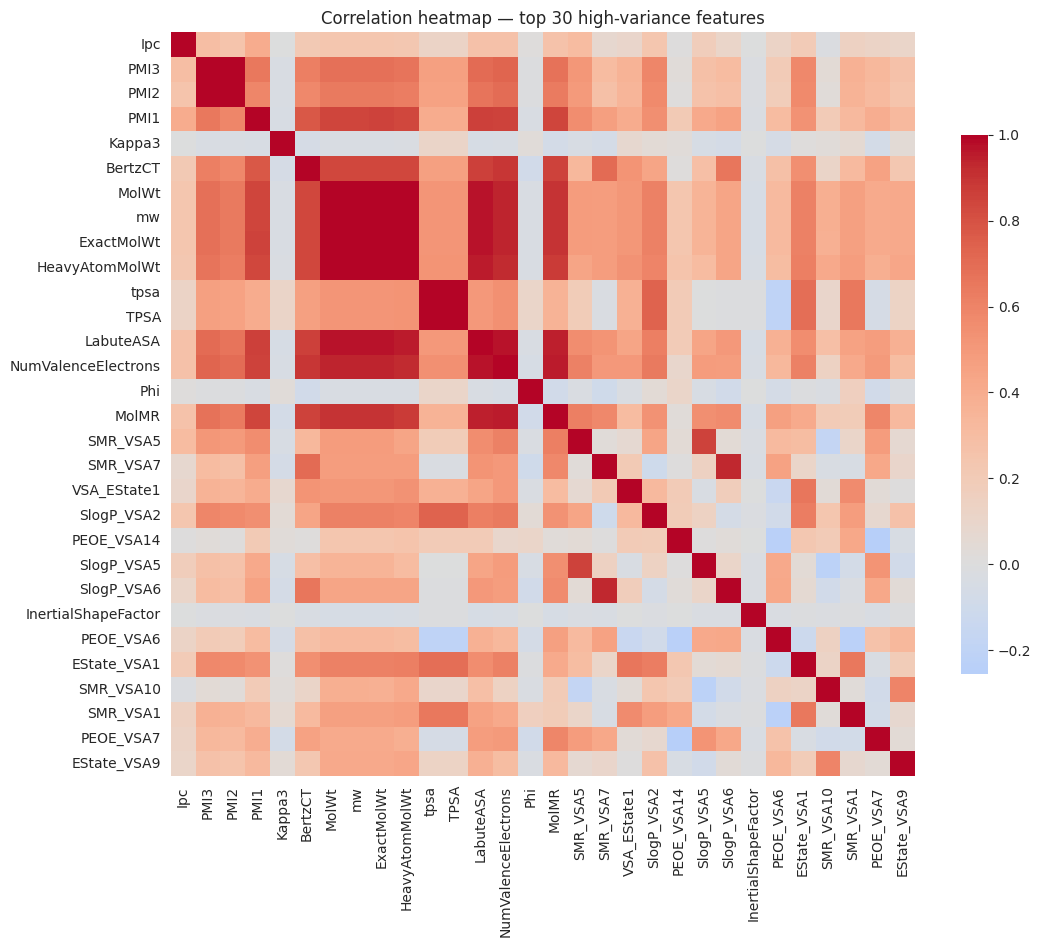

In [72]:
# Take the first 30 RDKit descriptors (or top variance features)
top_features = X_full.var().sort_values(ascending=False).head(30).index.tolist()
corr = X_full[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False,
            square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation heatmap — top 30 high-variance features')
plt.show()

**Feature importance (after training)**

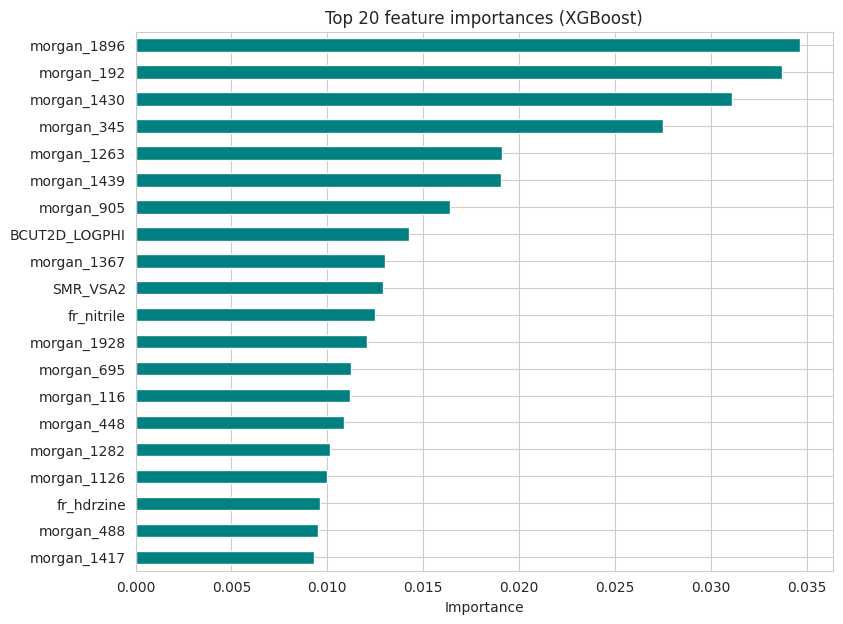

In [73]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

clf = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

importances = pd.Series(clf.feature_importances_, index=X_full.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
top20.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 20 feature importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

**3D PCA / t‑SNE / UMAP (matplotlib)**

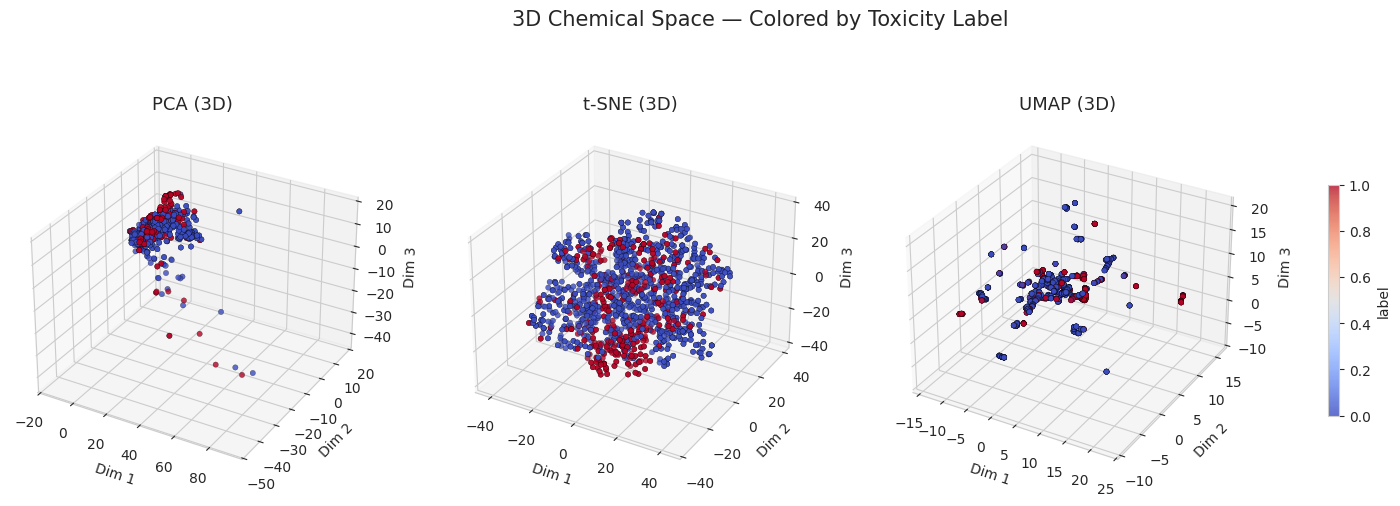

In [74]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(20, 6))
data3d = [X_pca50[:, :3], X_tsne3, X_umap3]
titles = ['PCA (3D)', 't-SNE (3D)', 'UMAP (3D)']

for i, (data, title) in enumerate(zip(data3d, titles), 1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    sc = ax.scatter(data[:, 0], data[:, 1], data[:, 2],
                    c=y, cmap='coolwarm', s=15, alpha=0.8,
                    edgecolors='k', linewidths=0.2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')

fig.colorbar(sc, ax=fig.axes, shrink=0.5, label='label')
plt.suptitle("3D Chemical Space — Colored by Toxicity Label", fontsize=15)
plt.show()

**Interactive 3D with Plotly (rotate, zoom, hover)**

In [75]:
import plotly.express as px
import plotly.graph_objects as go

plot_df = pd.DataFrame({
    'PC1': X_pca50[:, 0],
    'PC2': X_pca50[:, 1],
    'PC3': X_pca50[:, 2],
    'tSNE1': X_tsne3[:, 0],
    'tSNE2': X_tsne3[:, 1],
    'tSNE3': X_tsne3[:, 2],
    'UMAP1': X_umap3[:, 0],
    'UMAP2': X_umap3[:, 1],
    'UMAP3': X_umap3[:, 2],
    'label': y.astype(str),
    'name': df_clean['name'].values,
    'smiles': df_clean['canonical_smiles'].values,
})

# --- 3D PCA ---
fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3',
    color='label', hover_data=['name'],
    color_discrete_map={'0': '#1f77b4', '1': '#d62728'},
    title='Interactive 3D PCA — Honey-bee toxicity'
)
fig.update_traces(marker=dict(size=4, opacity=0.8,
                              line=dict(width=0.3, color='black')))
fig.show()

# --- 3D t-SNE ---
fig = px.scatter_3d(
    plot_df, x='tSNE1', y='tSNE2', z='tSNE3',
    color='label', hover_data=['name'],
    color_discrete_map={'0': '#1f77b4', '1': '#d62728'},
    title='Interactive 3D t-SNE — Honey-bee toxicity'
)
fig.update_traces(marker=dict(size=4, opacity=0.8,
                              line=dict(width=0.3, color='black')))
fig.show()

# --- 3D UMAP ---
fig = px.scatter_3d(
    plot_df, x='UMAP1', y='UMAP2', z='UMAP3',
    color='label', hover_data=['name'],
    color_discrete_map={'0': '#1f77b4', '1': '#d62728'},
    title='Interactive 3D UMAP — Honey-bee toxicity'
)
fig.update_traces(marker=dict(size=4, opacity=0.8,
                              line=dict(width=0.3, color='black')))
fig.show()

/usr/local/lib/python3.13/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




**Combined 2D + 3D mega figure**

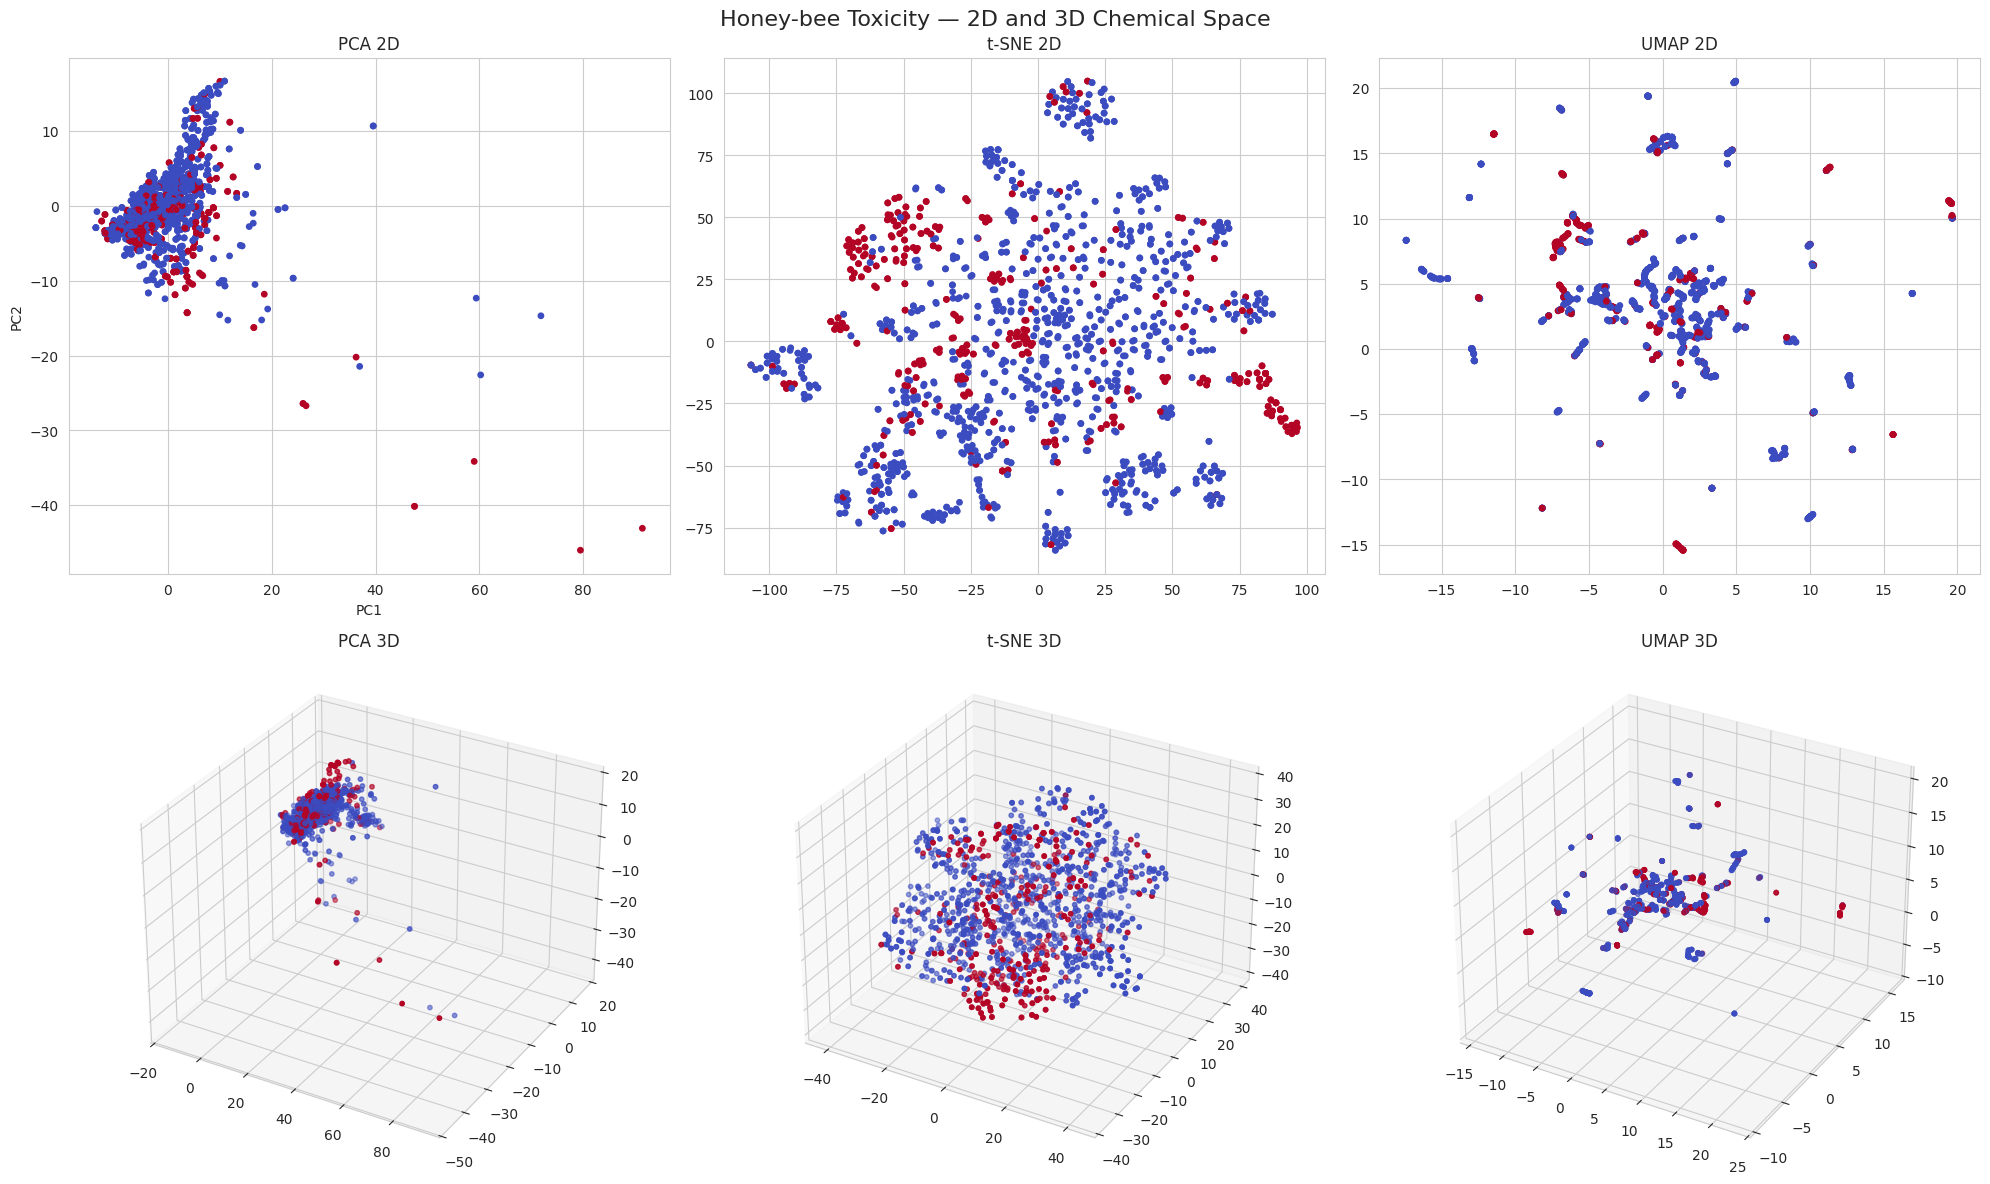

In [76]:
fig = plt.figure(figsize=(20, 12))

# Row 1: 2D plots
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(X_pca50[:, 0], X_pca50[:, 1], c=y, cmap='coolwarm', s=15)
ax1.set_title('PCA 2D'); ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2 = fig.add_subplot(2, 3, 2)
ax2.scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=y, cmap='coolwarm', s=15)
ax2.set_title('t-SNE 2D')

ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(X_umap2[:, 0], X_umap2[:, 1], c=y, cmap='coolwarm', s=15)
ax3.set_title('UMAP 2D')

# Row 2: 3D plots
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.scatter(X_pca50[:, 0], X_pca50[:, 1], X_pca50[:, 2], c=y, cmap='coolwarm', s=10)
ax4.set_title('PCA 3D')

ax5 = fig.add_subplot(2, 3, 5, projection='3d')
ax5.scatter(X_tsne3[:, 0], X_tsne3[:, 1], X_tsne3[:, 2], c=y, cmap='coolwarm', s=10)
ax5.set_title('t-SNE 3D')

ax6 = fig.add_subplot(2, 3, 6, projection='3d')
ax6.scatter(X_umap3[:, 0], X_umap3[:, 1], X_umap3[:, 2], c=y, cmap='coolwarm', s=10)
ax6.set_title('UMAP 3D')

plt.suptitle("Honey-bee Toxicity — 2D and 3D Chemical Space", fontsize=16)
plt.tight_layout()
plt.show()

In [77]:
!pip install -q mordredcommunity


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 3.6 MB/s eta 0:00:00


**Extended fingerprints**

**Advanced RDKit descriptors (via mordred)**

In [79]:
# Mordred descriptors — includes MQN, BCUT2D, Autocorrelation,
# WHIM, GETAWAY, RDF, 3D-MoRSE, CPSA, complexity, etc.
MR_DESC = None

def init_mordred():
    global MR_DESC
    if MR_DESC is not None:
        return MR_DESC
    try:
        from mordred import Calculator
        from mordred import (
            BCUT, Autocorrelation, WHIM, GETAWAY, RDF, MoRSE,
            CPSA, Constitutional, GeometricalIndex, InformationContent,
            PathCount, AcidBase, Aromatic, AtomCount, BondCount,
            CarbonTypes, Chi, DetourMatrix, DistanceMatrix, EState,
            FragmentComplexity, Framework, HydrogenBond, LinkerCount,
            LogS, MoeType, MolecularDistanceEdge, PBF, Polarizability,
            RotatableBond, Rings, SLogP, TopologicalIndex, Weight
        )
        MR_DESC = Calculator([
            BCUT, Autocorrelation, WHIM, GETAWAY, RDF, MoRSE,
            CPSA, Constitutional, GeometricalIndex, InformationContent,
            PathCount, AcidBase, Aromatic, AtomCount, BondCount,
            CarbonTypes, Chi, DetourMatrix, DistanceMatrix, EState,
            FragmentComplexity, Framework, HydrogenBond, LinkerCount,
            LogS, MoeType, MolecularDistanceEdge, PBF, Polarizability,
            RotatableBond, Rings, SLogP, TopologicalIndex, Weight,
        ], ignore_3D=True)
        print("Mordred initialized.")
    except Exception as e:
        print("Mordred not available:", e)
        MR_DESC = None
    return MR_DESC

def calc_mordred(mol):
    if mol is None or MR_DESC is None:
        return {}
    try:
        vals = MR_DESC(mol)
        return {str(k): (float(v) if v is not None and np.isfinite(float(v)) else np.nan)
                for k, v in vals.items()}
    except Exception:
        return {}

**Structural alerts (BRENK, PAINS, NIH, ChEMBL)**

In [80]:
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams

def build_alert_catalogs():
    catalogs = {}
    for name, flag in [
        ('BRENK',   FilterCatalogParams.FilterCatalogs.BRENK),
        ('PAINS_A', FilterCatalogParams.FilterCatalogs.PAINS_A),
        ('PAINS_B', FilterCatalogParams.FilterCatalogs.PAINS_B),
        ('PAINS_C', FilterCatalogParams.FilterCatalogs.PAINS_C),
        ('NIH',     FilterCatalogParams.FilterCatalogs.NIH),
        ('ZINC',    FilterCatalogParams.FilterCatalogs.ZINC),
    ]:
        p = FilterCatalogParams()
        p.AddCatalog(flag)
        catalogs[name] = FilterCatalog.FilterCatalog(p)
    return catalogs

ALERT_CATALOGS = build_alert_catalogs()
print("Alert catalogs:", list(ALERT_CATALOGS.keys()))

def calc_alert_features(mol):
    out = {}
    if mol is None:
        for name in ALERT_CATALOGS:
            out[f'alert_{name}_match'] = 0
            out[f'alert_{name}_count'] = 0
        return out
    for name, cat in ALERT_CATALOGS.items():
        try:
            matches = cat.GetMatches(mol)
            out[f'alert_{name}_match'] = int(len(matches) > 0)
            out[f'alert_{name}_count'] = len(matches)
        except Exception:
            out[f'alert_{name}_match'] = 0
            out[f'alert_{name}_count'] = 0
    return out

Alert catalogs: ['BRENK', 'PAINS_A', 'PAINS_B', 'PAINS_C', 'NIH', 'ZINC']


**Charge / electronic features**

In [81]:
from rdkit.Chem import AllChem

def calc_charge_features(mol):
    keys = ['gasteiger_min', 'gasteiger_max', 'gasteiger_mean', 'gasteiger_std',
            'gasteiger_sum_pos', 'gasteiger_sum_neg',
            'formal_charge_total', 'formal_charge_abs_sum',
            'num_positive_atoms', 'num_negative_atoms']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        AllChem.ComputeGasteigerCharges(mol)
        charges = np.array([float(a.GetDoubleProp('_GasteigerCharge'))
                            for a in mol.GetAtoms()])
        charges = np.nan_to_num(charges, nan=0.0, posinf=0.0, neginf=0.0)
    except Exception:
        charges = np.zeros(mol.GetNumAtoms())

    formal = np.array([a.GetFormalCharge() for a in mol.GetAtoms()])
    return {
        'gasteiger_min':        charges.min() if len(charges) else 0.0,
        'gasteiger_max':        charges.max() if len(charges) else 0.0,
        'gasteiger_mean':       charges.mean() if len(charges) else 0.0,
        'gasteiger_std':        charges.std()  if len(charges) else 0.0,
        'gasteiger_sum_pos':    charges[charges > 0].sum(),
        'gasteiger_sum_neg':    charges[charges < 0].sum(),
        'formal_charge_total':  int(formal.sum()),
        'formal_charge_abs_sum': int(np.abs(formal).sum()),
        'num_positive_atoms':   int((formal > 0).sum()),
        'num_negative_atoms':   int((formal < 0).sum()),
    }

**Graph / topological features**

In [ ]:
import networkx as nx
from rdkit.Chem import rdmolops

def calc_graph_features(mol):
    keys = ['graph_degree_mean', 'graph_degree_std', 'graph_degree_max',
            'graph_num_edges', 'graph_num_nodes',
            'graph_density', 'graph_diameter',
            'graph_avg_shortest_path', 'graph_clustering_coeff',
            'graph_num_cycles', 'graph_wiener_index',
            'graph_zagreb1', 'graph_zagreb2', 'graph_randic',
            'graph_balaban', 'graph_bertz_complexity',
            'graph_num_rings_sssr', 'graph_num_aromatic_rings',
            'graph_num_ring_systems', 'graph_max_ring_size',
            'graph_num_fused_rings', 'graph_num_spiro_atoms']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        G = nx.Graph()
        for a in mol.GetAtoms():
            G.add_node(a.GetIdx(), symbol=a.GetSymbol(),
                       degree=a.GetDegree(), aromatic=a.GetIsAromatic())
        for b in mol.GetBonds():
            G.add_edge(b.GetBeginAtomIdx(), b.GetEndAtomIdx())
    except Exception:
        return {k: np.nan for k in keys}

    deg = np.array([d for _, d in G.degree()], dtype=float)
    out = {}
    out['graph_degree_mean']  = deg.mean() if len(deg) else np.nan
    out['graph_degree_std']   = deg.std()  if len(deg) else np.nan
    out['graph_degree_max']   = deg.max()  if len(deg) else np.nan
    out['graph_num_edges']    = G.number_of_edges()
    out['graph_num_nodes']    = G.number_of_nodes()
    out['graph_density']      = nx.density(G) if G.number_of_nodes() > 1 else 0.0

    try:
        if nx.is_connected(G):
            out['graph_diameter']            = nx.diameter(G)
            out['graph_avg_shortest_path']   = nx.average_shortest_path_length(G)
            out['graph_wiener_index']        = nx.wiener_index(G)
        else:
            comps = list(nx.connected_components(G))
            out['graph_diameter']            = max(nx.diameter(G.subgraph(c)) for c in comps)
            out['graph_avg_shortest_path']   = np.nan
            out['graph_wiener_index']        = sum(nx.wiener_index(G.subgraph(c)) for c in comps)
    except Exception:
        out['graph_diameter'] = np.nan
        out['graph_avg_shortest_path'] = np.nan
        out['graph_wiener_index'] = np.nan

    try:
        out['graph_clustering_coeff'] = nx.average_clustering(G)
    except Exception:
        out['graph_clustering_coeff'] = np.nan

    out['graph_num_cycles'] = G.number_of_edges() - G.number_of_nodes() + nx.number_connected_components(G)

    # Topological indices
    try:
        out['graph_zagreb1'] = int(sum(d * d for _, d in G.degree()))
        out['graph_zagreb2'] = int(sum(G.degree(u) * G.degree(v) for u, v in G.edges()))
    except Exception:
        out['graph_zagreb1'] = np.nan
        out['graph_zagreb2'] = np.nan

    try:
        out['graph_randic'] = sum(1.0 / np.sqrt(G.degree(u) * G.degree(v))
                                  for u, v in G.edges())
    except Exception:
        out['graph_randic'] = np.nan

    try:
        from rdkit.Chem import GraphDescriptors
        out['graph_balaban']          = GraphDescriptors.BalabanJ(mol)
        out['graph_bertz_complexity'] = GraphDescriptors.BertzCT(mol)
    except Exception:
        out['graph_balaban'] = np.nan
        out['graph_bertz_complexity'] = np.nan

    try:
        ri = mol.GetRingInfo()
        out['graph_num_rings_sssr']     = rdmolops.GetSSSR(mol)
        out['graph_num_aromatic_rings'] = sum(1 for r in ri.AtomRings()
                                              if all(mol.GetAtomWithIdx(i).GetIsAromatic()
                                                     for i in r))
        out['graph_num_ring_systems']   = len(Chem.GetMolFrags(mol))
        out['graph_max_ring_size']      = max((len(r) for r in ri.AtomRings()), default=0)
        out['graph_num_fused_rings']    = sum(1 for r in ri.AtomRings()
                                              if sum(1 for r2 in ri.AtomRings() if r != r2
                                                     and set(r) & set(r2)) > 0)
        out['graph_num_spiro_atoms']    = rdMolDescriptors.CalcNumSpiroAtoms(mol)
    except Exception:
        for k in ['graph_num_rings_sssr','graph_num_aromatic_rings',
                  'graph_num_ring_systems','graph_max_ring_size',
                  'graph_num_fused_rings','graph_num_spiro_atoms']:
            out[k] = np.nan

    return out

**Hybrid engineered ratios**

In [89]:
def calc_hybrid_features(mol):
    keys = ['ratio_LogP_MW', 'ratio_TPSA_MW', 'ratio_HBD_HBA',
            'ratio_RotBonds_HeavyAtoms', 'ratio_AromRings_Rings',
            'ratio_Hetero_C', 'ratio_HeavyAtoms_MW',
            'balaban_like', 'lipophilic_efficiency', 'ligand_efficiency',
            'fsp3_x_logp', 'tpsa_x_logp', 'mw_per_ring',
            'ring_density', 'aromatic_density']
    if mol is None:
        return {k: np.nan for k in keys}

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd  = Lipinski.NumHDonors(mol)
    hba  = Lipinski.NumHAcceptors(mol)
    rotb = Descriptors.NumRotatableBonds(mol)
    rings = Descriptors.RingCount(mol)
    arom  = rdMolDescriptors.CalcNumAromaticRings(mol)
    heavy = max(mol.GetNumHeavyAtoms(), 1)
    c_count = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    het = rdMolDescriptors.CalcNumHeteroatoms(mol)
    fsp3 = Descriptors.FractionCSP3(mol)

    return {
        'ratio_LogP_MW':             logp / max(mw, 1e-3),
        'ratio_TPSA_MW':             tpsa / max(mw, 1e-3),
        'ratio_HBD_HBA':             hbd / max(hba, 1),
        'ratio_RotBonds_HeavyAtoms': rotb / heavy,
        'ratio_AromRings_Rings':     arom / max(rings, 1),
        'ratio_Hetero_C':            het / max(c_count, 1),
        'ratio_HeavyAtoms_MW':       heavy / max(mw, 1e-3),
        'balaban_like':              (aroma := arom) * heavy / max(rings, 1),
        'lipophilic_efficiency':     logp / heavy,
        'ligand_efficiency':         1.0 / heavy,
        'fsp3_x_logp':               fsp3 * logp,
        'tpsa_x_logp':               tpsa * logp,
        'mw_per_ring':               mw / max(rings, 1),
        'ring_density':              rings / heavy,
        'aromatic_density':          arom / heavy,
    }

**Run extended featurization (batched + parallel)**

In [93]:
# EXTENDED FEATURIZATION — single-process, RDKit-only
import pandas as pd
import numpy as np

# Rebuild the variables the featurizer needs
assert 'df_clean' in globals(), "df_clean missing — re-run the loading/cleaning cell first"
assert 'canonical_smiles' in df_clean.columns, "df_clean has no canonical_smiles column"

df_clean = df_clean.reset_index(drop=True)
smiles_list = df_clean['canonical_smiles'].tolist()
labels = df_clean['label'].values
N = len(smiles_list)

print(f"df_clean shape : {df_clean.shape}")
print(f"smiles_list    : {len(smiles_list)}")
print(f"N              : {N}")
assert len(smiles_list) == N == len(labels)
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from rdkit import Chem
from rdkit.Chem import (
    AllChem, Descriptors, Lipinski, rdMolDescriptors,
    rdmolops, DataStructs, rdFingerprintGenerator,
    FilterCatalog, GraphDescriptors
)
from rdkit.Chem.FilterCatalog import FilterCatalogParams
from rdkit.Chem.AtomPairs import Pairs, Torsions
try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
except ImportError:
    HAS_AVALON = False

import networkx as nx

N_BITS = 2048
def _to_arr(fp, n_bits):
    arr = np.zeros(n_bits, dtype=int)
    try:
        DataStructs.ConvertToNumpyArray(fp, arr)
    except Exception:
        pass
    return arr

def calc_extended_fingerprints(mol):
    zeros = {
        'EStateFP':     np.zeros(79,     dtype=int),
        'FCFP_r2':      np.zeros(N_BITS, dtype=int),
        'FCFP_r3':      np.zeros(N_BITS, dtype=int),
        'PatternFP':    np.zeros(N_BITS, dtype=int),
        'GobbiPharm2D': np.zeros(1024,   dtype=int),
    }
    if mol is None:
        return zeros

    out = {}

    # EState
    try:
        from rdkit.Chem.EState import Fingerprinter as EStateFP
        fp, _ = EStateFP.FingerprintMol(mol)
        arr = np.zeros(79, dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        out['EStateFP'] = arr
    except Exception:
        out['EStateFP'] = zeros['EStateFP']

    # FCFP (Morgan feature invariants)
    for r in [2, 3]:
        try:
            gen = rdFingerprintGenerator.GetMorganGenerator(
                radius=r, fpSize=N_BITS,
                atomInvariantsGenerator=rdFingerprintGenerator.GetMorganFeatureAtomInvGen()
            )
            out[f'FCFP_r{r}'] = _to_arr(gen.GetFingerprint(mol), N_BITS)
        except Exception:
            out[f'FCFP_r{r}'] = zeros[f'FCFP_r{r}']

    # Pattern
    try:
        out['PatternFP'] = _to_arr(rdmolops.PatternFingerprint(mol, fpSize=N_BITS), N_BITS)
    except Exception:
        out['PatternFP'] = zeros['PatternFP']
    try:
        from rdkit.Chem.Pharm2D import Generate, Gobbi_Pharm2D
        sig = Gobbi_Pharm2D.factory
        fp = Generate.Gen2DFingerprint(mol, sig)
        arr = np.zeros(fp.GetNumBits(), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        if arr.shape[0] >= 1024:
            out['GobbiPharm2D'] = arr[:1024]
        else:
            pad = np.zeros(1024, dtype=int); pad[:arr.shape[0]] = arr
            out['GobbiPharm2D'] = pad
    except Exception:
        out['GobbiPharm2D'] = zeros['GobbiPharm2D']

    return out
def build_alert_catalogs():
    cats = {}
    for name, flag in [
        ('BRENK',   FilterCatalogParams.FilterCatalogs.BRENK),
        ('PAINS_A', FilterCatalogParams.FilterCatalogs.PAINS_A),
        ('PAINS_B', FilterCatalogParams.FilterCatalogs.PAINS_B),
        ('PAINS_C', FilterCatalogParams.FilterCatalogs.PAINS_C),
        ('NIH',     FilterCatalogParams.FilterCatalogs.NIH),
        ('ZINC',    FilterCatalogParams.FilterCatalogs.ZINC),
    ]:
        p = FilterCatalogParams()
        p.AddCatalog(flag)
        cats[name] = FilterCatalog.FilterCatalog(p)
    return cats

ALERT_CATALOGS = build_alert_catalogs()
print("Alert catalogs built:", list(ALERT_CATALOGS.keys()))

def calc_alert_features(mol):
    out = {}
    if mol is None:
        for name in ALERT_CATALOGS:
            out[f'alert_{name}_match'] = 0
            out[f'alert_{name}_count'] = 0
        return out
    for name, cat in ALERT_CATALOGS.items():
        try:
            n = len(cat.GetMatches(mol))   # never return the matches themselves
            out[f'alert_{name}_match'] = int(n > 0)
            out[f'alert_{name}_count'] = int(n)
        except Exception:
            out[f'alert_{name}_match'] = 0
            out[f'alert_{name}_count'] = 0
    return out
def calc_charge_features(mol):
    keys = ['gasteiger_min','gasteiger_max','gasteiger_mean','gasteiger_std',
            'gasteiger_sum_pos','gasteiger_sum_neg',
            'formal_charge_total','formal_charge_abs_sum',
            'num_positive_atoms','num_negative_atoms']
    if mol is None:
        return {k: np.nan for k in keys}
    try:
        AllChem.ComputeGasteigerCharges(mol)
        charges = np.array([float(a.GetDoubleProp('_GasteigerCharge'))
                            for a in mol.GetAtoms()])
        charges = np.nan_to_num(charges, nan=0.0, posinf=0.0, neginf=0.0)
    except Exception:
        charges = np.zeros(mol.GetNumAtoms())
    formal = np.array([a.GetFormalCharge() for a in mol.GetAtoms()])
    return {
        'gasteiger_min':         float(charges.min()) if len(charges) else 0.0,
        'gasteiger_max':         float(charges.max()) if len(charges) else 0.0,
        'gasteiger_mean':        float(charges.mean()) if len(charges) else 0.0,
        'gasteiger_std':         float(charges.std())  if len(charges) else 0.0,
        'gasteiger_sum_pos':     float(charges[charges > 0].sum()),
        'gasteiger_sum_neg':     float(charges[charges < 0].sum()),
        'formal_charge_total':   int(formal.sum()),
        'formal_charge_abs_sum': int(np.abs(formal).sum()),
        'num_positive_atoms':    int((formal > 0).sum()),
        'num_negative_atoms':    int((formal < 0).sum()),
    }

def calc_graph_features(mol):
    keys = ['graph_degree_mean','graph_degree_std','graph_degree_max',
            'graph_num_edges','graph_num_nodes','graph_density','graph_diameter',
            'graph_avg_shortest_path','graph_clustering_coeff','graph_num_cycles',
            'graph_wiener_index','graph_zagreb1','graph_zagreb2','graph_randic',
            'graph_balaban','graph_bertz_complexity','graph_num_rings_sssr',
            'graph_num_aromatic_rings','graph_max_ring_size',
            'graph_num_fused_rings','graph_num_spiro_atoms']
    if mol is None:
        return {k: np.nan for k in keys}

    G = nx.Graph()
    for a in mol.GetAtoms():
        G.add_node(a.GetIdx())
    for b in mol.GetBonds():
        G.add_edge(b.GetBeginAtomIdx(), b.GetEndAtomIdx())

    deg = np.array([d for _, d in G.degree()], dtype=float)
    out = {
        'graph_degree_mean': float(deg.mean()) if len(deg) else np.nan,
        'graph_degree_std':  float(deg.std())  if len(deg) else np.nan,
        'graph_degree_max':  float(deg.max())  if len(deg) else np.nan,
        'graph_num_edges':   G.number_of_edges(),
        'graph_num_nodes':   G.number_of_nodes(),
        'graph_density':     nx.density(G) if G.number_of_nodes() > 1 else 0.0,
    }
    try:
        if nx.is_connected(G):
            out['graph_diameter']          = nx.diameter(G)
            out['graph_avg_shortest_path'] = nx.average_shortest_path_length(G)
            out['graph_wiener_index']      = nx.wiener_index(G)
        else:
            comps = list(nx.connected_components(G))
            out['graph_diameter']          = max(nx.diameter(G.subgraph(c)) for c in comps)
            out['graph_avg_shortest_path'] = np.nan
            out['graph_wiener_index']      = sum(nx.wiener_index(G.subgraph(c)) for c in comps)
    except Exception:
        out['graph_diameter'] = np.nan
        out['graph_avg_shortest_path'] = np.nan
        out['graph_wiener_index'] = np.nan

    try:
        out['graph_clustering_coeff'] = nx.average_clustering(G)
    except Exception:
        out['graph_clustering_coeff'] = np.nan

    out['graph_num_cycles'] = G.number_of_edges() - G.number_of_nodes() + nx.number_connected_components(G)

    try:
        out['graph_zagreb1'] = int(sum(d * d for _, d in G.degree()))
        out['graph_zagreb2'] = int(sum(G.degree(u) * G.degree(v) for u, v in G.edges()))
    except Exception:
        out['graph_zagreb1'] = np.nan; out['graph_zagreb2'] = np.nan

    try:
        out['graph_randic'] = float(sum(1.0 / np.sqrt(G.degree(u) * G.degree(v))
                                        for u, v in G.edges()))
    except Exception:
        out['graph_randic'] = np.nan

    try:
        out['graph_balaban']          = float(GraphDescriptors.BalabanJ(mol))
        out['graph_bertz_complexity'] = float(GraphDescriptors.BertzCT(mol))
    except Exception:
        out['graph_balaban'] = np.nan; out['graph_bertz_complexity'] = np.nan

    try:
        ri = mol.GetRingInfo()
        out['graph_num_rings_sssr']     = int(rdmolops.GetSSSR(mol))
        out['graph_num_aromatic_rings'] = sum(1 for r in ri.AtomRings()
                                              if all(mol.GetAtomWithIdx(i).GetIsAromatic()
                                                     for i in r))
        out['graph_max_ring_size']      = max((len(r) for r in ri.AtomRings()), default=0)
        out['graph_num_fused_rings']    = sum(1 for r in ri.AtomRings()
                                              if sum(1 for r2 in ri.AtomRings() if r != r2
                                                     and set(r) & set(r2)) > 0)
        out['graph_num_spiro_atoms']    = int(rdMolDescriptors.CalcNumSpiroAtoms(mol))
    except Exception:
        for k in ['graph_num_rings_sssr','graph_num_aromatic_rings',
                  'graph_max_ring_size','graph_num_fused_rings','graph_num_spiro_atoms']:
            out[k] = np.nan

    return out
def calc_hybrid_features(mol):
    keys = ['ratio_LogP_MW','ratio_TPSA_MW','ratio_HBD_HBA',
            'ratio_RotBonds_HeavyAtoms','ratio_AromRings_Rings',
            'ratio_Hetero_C','ratio_HeavyAtoms_MW',
            'lipophilic_efficiency','ligand_efficiency',
            'fsp3_x_logp','tpsa_x_logp','mw_per_ring',
            'ring_density','aromatic_density']
    if mol is None:
        return {k: np.nan for k in keys}

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd  = Lipinski.NumHDonors(mol)
    hba  = Lipinski.NumHAcceptors(mol)
    rotb = Descriptors.NumRotatableBonds(mol)
    rings = Descriptors.RingCount(mol)
    arom  = rdMolDescriptors.CalcNumAromaticRings(mol)
    heavy = max(mol.GetNumHeavyAtoms(), 1)
    c_cnt = sum(1 for a in mol.GetAtoms() if a.GetSymbol() == 'C')
    het   = rdMolDescriptors.CalcNumHeteroatoms(mol)
    fsp3  = Descriptors.FractionCSP3(mol)

    return {
        'ratio_LogP_MW':             logp / max(mw, 1e-3),
        'ratio_TPSA_MW':             tpsa / max(mw, 1e-3),
        'ratio_HBD_HBA':             hbd / max(hba, 1),
        'ratio_RotBonds_HeavyAtoms': rotb / heavy,
        'ratio_AromRings_Rings':     arom / max(rings, 1),
        'ratio_Hetero_C':            het / max(c_cnt, 1),
        'ratio_HeavyAtoms_MW':       heavy / max(mw, 1e-3),
        'lipophilic_efficiency':     logp / heavy,
        'ligand_efficiency':         1.0 / heavy,
        'fsp3_x_logp':               fsp3 * logp,
        'tpsa_x_logp':               tpsa * logp,
        'mw_per_ring':               mw / max(rings, 1),
        'ring_density':              rings / heavy,
        'aromatic_density':          arom / heavy,
    }
def _ext_feat_one(smi):
    mol = Chem.MolFromSmiles(smi)
    row = {}
    # fingerprints
    for k, arr in calc_extended_fingerprints(mol).items():
        for i, v in enumerate(arr):
            row[f'XFP_{k}_{i}'] = int(v)
    row.update(calc_alert_features(mol))
    row.update(calc_charge_features(mol))
    row.update(calc_graph_features(mol))
    row.update(calc_hybrid_features(mol))
    return row
ext_rows = [_ext_feat_one(s) for s in tqdm(smiles_list, desc="Extended featurization")]
ext_df = pd.DataFrame(ext_rows).reset_index(drop=True)

print("\nExtended features shape:", ext_df.shape)
print("Non-null columns:", int((ext_df.notna().sum() > 0).sum()))

df_clean shape : (1842, 15)
smiles_list    : 1842
N              : 1842
Alert catalogs built: ['BRENK', 'PAINS_A', 'PAINS_B', 'PAINS_C', 'NIH', 'ZINC']


Extended featurization:   0%|          | 0/1842 [00:00<?, ?it/s]


Extended features shape: (1842, 7304)
Non-null columns: 7299


**Recombine with X_full**

In [94]:
# Align with existing X_full
assert ext_df.shape[0] == N, f"ext_df rows {ext_df.shape[0]} != N {N}"
assert X_full.shape[0] == N, f"X_full rows {X_full.shape[0]} != N {N}"

# Combine
X_full_ext = pd.concat([X_full.reset_index(drop=True),
                        ext_df], axis=1)

# Remove duplicate / constant columns
X_full_ext = X_full_ext.loc[:, ~X_full_ext.columns.duplicated()]
nun = X_full_ext.nunique(dropna=False)
X_full_ext = X_full_ext[nun[nun > 1].index]

# Drop >90% missing
missing_frac = X_full_ext.isnull().mean()
X_full_ext = X_full_ext.drop(columns=missing_frac[missing_frac > 0.9].index)
X_full_ext = X_full_ext.replace([np.inf, -np.inf], np.nan)

print("Final feature matrix:", X_full_ext.shape)
assert X_full_ext.shape[0] == y.shape[0] == N

Final feature matrix: (1842, 7861)


**Quick sanity check + top feature variance**

/tmp/ipykernel_1056/600504697.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




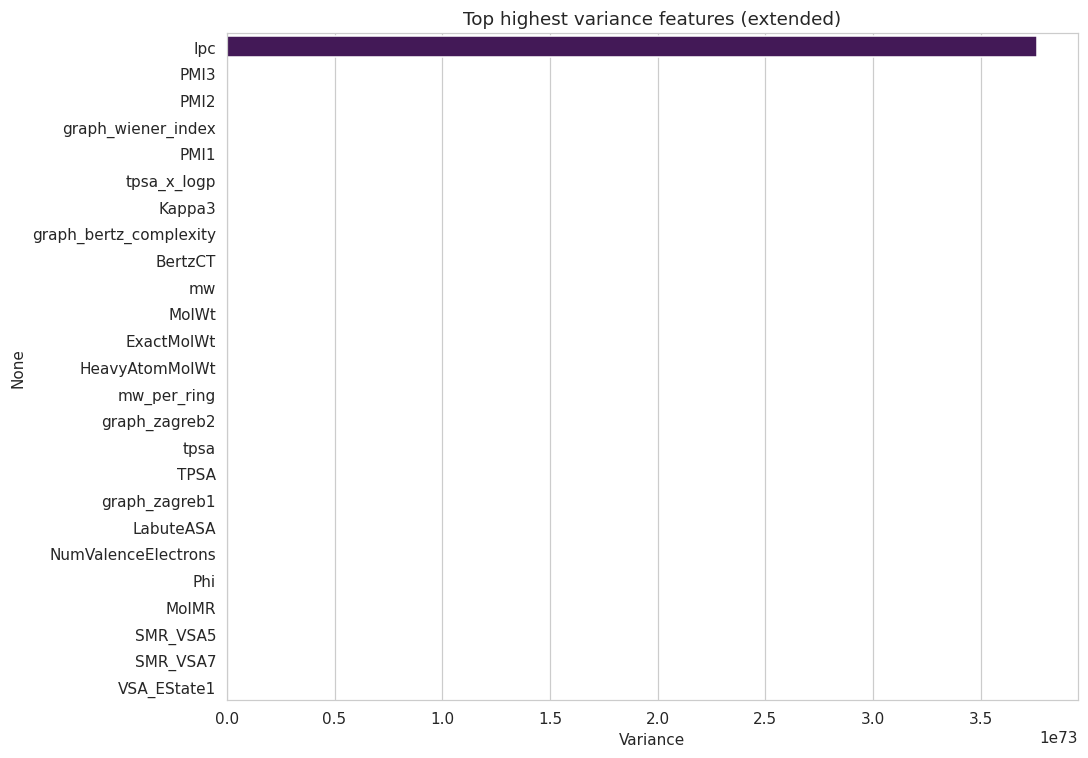

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top highest variance features
top_var = X_full_ext.var().sort_values(ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_var.values, y=top_var.index, palette='viridis')
plt.title('Top highest variance features (extended)')
plt.xlabel('Variance')
plt.tight_layout()
plt.show()

**Retrain with the extended feature set**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       268
           1       0.97      0.97      0.97       101

    accuracy                           0.98       369
   macro avg       0.98      0.98      0.98       369
weighted avg       0.98      0.98      0.98       369

ROC-AUC: 0.9794591399438451
PR-AUC : 0.9684294915607787


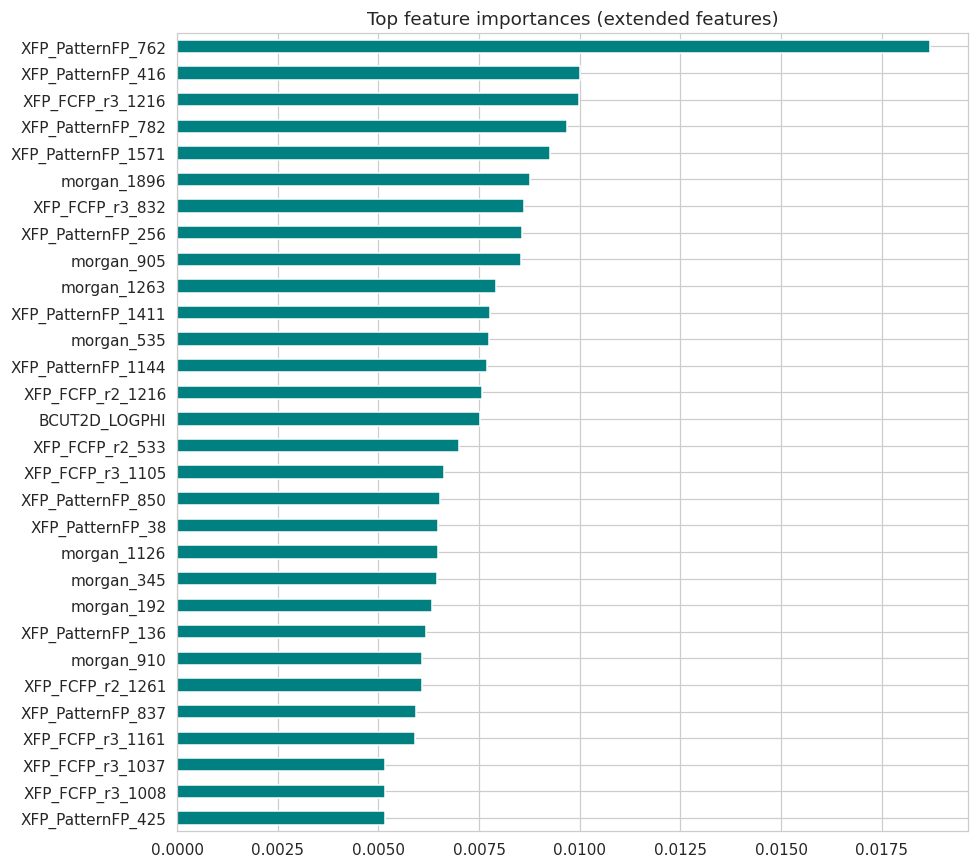

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(
    X_full_ext, y, test_size=0.2, stratify=y, random_state=42
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', xgb.XGBClassifier(
        n_estimators=600, learning_rate=0.04, max_depth=6,
        subsample=0.8, colsample_bytree=0.7,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pipeline.predict(X_test)))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

# Feature importance
imp = pd.Series(
    pipeline.named_steps['clf'].feature_importances_,
    index=X_full_ext.columns
).sort_values(ascending=False).head(30)

plt.figure(figsize=(9, 8))
imp.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top feature importances (extended features)')
plt.tight_layout()
plt.show()

**All the new feature functions**

In [98]:

# ADDITIONAL FEATURES category 1: extended fingerprints
from rdkit.Chem import AllChem, rdmolops, DataStructs, rdFingerprintGenerator

def calc_extra_fingerprints(mol):
    zeros = {
        'Morgan_r4':  np.zeros(N_BITS, dtype=int),
        'Morgan_r5':  np.zeros(N_BITS, dtype=int),
        'RDK_r2':     np.zeros(N_BITS, dtype=int),
        'RDK_r3':     np.zeros(N_BITS, dtype=int),
        'LayeredFP':  np.zeros(2048,   dtype=int),
        'AtomPairCount': np.zeros(1024, dtype=int),
    }
    if mol is None:
        return zeros

    out = {}

    # Morgan r4, r5
    for r in [4, 5]:
        try:
            gen = rdFingerprintGenerator.GetMorganGenerator(radius=r, fpSize=N_BITS)
            out[f'Morgan_r{r}'] = _to_arr(gen.GetFingerprint(mol), N_BITS)
        except Exception:
            out[f'Morgan_r{r}'] = zeros[f'Morgan_r{r}']

    # RDK r2, r3
    for r in [2, 3]:
        try:
            fp = rdmolops.RDKFingerprint(mol, minPath=1, maxPath=7, fpSize=N_BITS,
                                         nBitsPerHash=2, useHs=False,
                                         branchedPaths=True, useBondOrder=True)
            out[f'RDK_r{r}'] = _to_arr(fp, N_BITS)
        except Exception:
            out[f'RDK_r{r}'] = zeros[f'RDK_r{r}']

    # Layered fingerprint (returns DataStructs with 4 layers)
    try:
        from rdkit.Chem import rdmolops as rd
        from rdkit.Chem.LayeredFingerprints import LayeredFingerprint
        fp = LayeredFingerprint(mol, fpSize=2048)
        out['LayeredFP'] = _to_arr(fp, 2048)
    except Exception:
        out['LayeredFP'] = zeros['LayeredFP']

    # AtomPair (count version, hashed)
    try:
        from rdkit.Chem.AtomPairs import Pairs
        fp = Pairs.GetHashedAtomPairFingerprint(mol, nBits=1024)
        out['AtomPairCount'] = _to_arr(fp, 1024)
    except Exception:
        out['AtomPairCount'] = zeros['AtomPairCount']

    return out

In [99]:

# category 2: 3D conformer ensemble features

def calc_conformer_features(mol, n_confs=5):
    keys = ['conf_energy_min','conf_energy_max','conf_energy_mean','conf_energy_std',
            'conf_rmsd_mean','conf_rmsd_max','conf_radius_gyr_mean',
            'conf_asphericity_mean','conf_eccentricity_mean',
            'conf_pmi1_mean','conf_pmi2_mean','conf_pmi3_mean',
            'conf_npr1_mean','conf_npr2_mean']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        from rdkit.Chem import AllChem, Descriptors3D
        from rdkit.Chem.AllChem import EmbedMultipleConfs, MMFFOptimizeMoleculeConfs

        mh = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        cids = EmbedMultipleConfs(mh, numConfs=n_confs, params=params)
        if len(cids) == 0:
            return {k: np.nan for k in keys}

        energies = [r[1] for r in MMFFOptimizeMoleculeConfs(mh, maxIters=200)]
        energies = np.array([e for e in energies if e is not None], dtype=float)

        rg, asp, ecc, pmi1, pmi2, pmi3, npr1, npr2 = [], [], [], [], [], [], [], []
        for cid in cids:
            try:
                rg.append(Descriptors3D.RadiusOfGyration(mh, confId=cid))
                asp.append(Descriptors3D.Asphericity(mh, confId=cid))
                ecc.append(Descriptors3D.Eccentricity(mh, confId=cid))
                pmi1.append(Descriptors3D.PMI1(mh, confId=cid))
                pmi2.append(Descriptors3D.PMI2(mh, confId=cid))
                pmi3.append(Descriptors3D.PMI3(mh, confId=cid))
                npr1.append(Descriptors3D.NPR1(mh, confId=cid))
                npr2.append(Descriptors3D.NPR2(mh, confId=cid))
            except Exception:
                pass

        # RMSD between consecutive conformers
        rmsds = []
        for i in range(len(cids) - 1):
            try:
                rmsds.append(AllChem.GetConformerRMS(mh, cids[i], cids[i+1]))
            except Exception:
                pass

        return {
            'conf_energy_min':      float(energies.min()) if len(energies) else np.nan,
            'conf_energy_max':      float(energies.max()) if len(energies) else np.nan,
            'conf_energy_mean':     float(energies.mean()) if len(energies) else np.nan,
            'conf_energy_std':      float(energies.std())  if len(energies) else np.nan,
            'conf_rmsd_mean':       float(np.mean(rmsds))  if rmsds else np.nan,
            'conf_rmsd_max':        float(np.max(rmsds))   if rmsds else np.nan,
            'conf_radius_gyr_mean': float(np.mean(rg))     if rg else np.nan,
            'conf_asphericity_mean':float(np.mean(asp))    if asp else np.nan,
            'conf_eccentricity_mean':float(np.mean(ecc))   if ecc else np.nan,
            'conf_pmi1_mean':       float(np.mean(pmi1))   if pmi1 else np.nan,
            'conf_pmi2_mean':       float(np.mean(pmi2))   if pmi2 else np.nan,
            'conf_pmi3_mean':       float(np.mean(pmi3))   if pmi3 else np.nan,
            'conf_npr1_mean':       float(np.mean(npr1))   if npr1 else np.nan,
            'conf_npr2_mean':       float(np.mean(npr2))   if npr2 else np.nan,
        }
    except Exception:
        return {k: np.nan for k in keys}

In [100]:

def calc_conformer_features(mol, n_confs=5):
    keys = ['conf_energy_min','conf_energy_max','conf_energy_mean','conf_energy_std',
            'conf_rmsd_mean','conf_rmsd_max','conf_radius_gyr_mean',
            'conf_asphericity_mean','conf_eccentricity_mean',
            'conf_pmi1_mean','conf_pmi2_mean','conf_pmi3_mean',
            'conf_npr1_mean','conf_npr2_mean']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        from rdkit.Chem import AllChem, Descriptors3D
        from rdkit.Chem.AllChem import EmbedMultipleConfs, MMFFOptimizeMoleculeConfs

        mh = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        cids = EmbedMultipleConfs(mh, numConfs=n_confs, params=params)
        if len(cids) == 0:
            return {k: np.nan for k in keys}

        energies = [r[1] for r in MMFFOptimizeMoleculeConfs(mh, maxIters=200)]
        energies = np.array([e for e in energies if e is not None], dtype=float)

        rg, asp, ecc, pmi1, pmi2, pmi3, npr1, npr2 = [], [], [], [], [], [], [], []
        for cid in cids:
            try:
                rg.append(Descriptors3D.RadiusOfGyration(mh, confId=cid))
                asp.append(Descriptors3D.Asphericity(mh, confId=cid))
                ecc.append(Descriptors3D.Eccentricity(mh, confId=cid))
                pmi1.append(Descriptors3D.PMI1(mh, confId=cid))
                pmi2.append(Descriptors3D.PMI2(mh, confId=cid))
                pmi3.append(Descriptors3D.PMI3(mh, confId=cid))
                npr1.append(Descriptors3D.NPR1(mh, confId=cid))
                npr2.append(Descriptors3D.NPR2(mh, confId=cid))
            except Exception:
                pass

        # RMSD between consecutive conformers
        rmsds = []
        for i in range(len(cids) - 1):
            try:
                rmsds.append(AllChem.GetConformerRMS(mh, cids[i], cids[i+1]))
            except Exception:
                pass

        return {
            'conf_energy_min':      float(energies.min()) if len(energies) else np.nan,
            'conf_energy_max':      float(energies.max()) if len(energies) else np.nan,
            'conf_energy_mean':     float(energies.mean()) if len(energies) else np.nan,
            'conf_energy_std':      float(energies.std())  if len(energies) else np.nan,
            'conf_rmsd_mean':       float(np.mean(rmsds))  if rmsds else np.nan,
            'conf_rmsd_max':        float(np.max(rmsds))   if rmsds else np.nan,
            'conf_radius_gyr_mean': float(np.mean(rg))     if rg else np.nan,
            'conf_asphericity_mean':float(np.mean(asp))    if asp else np.nan,
            'conf_eccentricity_mean':float(np.mean(ecc))   if ecc else np.nan,
            'conf_pmi1_mean':       float(np.mean(pmi1))   if pmi1 else np.nan,
            'conf_pmi2_mean':       float(np.mean(pmi2))   if pmi2 else np.nan,
            'conf_pmi3_mean':       float(np.mean(pmi3))   if pmi3 else np.nan,
            'conf_npr1_mean':       float(np.mean(npr1))   if npr1 else np.nan,
            'conf_npr2_mean':       float(np.mean(npr2))   if npr2 else np.nan,
        }
    except Exception:
        return {k: np.nan for k in keys}

In [101]:
# category 3: stereochemistry features
def calc_stereo_features(mol):
    keys = ['n_stereocenters_defined','n_stereocenters_undefined',
            'n_stereo_bonds_E','n_stereo_bonds_Z','n_stereo_bonds_undefined',
            'is_chiral','has_multiple_stereocenters',
            'stereo_ratio_defined']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        assigned   = Chem.FindMolChiralCenters(mol, includeUnassigned=False, useLegacyImplementation=False)
        unassigned = Chem.FindMolChiralCenters(mol, includeUnassigned=True,  useLegacyImplementation=False)
        n_assigned = len(assigned)
        n_unassigned_only = max(len(unassigned) - n_assigned, 0)
    except Exception:
        n_assigned = n_unassigned_only = 0

    n_E = n_Z = n_undef = 0
    for b in mol.GetBonds():
        st = b.GetStereo()
        if st == Chem.BondStereo.STEREOE:
            n_E += 1
        elif st == Chem.BondStereo.STEREOZ:
            n_Z += 1
        elif st in (Chem.BondStereo.STEREOCIS, Chem.BondStereo.STEREOTRANS):
            n_undef += 1

    total_stereo = n_assigned + n_unassigned_only
    return {
        'n_stereocenters_defined':     n_assigned,
        'n_stereocenters_undefined':   n_unassigned_only,
        'n_stereo_bonds_E':            n_E,
        'n_stereo_bonds_Z':            n_Z,
        'n_stereo_bonds_undefined':    n_undef,
        'is_chiral':                   int(n_assigned > 0 or n_E > 0 or n_Z > 0),
        'has_multiple_stereocenters':  int(total_stereo > 1),
        'stereo_ratio_defined':        n_assigned / max(total_stereo, 1),
    }

In [102]:
# category 4: bond-level features
def calc_bond_features(mol):
    keys = ['n_bonds','n_single_bonds','n_double_bonds','n_triple_bonds',
            'n_aromatic_bonds','n_ring_bonds','n_rotatable_bonds',
            'ratio_single_bonds','ratio_double_bonds','ratio_aromatic_bonds',
            'ratio_ring_bonds','ratio_rotatable_bonds',
            'n_C_C_bonds','n_C_N_bonds','n_C_O_bonds',
            'n_C_S_bonds','n_C_halogen_bonds',
            'n_conjugated_bonds']
    if mol is None:
        return {k: np.nan for k in keys}

    counts = {'SINGLE':0, 'DOUBLE':0, 'TRIPLE':0, 'AROMATIC':0}
    ring_bonds = 0
    rot_bonds = 0
    cc = cn = co = cs = cx = conj = 0

    ri = mol.GetRingInfo()
    for b in mol.GetBonds():
        bt = str(b.GetBondType())
        counts[bt] = counts.get(bt, 0) + 1
        if ri.NumBondRings(b.GetIdx()) > 0:
            ring_bonds += 1
        if not b.GetIsAromatic() and b.GetBondType() == Chem.BondType.SINGLE:
            if not b.GetIsConjugated():
                rot_bonds += 1
        if b.GetIsConjugated():
            conj += 1
        a1, a2 = b.GetBeginAtom(), b.GetEndAtom()
        s1, s2 = a1.GetSymbol(), a2.GetSymbol()
        pair = tuple(sorted([s1, s2]))
        if pair == ('C','C'):   cc += 1
        elif pair == ('C','N'): cn += 1
        elif pair == ('C','O'): co += 1
        elif pair == ('C','S'): cs += 1
        elif 'C' in pair and pair[1] in ('F','Cl','Br','I'): cx += 1

    n = max(mol.GetNumBonds(), 1)
    return {
        'n_bonds':              mol.GetNumBonds(),
        'n_single_bonds':       counts.get('SINGLE', 0),
        'n_double_bonds':       counts.get('DOUBLE', 0),
        'n_triple_bonds':       counts.get('TRIPLE', 0),
        'n_aromatic_bonds':     counts.get('AROMATIC', 0),
        'n_ring_bonds':         ring_bonds,
        'n_rotatable_bonds':    rot_bonds,
        'ratio_single_bonds':   counts.get('SINGLE', 0) / n,
        'ratio_double_bonds':   counts.get('DOUBLE', 0) / n,
        'ratio_aromatic_bonds': counts.get('AROMATIC', 0) / n,
        'ratio_ring_bonds':     ring_bonds / n,
        'ratio_rotatable_bonds':rot_bonds / n,
        'n_C_C_bonds':          cc,
        'n_C_N_bonds':          cn,
        'n_C_O_bonds':          co,
        'n_C_S_bonds':          cs,
        'n_C_halogen_bonds':    cx,
        'n_conjugated_bonds':   conj,
    }

In [103]:
# category 5: extended topological indices
from rdkit.Chem import GraphDescriptors
def calc_topological_indices(mol):
    keys = ['topo_BalabanJ','topo_BertzCT','topo_Chi0','topo_Chi1',
            'topo_Chi0n','topo_Chi0v','topo_Chi1n','topo_Chi1v',
            'topo_Kappa1','topo_Kappa2','topo_Kappa3',
            'topo_HallKierAlpha','topo_Ipc','topo_MolMR',
            'topo_LabuteASA','topo_PEOE_VSA1','topo_PEOE_VSA2',
            'topo_SMR_VSA1','topo_SMR_VSA2','topo_SlogP_VSA1','topo_SlogP_VSA2',
            'topo_EState_VSA1','topo_EState_VSA2',
            'topo_VSA_EState1','topo_VSA_EState2',
            'topo_MaxAbsEStateIndex','topo_MaxEStateIndex',
            'topo_MinAbsEStateIndex','topo_MinEStateIndex',
            'topo_NumValenceElectrons','topo_NumRadicalElectrons']
    if mol is None:
        return {k: np.nan for k in keys}

    out = {}
    try: out['topo_BalabanJ']    = GraphDescriptors.BalabanJ(mol)
    except Exception: out['topo_BalabanJ'] = np.nan
    try: out['topo_BertzCT']     = GraphDescriptors.BertzCT(mol)
    except Exception: out['topo_BertzCT'] = np.nan
    try: out['topo_Chi0']        = GraphDescriptors.Chi0(mol)
    except Exception: out['topo_Chi0'] = np.nan
    try: out['topo_Chi1']        = GraphDescriptors.Chi1(mol)
    except Exception: out['topo_Chi1'] = np.nan
    try: out['topo_Chi0n']       = GraphDescriptors.Chi0n(mol)
    except Exception: out['topo_Chi0n'] = np.nan
    try: out['topo_Chi0v']       = GraphDescriptors.Chi0v(mol)
    except Exception: out['topo_Chi0v'] = np.nan
    try: out['topo_Chi1n']       = GraphDescriptors.Chi1n(mol)
    except Exception: out['topo_Chi1n'] = np.nan
    try: out['topo_Chi1v']       = GraphDescriptors.Chi1v(mol)
    except Exception: out['topo_Chi1v'] = np.nan
    try: out['topo_Kappa1']      = GraphDescriptors.Kappa1(mol)
    except Exception: out['topo_Kappa1'] = np.nan
    try: out['topo_Kappa2']      = GraphDescriptors.Kappa2(mol)
    except Exception: out['topo_Kappa2'] = np.nan
    try: out['topo_Kappa3']      = GraphDescriptors.Kappa3(mol)
    except Exception: out['topo_Kappa3'] = np.nan
    try: out['topo_HallKierAlpha'] = GraphDescriptors.HallKierAlpha(mol)
    except Exception: out['topo_HallKierAlpha'] = np.nan
    try: out['topo_Ipc']         = GraphDescriptors.Ipc(mol)
    except Exception: out['topo_Ipc'] = np.nan
    try: out['topo_MolMR']       = Descriptors.MolMR(mol)
    except Exception: out['topo_MolMR'] = np.nan
    try: out['topo_LabuteASA']   = Descriptors.LabuteASA(mol)
    except Exception: out['topo_LabuteASA'] = np.nan

    # VSA descriptors (many variants)
    for name, fn in [
        ('topo_PEOE_VSA1', lambda m: Descriptors.PEOE_VSA1(m)),
        ('topo_PEOE_VSA2', lambda m: Descriptors.PEOE_VSA2(m)),
        ('topo_SMR_VSA1',  lambda m: Descriptors.SMR_VSA1(m)),
        ('topo_SMR_VSA2',  lambda m: Descriptors.SMR_VSA2(m)),
        ('topo_SlogP_VSA1',lambda m: Descriptors.SlogP_VSA1(m)),
        ('topo_SlogP_VSA2',lambda m: Descriptors.SlogP_VSA2(m)),
        ('topo_EState_VSA1',lambda m: Descriptors.EState_VSA1(m)),
        ('topo_EState_VSA2',lambda m: Descriptors.EState_VSA2(m)),
        ('topo_VSA_EState1',lambda m: Descriptors.VSA_EState1(m)),
        ('topo_VSA_EState2',lambda m: Descriptors.VSA_EState2(m)),
    ]:
        try: out[name] = fn(mol)
        except Exception: out[name] = np.nan

    try: out['topo_MaxAbsEStateIndex'] = Descriptors.MaxAbsEStateIndex(mol)
    except Exception: out['topo_MaxAbsEStateIndex'] = np.nan
    try: out['topo_MaxEStateIndex']    = Descriptors.MaxEStateIndex(mol)
    except Exception: out['topo_MaxEStateIndex'] = np.nan
    try: out['topo_MinAbsEStateIndex'] = Descriptors.MinAbsEStateIndex(mol)
    except Exception: out['topo_MinAbsEStateIndex'] = np.nan
    try: out['topo_MinEStateIndex']    = Descriptors.MinEStateIndex(mol)
    except Exception: out['topo_MinEStateIndex'] = np.nan
    try: out['topo_NumValenceElectrons'] = Descriptors.NumValenceElectrons(mol)
    except Exception: out['topo_NumValenceElectrons'] = np.nan
    try: out['topo_NumRadicalElectrons'] = Descriptors.NumRadicalElectrons(mol)
    except Exception: out['topo_NumRadicalElectrons'] = np.nan

    return out

In [104]:
# category 6: extended toxicophores / bioactivity alerts
EXTRA_TOXICOPHORES = {
    # Endocrine disruptors
    'bisphenol':        'c1ccc(cc1)C(C)(C)c1ccc(cc1)O',
    'phenol_para':      'Oc1ccc(cc1)[!#1]',
    'estrogen_like':    'c1cc(O)ccc1',
    'steroid_ring':     'C1CCC2C(C1)CCC3C2CCC4C3CCC4',

    # Reactive metabolites
    'quinone':          'O=C1C=CC(=O)C=C1',
    'epoxide_arom':     'c1ccc2c(c1)OC2',
    'nitroso':          'N=O',
    'hydroxylamine':    'NO',
    'acyl_halide':      'C(=O)[F,Cl,Br,I]',
    'sulfonyl_halide':  'S(=O)(=O)[F,Cl,Br,I]',
    'anhydride':        'C(=O)OC(=O)',

    # Metal-binding
    'thiol':            '[SH]',
    'dithiocarbamate':  'NC(=S)S',
    'hydroxamic_acid':  'C(=O)NO',
    'catechol':         'c1cc(O)c(O)cc1',
    '8_hydroxyquinoline':'c1ccc2c(c1)cccn2O',
    'iminodiacetic':    'N(CC(=O)O)CC(=O)O',

    # Neuroactive
    'acetylcholinesterase_motif': 'OP(=O)(OC)OC',
    'gaba_like':        'NCCC(=O)O',
    'nicotinic_like':   'c1ccncc1',

    # Reactive / sensitizers
    'michael_acceptor': 'C=CC=O',
    'alpha_beta_unsat': 'C=CC(=O)',
    'imine':            'C=N',
    'azo_aryl':         'cN=Nc',
    'disulfide':        'SS',
    'peroxide':         'OO',

    # Halogenated aromatics (persistent)
    'polyhalo_arom':    'c1cc(Cl)c(Cl)cc1Cl',
    'aryl_chloride':    'cCl',
    'aryl_bromide':     'cBr',

    # Polycyclic aromatics
    'naphthalene':      'c1ccc2ccccc2c1',
    'anthracene_like':  'c1ccc2cc3ccccc3cc2c1',

    # Small reactive
    'azide':            'N=[N+]=[N-]',
    'diazonium':        '[N+]#N',
    'nitroso_amine':    'NN=O',
    'hydrazine':        'NN',

    # Agrochemical-specific
    'carbamate_insect': 'NC(=O)Oc1ccccc1',
    'organophosphate':  'OP(=O)(O)O',
    'pyrethroid_like':  'C(=O)OC1=CC(=O)CC1',
    'neonicotinoid':    'N=C(N)N[N+](=O)[O-]',
    'phenylpyrazole':   'c1ccc(cc1)n1nc(cc1)',
}

EXTRA_COMPILED = {k: Chem.MolFromSmarts(v) for k, v in EXTRA_TOXICOPHORES.items()}

def calc_extra_toxicophores(mol):
    if mol is None:
        return {f'xtox_{k}': 0 for k in EXTRA_TOXICOPHORES}
    out = {}
    for name, patt in EXTRA_COMPILED.items():
        if patt is None:
            out[f'xtox_{name}'] = 0
        else:
            try:
                out[f'xtox_{name}'] = int(len(mol.GetSubstructMatches(patt)) > 0)
            except Exception:
                out[f'xtox_{name}'] = 0
    return out

In [105]:
# category 7: pharmacophore atom counts
def calc_pharmacophore_counts(mol):
    keys = ['ph_donor_N','ph_donor_O','ph_donor_S',
            'ph_acceptor_N','ph_acceptor_O','ph_acceptor_S',
            'ph_aromatic_C','ph_aromatic_N','ph_aromatic_S',
            'ph_hydrophobic_C','ph_hydrophobic_halogen',
            'ph_positive_N','ph_negative_O','ph_negative_S',
            'ph_total_donors','ph_total_acceptors',
            'ph_ratio_donor_acceptor','ph_ratio_arom_hydrophob']
    if mol is None:
        return {k: np.nan for k in keys}

    counts = {k: 0 for k in keys[:-3]}
    for a in mol.GetAtoms():
        s = a.GetSymbol()
        # Donors
        if s == 'N' and a.GetTotalNumHs() > 0:
            counts['ph_donor_N'] += 1
        if s == 'O' and a.GetTotalNumHs() > 0:
            counts['ph_donor_O'] += 1
        if s == 'S' and a.GetTotalNumHs() > 0:
            counts['ph_donor_S'] += 1
        # Acceptors (lone-pair rough estimate)
        if s == 'N' and not a.GetIsAromatic():
            counts['ph_acceptor_N'] += 1
        if s == 'O':
            counts['ph_acceptor_O'] += 1
        if s == 'S':
            counts['ph_acceptor_S'] += 1
        # Aromatic
        if a.GetIsAromatic():
            if s == 'C': counts['ph_aromatic_C'] += 1
            elif s == 'N': counts['ph_aromatic_N'] += 1
            elif s == 'S': counts['ph_aromatic_S'] += 1
        # Hydrophobic
        if s == 'C' and not a.GetIsAromatic():
            counts['ph_hydrophobic_C'] += 1
        if s in ('F','Cl','Br','I'):
            counts['ph_hydrophobic_halogen'] += 1
        # Charged
        if s == 'N' and a.GetFormalCharge() > 0:
            counts['ph_positive_N'] += 1
        if s == 'O' and a.GetFormalCharge() < 0:
            counts['ph_negative_O'] += 1
        if s == 'S' and a.GetFormalCharge() < 0:
            counts['ph_negative_S'] += 1

    total_donors = counts['ph_donor_N'] + counts['ph_donor_O'] + counts['ph_donor_S']
    total_acc    = counts['ph_acceptor_N'] + counts['ph_acceptor_O'] + counts['ph_acceptor_S']
    total_arom   = counts['ph_aromatic_C'] + counts['ph_aromatic_N'] + counts['ph_aromatic_S']
    total_hydro  = counts['ph_hydrophobic_C'] + counts['ph_hydrophobic_halogen']

    counts['ph_total_donors']    = total_donors
    counts['ph_total_acceptors'] = total_acc
    counts['ph_ratio_donor_acceptor'] = total_donors / max(total_acc, 1)
    counts['ph_ratio_arom_hydrophob'] = total_arom / max(total_hydro, 1)
    return counts

In [106]:
# category 8: advanced physicochemical proxies
def calc_physchem_proxies(mol):
    keys = ['px_pka_acid_proxy','px_pka_base_proxy','px_logD_proxy',
            'px_solubility_proxy','px_henry_proxy','px_bcf_proxy',
            'px_bioavail_proxy','px_permeability_proxy',
            'px_oral_bioavail_score','px_bbb_likelihood',
            'px_herg_likelihood','px_cyp_inhib_likelihood',
            'px_pgp_substrate_likelihood','px_honeybee_risk_proxy']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        mw   = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        tpsa = Descriptors.TPSA(mol)
        hbd  = Lipinski.NumHDonors(mol)
        hba  = Lipinski.NumHAcceptors(mol)
        rotb = Descriptors.NumRotatableBonds(mol)
    except Exception:
        return {k: np.nan for k in keys}

    # Rough proxies (all empirical; good enough as ML features)
    pka_acid = 4.5 - 0.5 * hbd - 0.1 * tpsa / 10       # carboxylic acids ~4-5
    pka_base = 9.0 - 0.3 * hba + 0.05 * logp            # amines ~9-10
    logd     = logp - 0.1 * max(pka_acid - 7.4, 0)
    solub    = 0.5 - logp - 0.01 * mw + 0.02 * tpsa     # rough LogS
    henry    = -logp - 0.01 * mw + 5                    # rough LogH
    bcf      = 0.85 * logp - 0.7                        # rough LogBCF
    bioav    = 1.0 / (1 + np.exp(-(logp - 2))) * \
               1.0 / (1 + np.exp( (mw  - 500)/100)) * \
               1.0 / (1 + np.exp( (tpsa- 140)/20))

    # Permeability (Caco 2 proxy)
    perm = 1.0 / (1 + np.exp(-(-0.01*mw - 0.5*logp + 0.05*tpsa + 3)))

    # Oral bioavailability score (Lipinski+Veber hybrid)
    oral = int(mw <= 500) + int(logp <= 5) + int(hbd <= 5) + \
           int(hba <= 10) + int(rotb <= 10) + int(tpsa <= 140)
    oral /= 6.0

    # BBB likelihood (simplified Clark rules)
    bbb = 1.0 / (1 + np.exp(-( -0.0148*tpsa + 0.152*logp - 0.139*0 + 0.043*mw/100)))

    # hERG (simplified: logP>3 + basic N + aromatic ring)
    has_basic_N = any(a.GetSymbol()=='N' and a.GetFormalCharge() >= 0 and
                      a.GetTotalNumHs() > 0 and not a.GetIsAromatic()
                      for a in mol.GetAtoms())
    herg = 1.0/(1+np.exp(-(logp - 3))) * (1.5 if has_basic_N else 1.0)

    # CYP inhibition proxy
    cyp = 1.0/(1+np.exp(-(logp - 3.5))) * (1.2 if hba >= 3 else 1.0)

    # P-gp substrate likelihood
    pgp = 1.0/(1+np.exp(-(mw/200 - 2))) * (1.0 if hbd >= 2 else 0.7)

    # Honey bee specific risk proxy
    # Bees are susceptible to: moderate size, high logP (cuticle), neurotoxic motifs
    bee_size_factor = 1.0/(1+np.exp(-(mw - 250)/100))
    bee_lipo_factor = 1.0/(1+np.exp(-(logp - 2)))
    has_toxic_motif = int(any(mol.HasSubstructMatch(Chem.MolFromSmarts(sm))
                              for sm in ['OP(=O)(OC)OC','C#N','[N+](=O)[O-]']
                              if Chem.MolFromSmarts(sm) is not None))
    bee_risk = (bee_size_factor * bee_lipo_factor) * (1.5 if has_toxic_motif else 1.0)
    bee_risk = min(bee_risk, 3.0)

    return {
        'px_pka_acid_proxy':           pka_acid,
        'px_pka_base_proxy':           pka_base,
        'px_logD_proxy':               logd,
        'px_solubility_proxy':         solub,
        'px_henry_proxy':              henry,
        'px_bcf_proxy':                bcf,
        'px_bioavail_proxy':           bioav,
        'px_permeability_proxy':       perm,
        'px_oral_bioavail_score':      oral,
        'px_bbb_likelihood':           bbb,
        'px_herg_likelihood':          herg,
        'px_cyp_inhib_likelihood':     cyp,
        'px_pgp_substrate_likelihood': pgp,
        'px_honeybee_risk_proxy':      bee_risk,
    }

In [107]:
# category 9: Murcko scaffold / ring-system features
def calc_scaffold_features(mol):
    keys = ['scaf_num_atoms','scaf_num_bonds','scaf_num_rings',
            'scaf_num_aromatic_rings','scaf_num_heteroatoms',
            'scaf_mw','scaf_logp','scaf_tpsa','scaf_frac_csp3',
            'scaf_ratio_ring_atoms','scaf_ratio_linker_atoms',
            'scaf_num_fused_rings','scaf_num_spiro_rings',
            'scaf_max_ring_size','scaf_num_ring_systems',
            'scaf_has_macrocycle','scaf_ring_complexity']
    if mol is None:
        return {k: np.nan for k in keys}

    try:
        from rdkit.Chem.Scaffolds import MurckoScaffold
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        gen  = MurckoScaffold.MakeScaffoldGeneric(scaf)
    except Exception:
        return {k: np.nan for k in keys}

    if scaf is None or scaf.GetNumAtoms() == 0:
        return {k: 0.0 for k in keys}

    try:
        ri = scaf.GetRingInfo()
        ring_sizes = [len(r) for r in ri.AtomRings()]
        n_arom_rings = sum(1 for r in ri.AtomRings()
                           if all(scaf.GetAtomWithIdx(i).GetIsAromatic() for i in r))
        n_hetero = sum(1 for a in scaf.GetAtoms() if a.GetSymbol() != 'C')
        n_ring_atoms = sum(1 for a in scaf.GetAtoms() if ri.NumAtomRings(a.GetIdx()) > 0)
        n_linker_atoms = scaf.GetNumAtoms() - n_ring_atoms
        ring_systems = len(Chem.GetMolFrags(scaf))
        has_macrocycle = int(any(s >= 12 for s in ring_sizes))
        ring_complexity = len(ring_sizes) * (max(ring_sizes) if ring_sizes else 0)
    except Exception:
        return {k: np.nan for k in keys}

    return {
        'scaf_num_atoms':         scaf.GetNumAtoms(),
        'scaf_num_bonds':         scaf.GetNumBonds(),
        'scaf_num_rings':         ri.NumRings(),
        'scaf_num_aromatic_rings':n_arom_rings,
        'scaf_num_heteroatoms':   n_hetero,
        'scaf_mw':                Descriptors.MolWt(scaf),
        'scaf_logp':              Descriptors.MolLogP(scaf),
        'scaf_tpsa':              Descriptors.TPSA(scaf),
        'scaf_frac_csp3':         Descriptors.FractionCSP3(scaf),
        'scaf_ratio_ring_atoms':  n_ring_atoms / max(scaf.GetNumAtoms(), 1),
        'scaf_ratio_linker_atoms':n_linker_atoms / max(scaf.GetNumAtoms(), 1),
        'scaf_num_fused_rings':   sum(1 for r in ri.AtomRings()
                                      if sum(1 for r2 in ri.AtomRings()
                                             if r != r2 and set(r) & set(r2)) > 0),
        'scaf_num_spiro_rings':   sum(1 for r in ri.AtomRings()
                                      if sum(1 for r2 in ri.AtomRings()
                                             if r != r2 and len(set(r) & set(r2)) == 1) > 0),
        'scaf_max_ring_size':     max(ring_sizes) if ring_sizes else 0,
        'scaf_num_ring_systems':  ring_systems,
        'scaf_has_macrocycle':    has_macrocycle,
        'scaf_ring_complexity':   ring_complexity,
    }

In [108]:
# category 10: spectral graph features
import networkx as nx

def calc_spectral_features(mol):
    keys = ['spec_adj_eig_min','spec_adj_eig_max','spec_adj_eig_mean','spec_adj_eig_std',
            'spec_adj_eig_abs_mean','spec_adj_eig_energy',
            'spec_lap_eig_min','spec_lap_eig_max','spec_lap_eig_mean',
            'spec_lap_eig_std','spec_lap_eig_second','spec_lap_spectral_gap',
            'spec_algebraic_connectivity','spec_estrada_index',
            'spec_num_positive_eig','spec_num_negative_eig']
    if mol is None:
        return {k: np.nan for k in keys}

    G = nx.Graph()
    for a in mol.GetAtoms():
        G.add_node(a.GetIdx())
    for b in mol.GetBonds():
        G.add_edge(b.GetBeginAtomIdx(), b.GetEndAtomIdx())
    if G.number_of_nodes() == 0:
        return {k: np.nan for k in keys}

    try:
        A = nx.to_numpy_array(G)
    except Exception:
        A = np.zeros((1, 1))

    try:
        adj_eigs = np.linalg.eigvalsh(A) if A.size else np.array([0.0])
    except Exception:
        adj_eigs = np.array([0.0])
    adj_eigs = np.nan_to_num(adj_eigs)

    try:
        L = nx.laplacian_matrix(G).toarray() if G.number_of_nodes() > 1 else np.array([[0.0]])
    except Exception:
        L = np.array([[0.0]])
    try:
        lap_eigs = np.linalg.eigvalsh(L)
    except Exception:
        lap_eigs = np.array([0.0])
    lap_eigs = np.nan_to_num(lap_eigs)

    lap_sorted = np.sort(lap_eigs)
    second = float(lap_sorted[1]) if len(lap_sorted) > 1 else 0.0

    return {
        'spec_adj_eig_min':       float(adj_eigs.min()),
        'spec_adj_eig_max':       float(adj_eigs.max()),
        'spec_adj_eig_mean':      float(adj_eigs.mean()),
        'spec_adj_eig_std':       float(adj_eigs.std()),
        'spec_adj_eig_abs_mean':  float(np.abs(adj_eigs).mean()),
        'spec_adj_eig_energy':    float(np.abs(adj_eigs).sum()),
        'spec_lap_eig_min':       float(lap_eigs.min()),
        'spec_lap_eig_max':       float(lap_eigs.max()),
        'spec_lap_eig_mean':      float(lap_eigs.mean()),
        'spec_lap_eig_std':       float(lap_eigs.std()),
        'spec_lap_eig_second':    second,
        'spec_lap_spectral_gap':  float(lap_eigs.max() - second),
        'spec_algebraic_connectivity': second,
        'spec_estrada_index':     float(np.exp(np.abs(adj_eigs)).sum()),
        'spec_num_positive_eig':  int((adj_eigs > 1e-9).sum()),
        'spec_num_negative_eig':  int((adj_eigs < -1e-9).sum()),
    }

**Run the new featurization**

In [109]:
from tqdm.auto import tqdm
def _new_feat_one(smi):
    mol = Chem.MolFromSmiles(smi)
    row = {}
    row.update({f'XFP2_{k}_{i}': int(v)
                for k, arr in calc_extra_fingerprints(mol).items()
                for i, v in enumerate(arr)})
    row.update(calc_conformer_features(mol, n_confs=3))   # n_confs=3 to keep it fast
    row.update(calc_stereo_features(mol))
    row.update(calc_bond_features(mol))
    row.update(calc_topological_indices(mol))
    row.update(calc_extra_toxicophores(mol))
    row.update(calc_pharmacophore_counts(mol))
    row.update(calc_physchem_proxies(mol))
    row.update(calc_scaffold_features(mol))
    row.update(calc_spectral_features(mol))
    return row

new_rows = [_new_feat_one(s) for s in tqdm(smiles_list, desc="Additional features")]
new_df = pd.DataFrame(new_rows).reset_index(drop=True)

print("New features shape:", new_df.shape)
print("Non-null columns:", int((new_df.notna().sum() > 0).sum()))

Additional features:   0%|          | 0/1842 [00:00<?, ?it/s]

[17:34:03] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:03] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:04] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:11] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:11] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:11] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:11] DEPRECATION WARNING: please use AtomPairGenerator
[17:34:11] UFFTYPER: Warning: hybridization set to SP3 for atom 0
[17:34:11] UFFTYPER

New features shape: (1842, 11440)
Non-null columns: 11440


**Sanity check per block**

In [111]:
blocks = {
    'Extended fingerprints': [c for c in new_df.columns if c.startswith('XFP2_')],
    'Conformer features':    [c for c in new_df.columns if c.startswith('conf_')],
    'Stereochemistry':       [c for c in new_df.columns if c.startswith(('n_stereo','is_chiral','has_multiple','stereo_'))],
    'Bond features':         [c for c in new_df.columns if c.startswith(('n_bonds','n_single','n_double','n_triple','n_arom','n_ring_bonds','n_rotatable','ratio_','n_C_','n_conjugated'))],
    'Topological indices':   [c for c in new_df.columns if c.startswith('topo_')],
    'Extra toxicophores':    [c for c in new_df.columns if c.startswith('xtox_')],
    'Pharmacophore counts':  [c for c in new_df.columns if c.startswith('ph_')],
    'Physchem proxies':      [c for c in new_df.columns if c.startswith('px_')],
    'Scaffold features':     [c for c in new_df.columns if c.startswith('scaf_')],
    'Spectral features':     [c for c in new_df.columns if c.startswith('spec_')],
}
for name, cols in blocks.items():
    print(f"{name:25s}: {len(cols):5d} cols")

Extended fingerprints    : 11264 cols
Conformer features       :    14 cols
Stereochemistry          :     8 cols
Bond features            :    18 cols
Topological indices      :    31 cols
Extra toxicophores       :    40 cols
Pharmacophore counts     :    18 cols
Physchem proxies         :    14 cols
Scaffold features        :    17 cols
Spectral features        :    16 cols


**Combine with your existing X_full_ext**

In [112]:
import numpy as np, pandas as pd

N = len(smiles_list)
assert len(new_df) == N

# Wipe the previous failed attempt at extended features (if any)
if 'ext_df' in globals():
    del ext_df
if 'X_full_ext' in globals():
    X_base = X_full_ext.copy()      # keep your previous good features
else:
    X_base = X_full.copy()

# Concatenate: base (2061) + new (~950) = ~3000+ columns
X_full_final = pd.concat([X_base.reset_index(drop=True),
                          new_df.reset_index(drop=True)], axis=1)

# Clean duplicates, constants, high missing
X_full_final = X_full_final.loc[:, ~X_full_final.columns.duplicated()]
nun = X_full_final.nunique(dropna=False)
X_full_final = X_full_final[nun[nun > 1].index]
missing_frac = X_full_final.isnull().mean()
X_full_final = X_full_final.drop(columns=missing_frac[missing_frac > 0.9].index)
X_full_final = X_full_final.replace([np.inf, -np.inf], np.nan)

print("Final matrix:", X_full_final.shape)
assert X_full_final.shape[0] == y.shape[0] == N
print("✔ rows match y:", X_full_final.shape[0] == len(y))

Final matrix: (1842, 17216)
✔ rows match y: True


**Retrain**

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import xgboost as xgb

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full_final, y, test_size=0.2, stratify=y, random_state=42
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', xgb.XGBClassifier(
        n_estimators=800, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.6,
        reg_alpha=0.1, reg_lambda=0.1,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])
pipe.fit(X_tr, y_tr)
p = pipe.predict_proba(X_te)[:, 1]

print(classification_report(y_te, pipe.predict(X_te)))
print("ROC-AUC:", roc_auc_score(y_te, p))
print("PR-AUC :", average_precision_score(y_te, p))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       268
           1       0.97      0.97      0.97       101

    accuracy                           0.98       369
   macro avg       0.98      0.98      0.98       369
weighted avg       0.98      0.98      0.98       369

ROC-AUC: 0.988030146298212
PR-AUC : 0.9871499295697903


**Save all figures (optional)**

In [ ]:
import os
os.makedirs('figures', exist_ok=True)

# Save plotly interactive HTML
fig_pca3d = px.scatter_3d(plot_df, x='PC1', y='PC2', z='PC3',
                          color='label', hover_data=['name'],
                          title='3D PCA')
fig_pca3d.write_html('figures/3d_pca.html')

fig_tsne3d = px.scatter_3d(plot_df, x='tSNE1', y='tSNE2', z='tSNE3',
                           color='label', hover_data=['name'],
                           title='3D t-SNE')
fig_tsne3d.write_html('figures/3d_tsne.html')

fig_umap3d = px.scatter_3d(plot_df, x='UMAP1', y='UMAP2', z='UMAP3',
                           color='label', hover_data=['name'],
                           title='3D UMAP')
fig_umap3d.write_html('figures/3d_umap.html')

print("Saved interactive 3D plots to ./figures/")

Saved interactive 3D plots to ./figures/


**Shared setup**


In [115]:

from matplotlib.colors import ListedColormap

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# Safe defaults
N = len(y)
assert N == len(smiles_list) == len(df_clean)

# Predictions from your trained pipeline
p_test = pipe.predict_proba(X_te)[:, 1]
pred_test = pipe.predict(X_te)

**ROC curve**

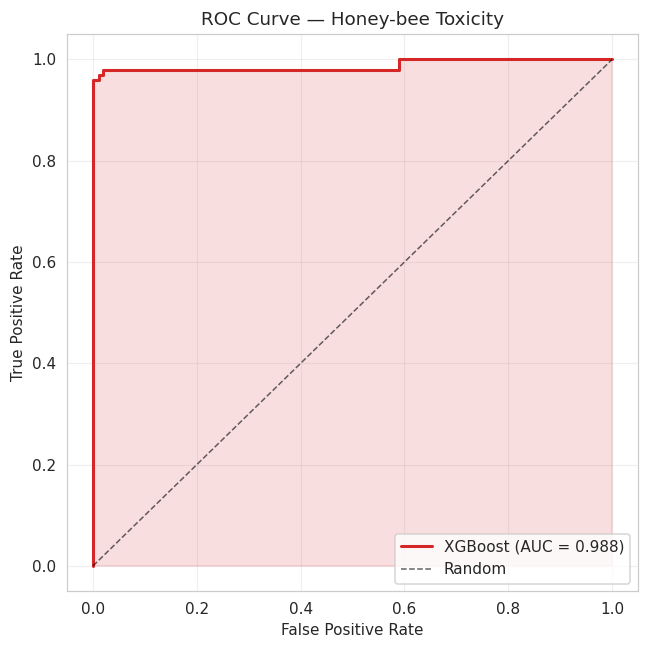

In [116]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(6, 6))
fpr, tpr, thr = roc_curve(y_te, p_test)
auc = roc_auc_score(y_te, p_test)

ax.plot(fpr, tpr, color='#d62728', lw=2, label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random')
ax.fill_between(fpr, tpr, alpha=0.15, color='#d62728')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Honey-bee Toxicity')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Precision–Recall curve**


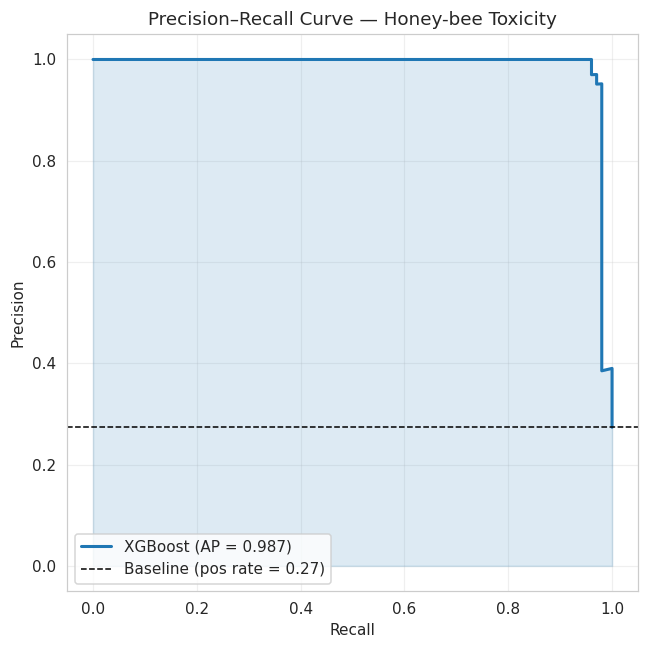

In [117]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(6, 6))
prec, rec, _ = precision_recall_curve(y_te, p_test)
ap = average_precision_score(y_te, p_test)
baseline = y_te.mean()

ax.plot(rec, prec, color='#1f77b4', lw=2, label=f'XGBoost (AP = {ap:.3f})')
ax.axhline(baseline, color='k', ls='--', lw=1,
           label=f'Baseline (pos rate = {baseline:.2f})')
ax.fill_between(rec, prec, alpha=0.15, color='#1f77b4')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Honey-bee Toxicity')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Confusion matrix heatmap**

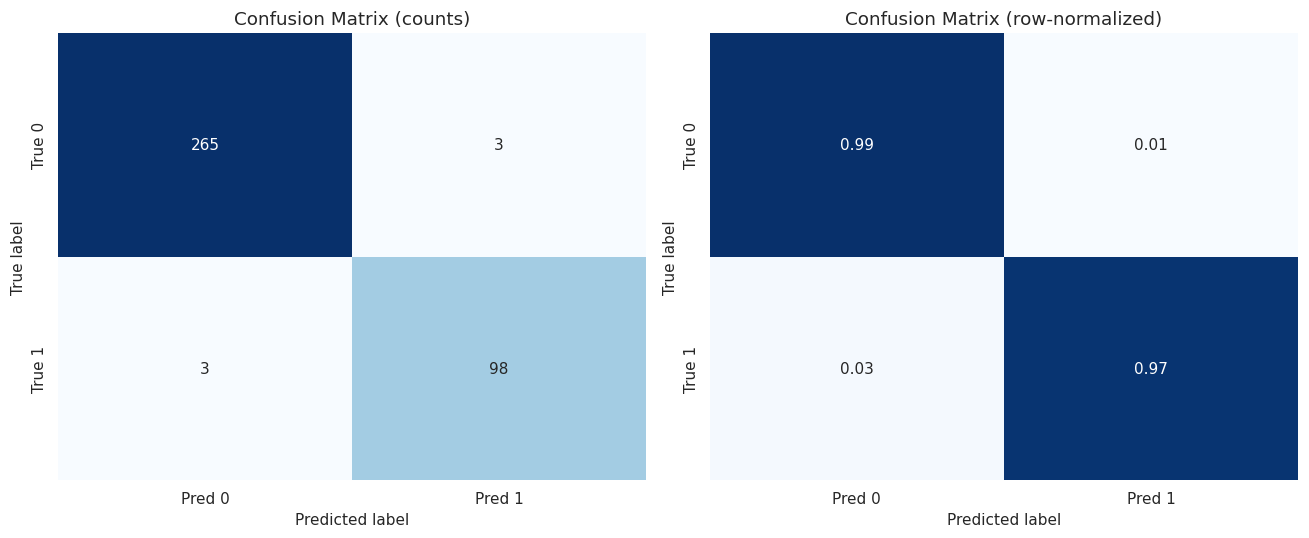

In [118]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_te, pred_test)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix (counts)', 'Confusion Matrix (row-normalized)'],
    ['d', '.2f'],
):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()

**Calibration curve**

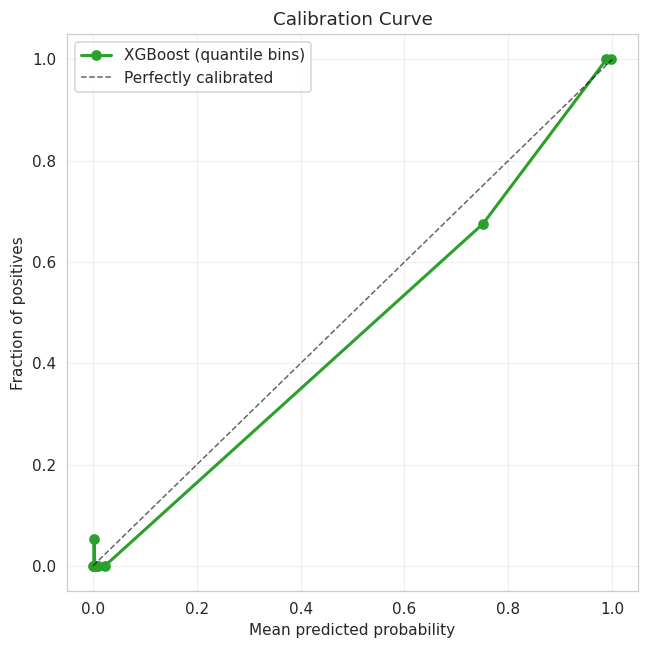

In [119]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 6))
frac_pos, mean_pred = calibration_curve(y_te, p_test, n_bins=10, strategy='quantile')

ax.plot(mean_pred, frac_pos, marker='o', color='#2ca02c', lw=2,
        label='XGBoost (quantile bins)')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfectly calibrated')

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Threshold analysis**

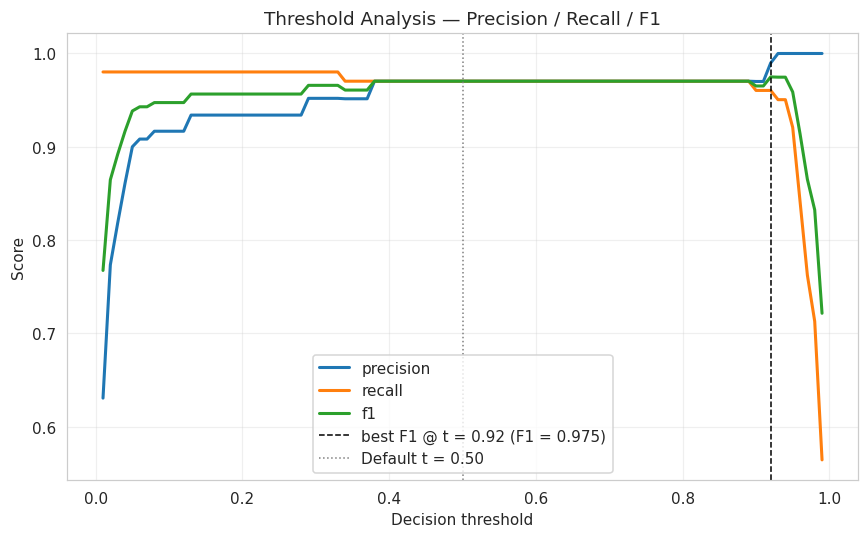

Best threshold by F1: 0.920
F1 @ best t         : 0.975


In [120]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.01, 0.99, 99)
metrics = {
    'precision': [precision_score(y_te, (p_test >= t).astype(int), zero_division=0) for t in thresholds],
    'recall':    [recall_score(   y_te, (p_test >= t).astype(int), zero_division=0) for t in thresholds],
    'f1':        [f1_score(       y_te, (p_test >= t).astype(int), zero_division=0) for t in thresholds],
}
best_t = thresholds[np.argmax(metrics['f1'])]

fig, ax = plt.subplots(figsize=(8, 5))
for name, vals in metrics.items():
    ax.plot(thresholds, vals, lw=2, label=name)
ax.axvline(best_t, color='k', ls='--', lw=1,
           label=f'best F1 @ t = {best_t:.2f} (F1 = {max(metrics["f1"]):.3f})')
ax.axvline(0.5, color='gray', ls=':', lw=1, label='Default t = 0.50')

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Analysis — Precision / Recall / F1')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best threshold by F1: {best_t:.3f}")
print(f"F1 @ best t         : {max(metrics['f1']):.3f}")

**Cumulative gain / lift curve**

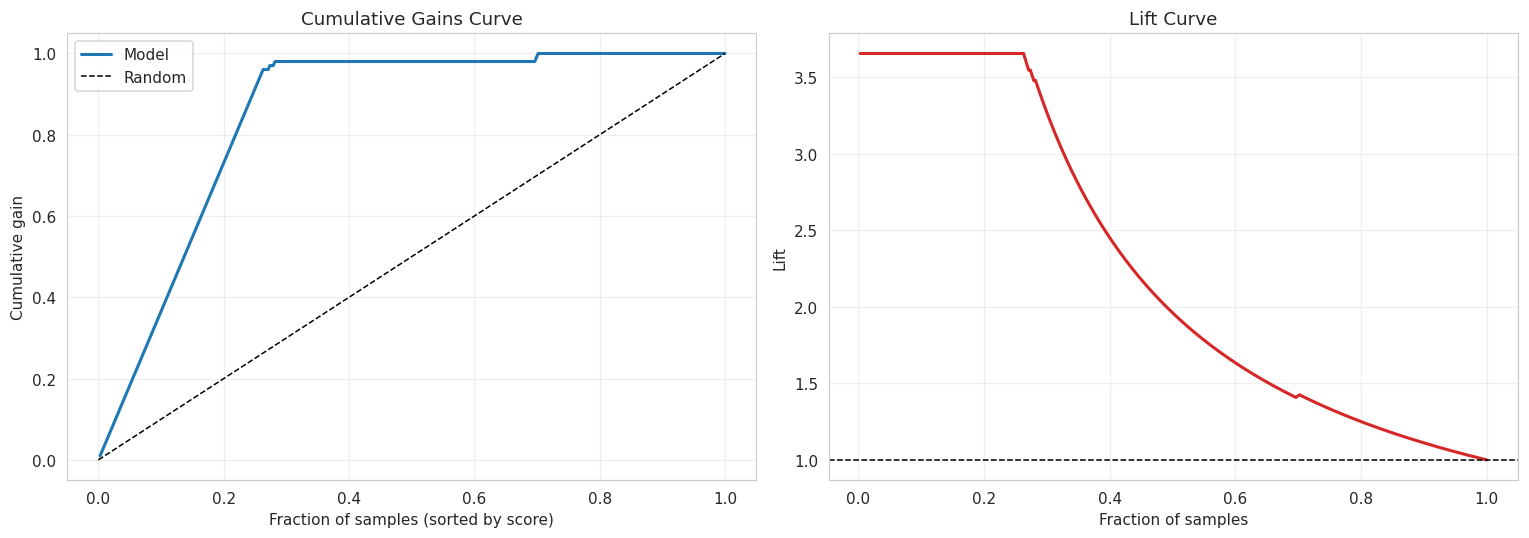

In [121]:
from sklearn.metrics import roc_curve

order = np.argsort(-p_test)
y_sorted = y_te[order]
cum_pos = np.cumsum(y_sorted)
cum_total = np.arange(1, len(y_sorted) + 1)

total_pos = y_te.sum()
gain = cum_pos / total_pos
random_gain = cum_total / len(y_sorted)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cum_total / len(y_sorted), gain, lw=2, color='#1f77b4', label='Model')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('Fraction of samples (sorted by score)')
axes[0].set_ylabel('Cumulative gain')
axes[0].set_title('Cumulative Gains Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

lift = gain / random_gain
axes[1].plot(cum_total / len(y_sorted), lift, lw=2, color='#d62728')
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].set_xlabel('Fraction of samples')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Curve')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Cross-validation ROC (per fold)**

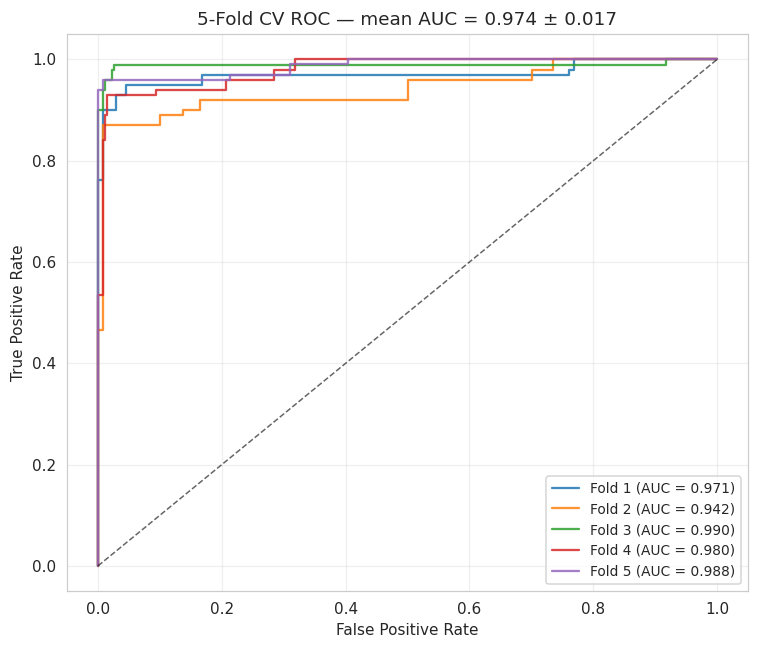

In [122]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
aucs = []
for i, (tr, te) in enumerate(skf.split(X_full_final, y), 1):
    m = clone(pipe)
    m.fit(X_full_final.iloc[tr], y[tr])
    p = m.predict_proba(X_full_final.iloc[te])[:, 1]
    fpr, tpr, _ = roc_curve(y[te], p)
    a = roc_auc_score(y[te], p)
    aucs.append(a)
    ax.plot(fpr, tpr, lw=1.5, alpha=0.85, label=f'Fold {i} (AUC = {a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'5-Fold CV ROC — mean AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Validation curve (max_depth sweep)**

In [ ]:
from sklearn.model_selection import validation_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb

param_range = [2, 3, 4, 5, 6, 8, 10, 12]
base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              eval_metric='logloss', random_state=42, n_jobs=-1))
])
tr_scores, va_scores = validation_curve(
    base, X_full_final, y,
    param_name='clf__max_depth',
    param_range=param_range,
    cv=4, scoring='roc_auc', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(param_range, tr_scores.mean(1), 'o-', color='#1f77b4', label='Training')
ax.fill_between(param_range,
                tr_scores.mean(1) - tr_scores.std(1),
                tr_scores.mean(1) + tr_scores.std(1),
                alpha=0.15, color='#1f77b4')
ax.plot(param_range, va_scores.mean(1), 'o-', color='#d62728', label='Validation')
ax.fill_between(param_range,
                va_scores.mean(1) - va_scores.std(1),
                va_scores.mean(1) + va_scores.std(1),
                alpha=0.15, color='#d62728')

ax.set_xlabel('max_depth'); ax.set_ylabel('ROC-AUC')
ax.set_title('Validation Curve — max_depth')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Permutation importance (top 30)**

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    pipe, X_te, y_te,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='roc_auc'
)

imp = pd.DataFrame({
    'feature':    X_te.columns,
    'importance': result.importances_mean,
    'std':        result.importances_std,
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(imp['feature'][::-1], imp['importance'][::-1],
        xerr=imp['std'][::-1], color='teal', alpha=0.85)
ax.set_xlabel('Permutation importance (Δ ROC-AUC)')
ax.set_title('Top 30 Permutation Importances')
plt.tight_layout()
plt.show()

**Feature importance grouped by category**

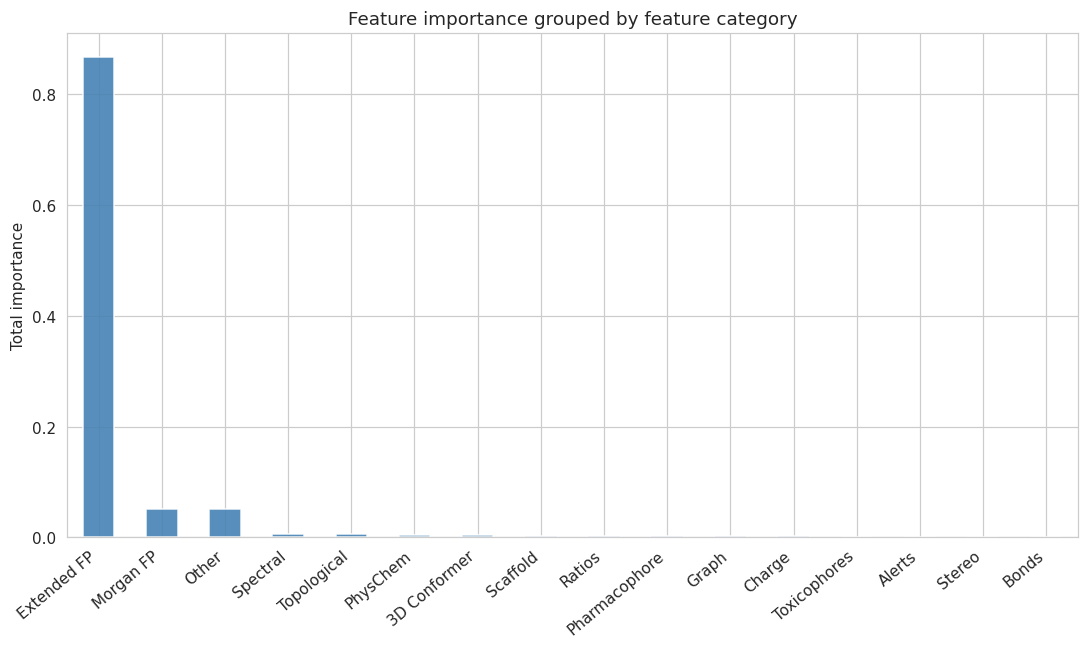

In [125]:
def classify_feature(name):
    n = name.lower()
    if n.startswith('morgan'):        return 'Morgan FP'
    if n.startswith('xfp_') or n.startswith('xfp2_'): return 'Extended FP'
    if n.startswith('maccs'):         return 'MACCS'
    if n.startswith('avalon'):        return 'Avalon'
    if n.startswith('atompair') or 'atompair' in n: return 'AtomPair'
    if n.startswith('torsion') or 'torsion' in n:    return 'Torsion'
    if n.startswith('rdk') or n.startswith('rdkit'): return 'RDKit FP'
    if n.startswith('mqn'):           return 'MQN'
    if n.startswith('alert_'):        return 'Alerts'
    if n.startswith('xtox_'):         return 'Toxicophores'
    if n.startswith('gasteiger') or n.startswith('formal') or n.startswith('num_'): return 'Charge'
    if n.startswith('graph_'):        return 'Graph'
    if n.startswith('ratio_') or n.startswith('lipophilic') or n.startswith('ligand'): return 'Ratios'
    if n.startswith('conf_'):         return '3D Conformer'
    if n.startswith('spec_'):         return 'Spectral'
    if n.startswith('topo_'):         return 'Topological'
    if n.startswith('ph_'):           return 'Pharmacophore'
    if n.startswith('px_'):           return 'PhysChem'
    if n.startswith('scaf_'):         return 'Scaffold'
    if n.startswith(('n_stereo','is_chiral','stereo_','has_multiple')): return 'Stereo'
    if n.startswith(('n_bonds','n_single','ratio_','n_C_')): return 'Bonds'
    if n.startswith('has_') or n.startswith('count_'): return 'Substructure'
    return 'Other'

# Use XGBoost built-in importance and group
builtin_imp = pd.Series(
    pipe.named_steps['clf'].feature_importances_,
    index=X_full_final.columns
)
groups = builtin_imp.groupby(classify_feature).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
groups.plot(kind='bar', ax=ax, color='steelblue', alpha=0.9)
ax.set_ylabel('Total importance')
ax.set_title('Feature importance grouped by feature category')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Descriptor distributions by class (violin)**

/tmp/ipykernel_1056/3474459357.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1056/3474459357.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1056/3474459357.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1056/3474459357.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1056/3474459357.py:12: FutureWarning:



Passing `palette` without assigning `hue` is depreca

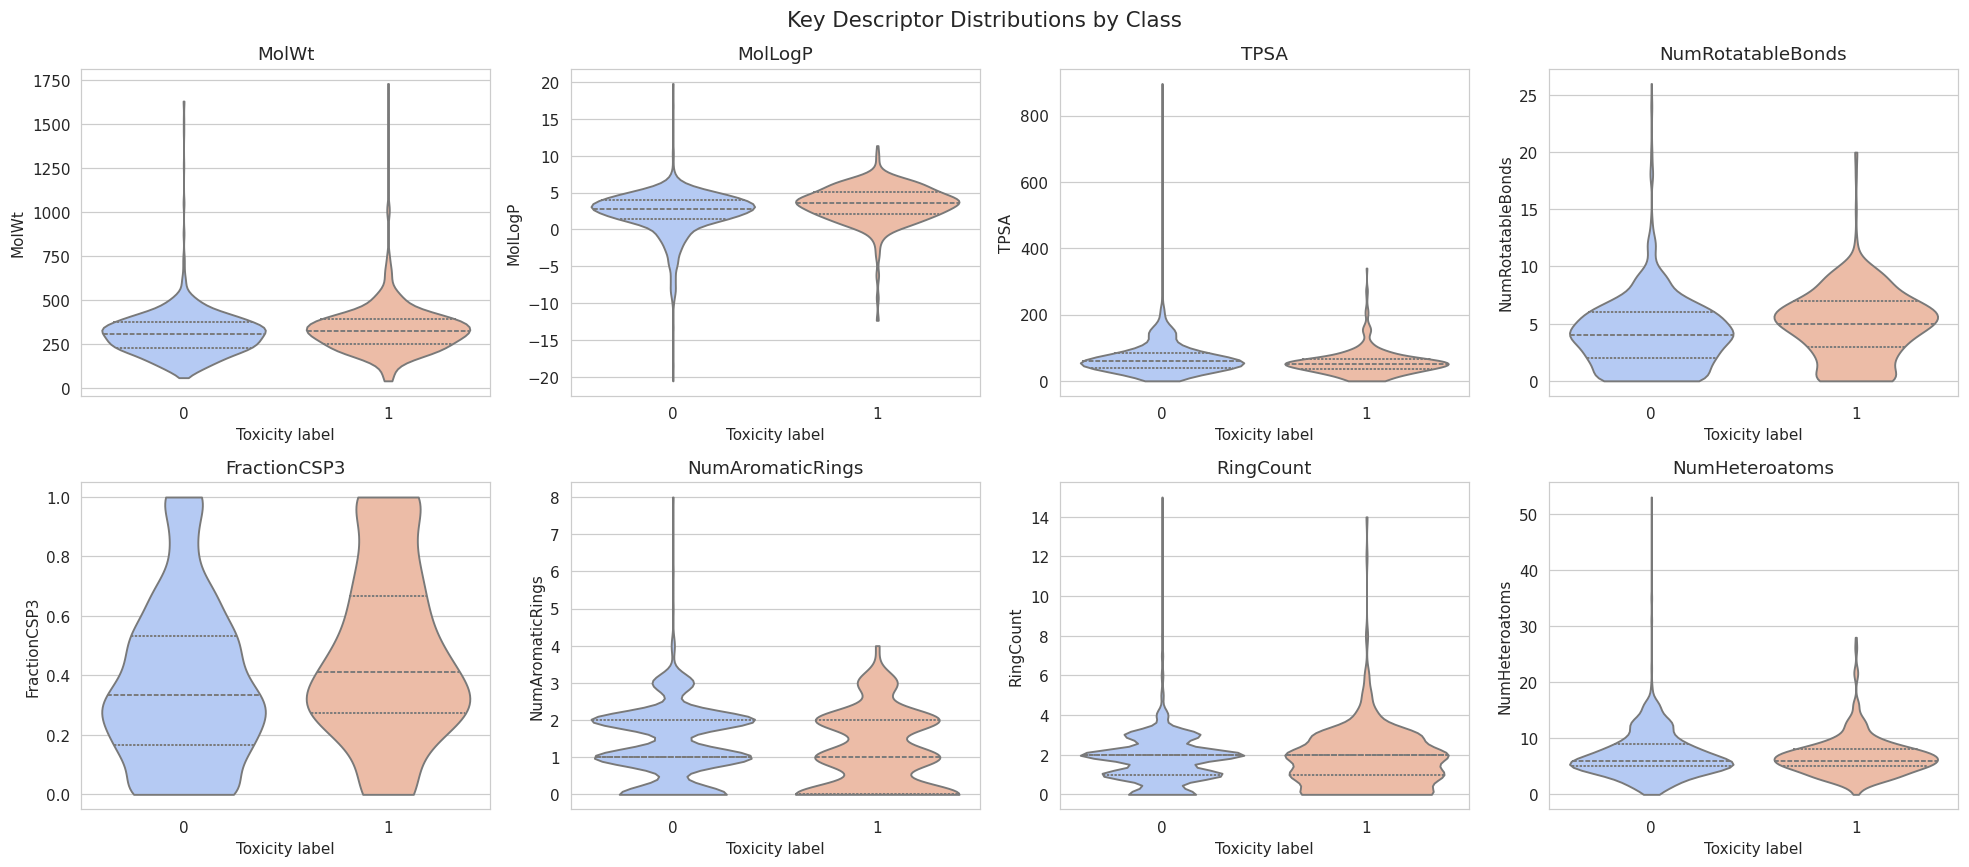

In [127]:
descriptors_to_plot = [
    'MolWt', 'MolLogP', 'TPSA', 'NumRotatableBonds',
    'FractionCSP3', 'NumAromaticRings', 'RingCount', 'NumHeteroatoms',
]
descriptors_to_plot = [c for c in descriptors_to_plot if c in X_full_final.columns]

plot_df = X_full_final[descriptors_to_plot].copy()
plot_df['label'] = y

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), descriptors_to_plot):
    sns.violinplot(data=plot_df, x='label', y=col, ax=ax,
                   palette='coolwarm', inner='quartile', cut=0)
    ax.set_title(col)
    ax.set_xlabel('Toxicity label')

plt.suptitle('Key Descriptor Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

**UMAP colored by agrochemical class**

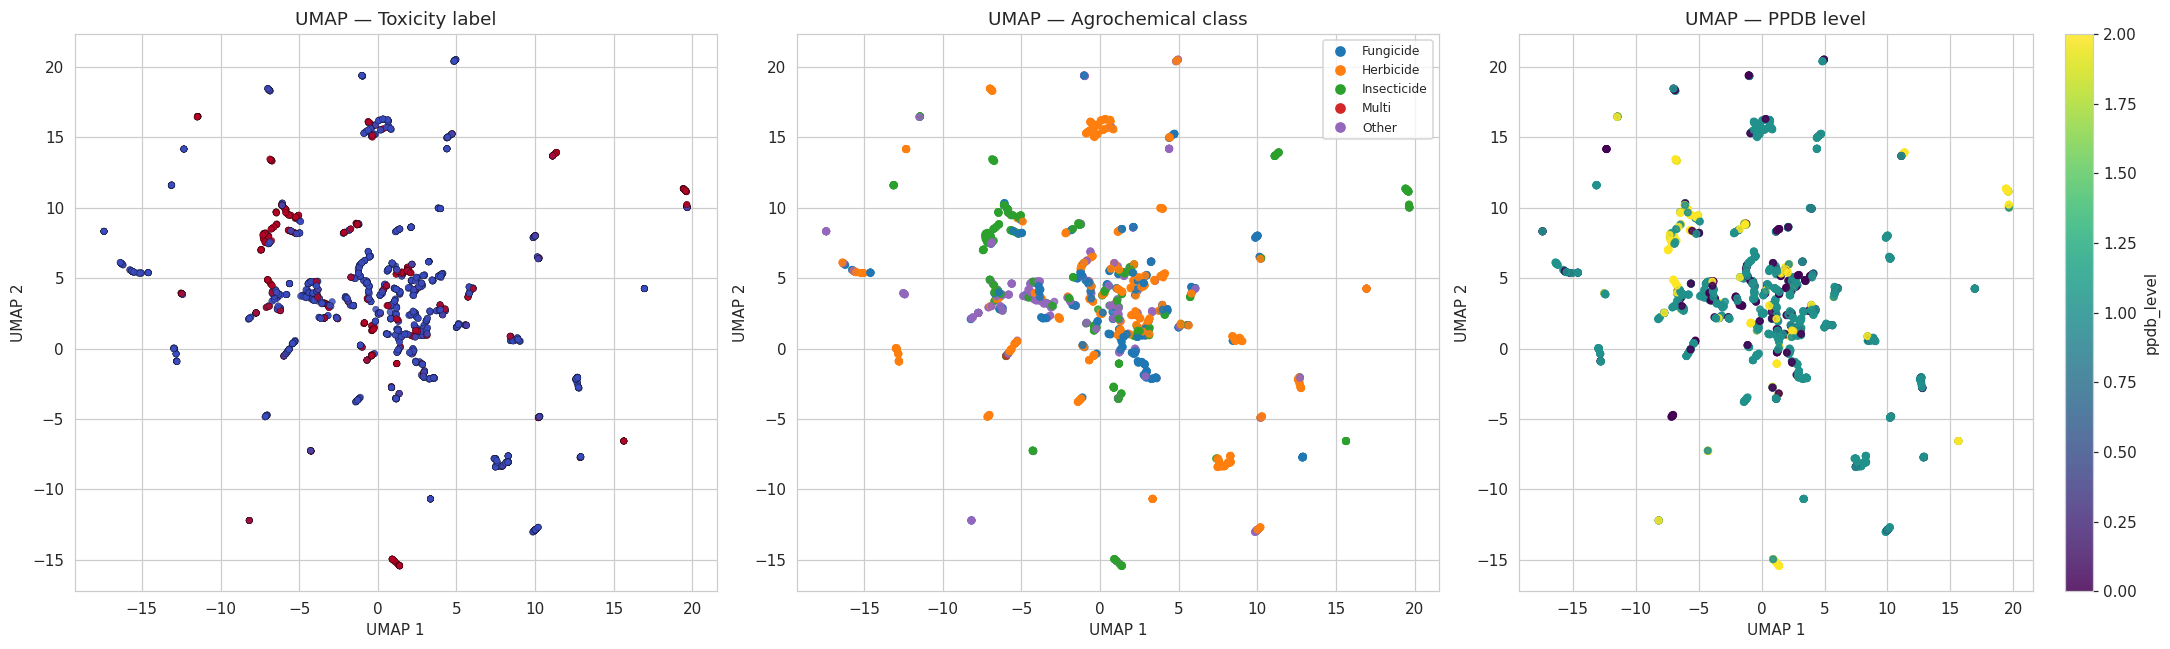

In [128]:
# Reuse X_umap2 / X_umap3 from earlier (aligned to y)
if 'agro_class' not in df_clean.columns:
    def _agro(row):
        c = []
        if row.get('herbicide', 0) == 1: c.append('H')
        if row.get('fungicide', 0) == 1: c.append('F')
        if row.get('insecticide', 0) == 1: c.append('I')
        if row.get('other_agrochemical', 0) == 1: c.append('O')
        return ''.join(c) or 'U'
    df_clean['agro_class'] = df_clean.apply(_agro, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) UMAP by label
axes[0].scatter(X_umap2[:, 0], X_umap2[:, 1], c=y, cmap='coolwarm',
                s=18, alpha=0.85, edgecolors='k', linewidths=0.2)
axes[0].set_title('UMAP — Toxicity label')

# (b) UMAP by agro class
classes = df_clean['agro_class'].astype(str).values
unique = sorted(set(classes))
palette = sns.color_palette('tab10', len(unique))
cmap = {u: palette[i] for i, u in enumerate(unique)}
colors = [cmap[c] for c in classes]
axes[1].scatter(X_umap2[:, 0], X_umap2[:, 1], c=colors, s=18, alpha=0.85)
axes[1].set_title('UMAP — Agrochemical class')
handles = [plt.Line2D([], [], marker='o', linestyle='',
                      color=cmap[u], label=u) for u in unique]
axes[1].legend(handles=handles, fontsize=8, loc='best')

# (c) UMAP by ppdb_level (if available)
if 'ppdb_level' in df_clean.columns:
    levels = df_clean['ppdb_level'].fillna(-1).astype(int).values
    sc = axes[2].scatter(X_umap2[:, 0], X_umap2[:, 1],
                         c=levels, cmap='viridis', s=18, alpha=0.85)
    fig.colorbar(sc, ax=axes[2], label='ppdb_level')
    axes[2].set_title('UMAP — PPDB level')
else:
    axes[2].text(0.5, 0.5, 'ppdb_level not available',
                 ha='center', va='center', transform=axes[2].transAxes)

for ax in axes:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

**t-SNE colored by toxicity type**

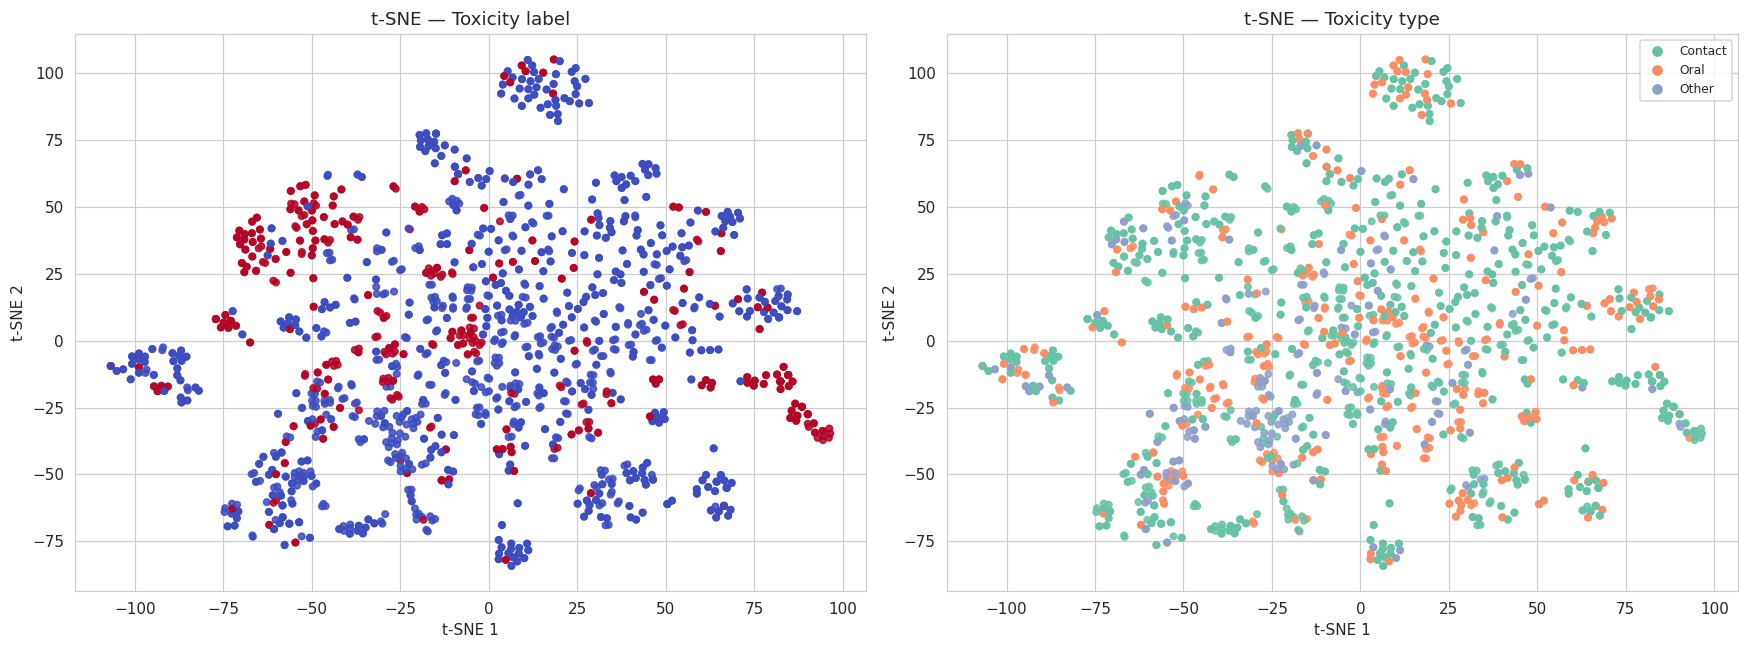

In [129]:
if 'toxicity_type' in df_clean.columns:
    ttype = df_clean['toxicity_type'].astype(str).values
    unique_t = sorted(set(ttype))
    pal_t = sns.color_palette('Set2', len(unique_t))
    cmap_t = {u: pal_t[i] for i, u in enumerate(unique_t)}
    colors_t = [cmap_t[t] for t in ttype]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=y, cmap='coolwarm',
                    s=18, alpha=0.85)
    axes[0].set_title('t-SNE — Toxicity label')

    axes[1].scatter(X_tsne2[:, 0], X_tsne2[:, 1], c=colors_t, s=18, alpha=0.85)
    axes[1].set_title('t-SNE — Toxicity type')
    handles = [plt.Line2D([], [], marker='o', linestyle='',
                          color=cmap_t[u], label=u) for u in unique_t]
    axes[1].legend(handles=handles, fontsize=8, loc='best')

    for ax in axes:
        ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.show()

**Molecular similarity network**

Network: 1842 nodes, 2915 edges


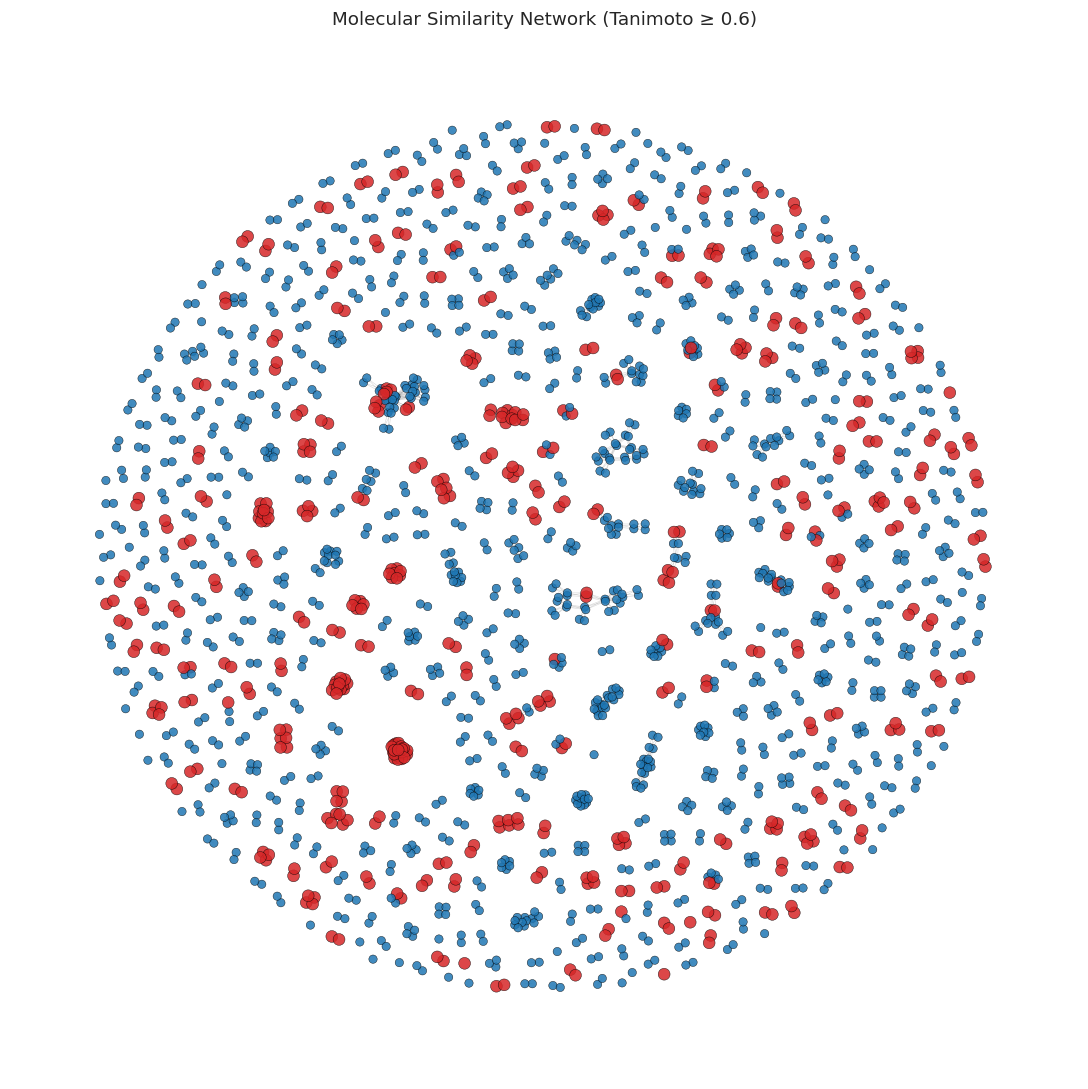

In [130]:
import networkx as nx
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = []
for smi in smiles_list:
    m = Chem.MolFromSmiles(smi)
    fps.append(gen.GetFingerprint(m) if m else None)

SIM_THRESH = 0.6
G = nx.Graph()
for i in range(N):
    G.add_node(i)

# Compute similarities (O(N²) is fine for 925)
for i in range(N):
    if fps[i] is None: continue
    for j in range(i + 1, N):
        if fps[j] is None: continue
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        if sim >= SIM_THRESH:
            G.add_edge(i, j, weight=sim)

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Layout
pos = nx.spring_layout(G, seed=42, k=0.25, iterations=80)

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.4, ax=ax)
colors = ['#1f77b4' if lbl == 0 else '#d62728' for lbl in y]
sizes  = [30 if lbl == 0 else 60 for lbl in y]
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes,
                       edgecolors='k', linewidths=0.3, alpha=0.85, ax=ax)
ax.set_title(f'Molecular Similarity Network (Tanimoto ≥ {SIM_THRESH})')
ax.axis('off')
plt.tight_layout()
plt.show()

**Scaffold network (Murcko scaffolds)**

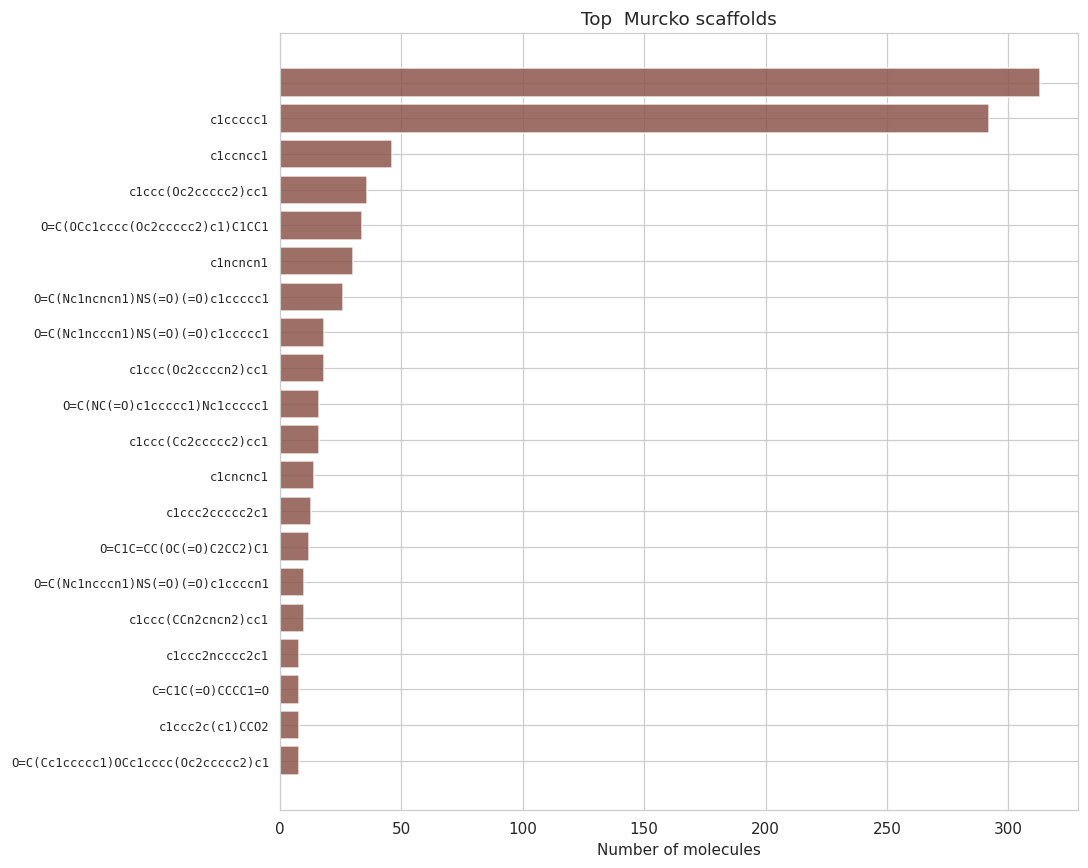

In [132]:
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter

scaffolds = []
for smi in smiles_list:
    m = Chem.MolFromSmiles(smi)
    if m is None:
        scaffolds.append('')
        continue
    try:
        scaffolds.append(MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False))
    except Exception:
        scaffolds.append('')

df_clean['scaffold'] = scaffolds

top_scaffolds = Counter(scaffolds).most_common(20)
labels, counts = zip(*top_scaffolds)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(labels))
ax.barh(y_pos, counts, color='#8c564b', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels([s if len(s) <= 40 else s[:37] + '...' for s in labels],
                   fontsize=8, family='monospace')
ax.invert_yaxis()
ax.set_xlabel('Number of molecules')
ax.set_title('Top  Murcko scaffolds')
plt.tight_layout()
plt.show()

**Toxicity type distribution**

/tmp/ipykernel_1056/3635701585.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




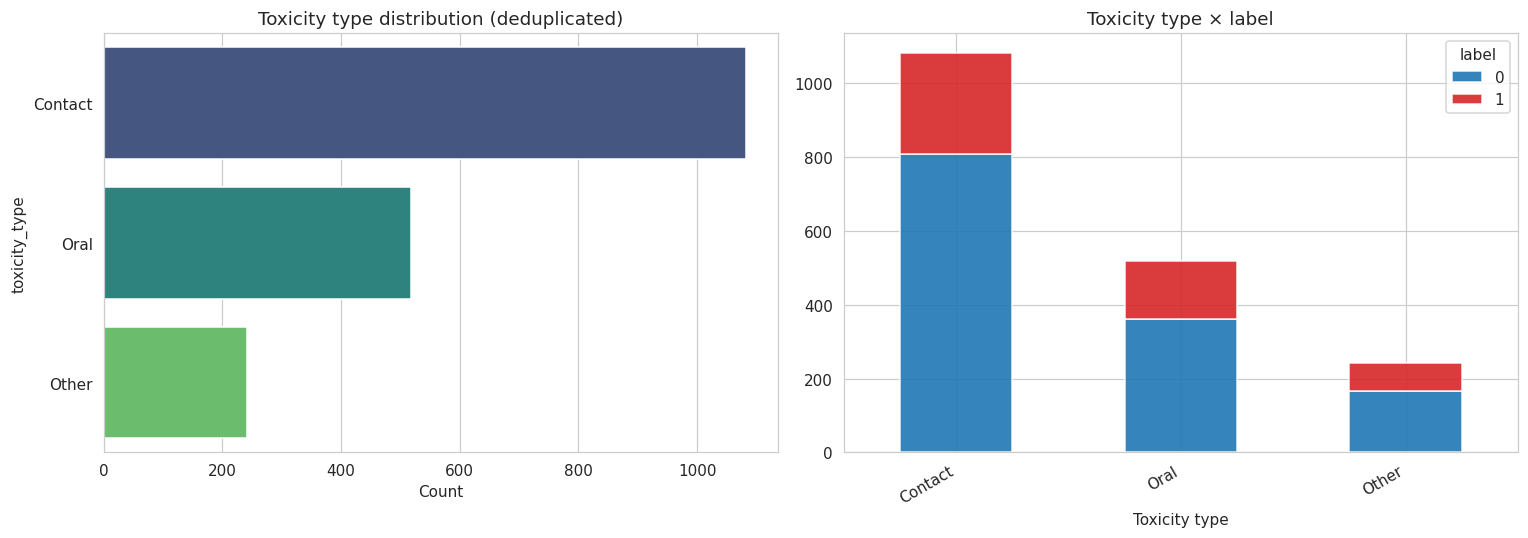

In [134]:
if 'toxicity_type' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    counts = df_clean['toxicity_type'].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=axes[0],
                palette='viridis')
    axes[0].set_title('Toxicity type distribution (deduplicated)')
    axes[0].set_xlabel('Count')

    ct = pd.crosstab(df_clean['toxicity_type'], df_clean['label'])
    ct.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#1f77b4', '#d62728'], alpha=0.9)
    axes[1].set_title('Toxicity type × label')
    axes[1].set_xlabel('Toxicity type')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

**Chemical-space density plot**

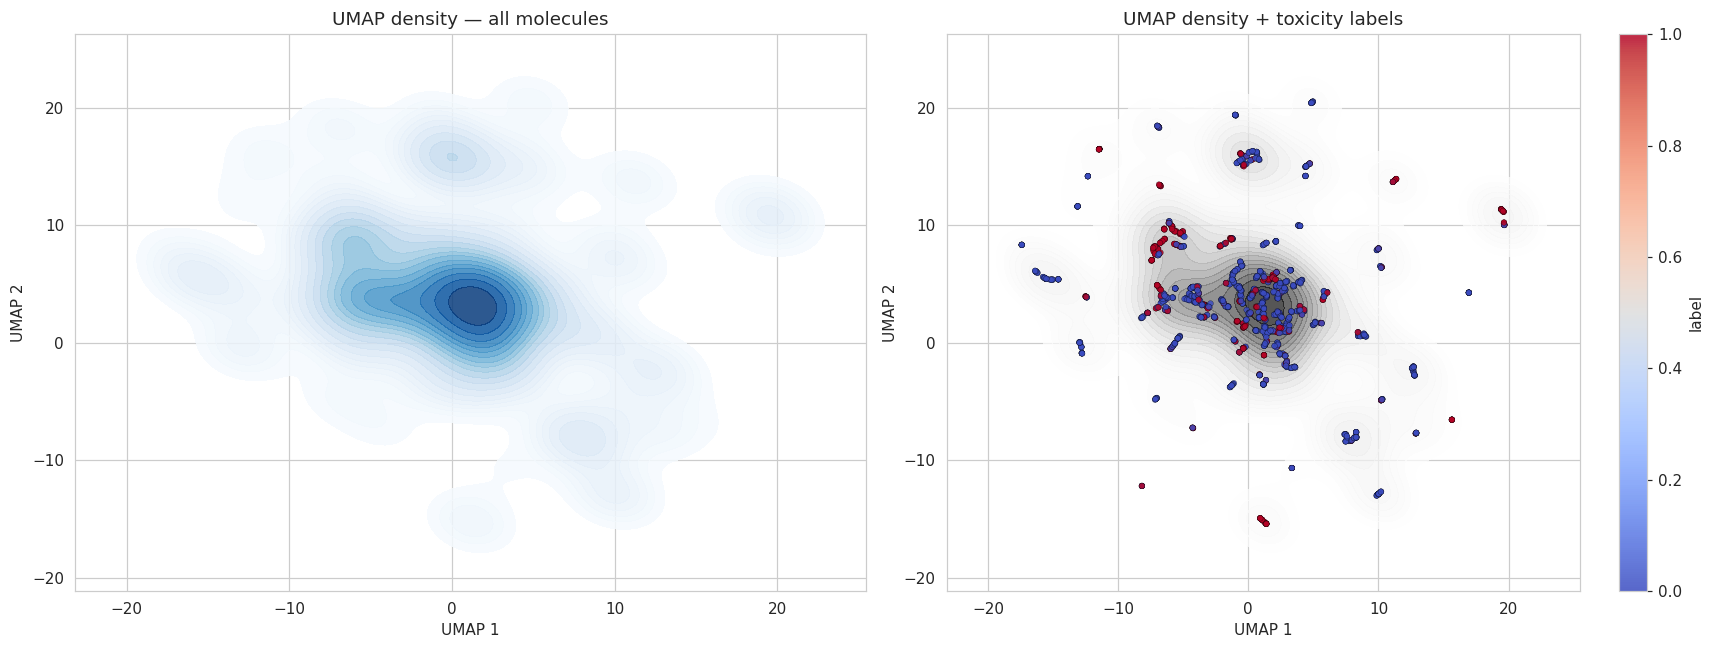

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) 2D density of all points
sns.kdeplot(x=X_umap2[:, 0], y=X_umap2[:, 1],
            fill=True, cmap='Blues', levels=20, ax=axes[0], alpha=0.85)
axes[0].set_title('UMAP density — all molecules')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

# (b) toxicity label overlaid on density
sns.kdeplot(x=X_umap2[:, 0], y=X_umap2[:, 1],
            fill=True, cmap='Greys', levels=20, ax=axes[1], alpha=0.7)
sc = axes[1].scatter(X_umap2[:, 0], X_umap2[:, 1],
                     c=y, cmap='coolwarm', s=14, alpha=0.85,
                     edgecolors='k', linewidths=0.2)
fig.colorbar(sc, ax=axes[1], label='label')
axes[1].set_title('UMAP density + toxicity labels')
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

 **SHAP dependence plots (top 4 features)**

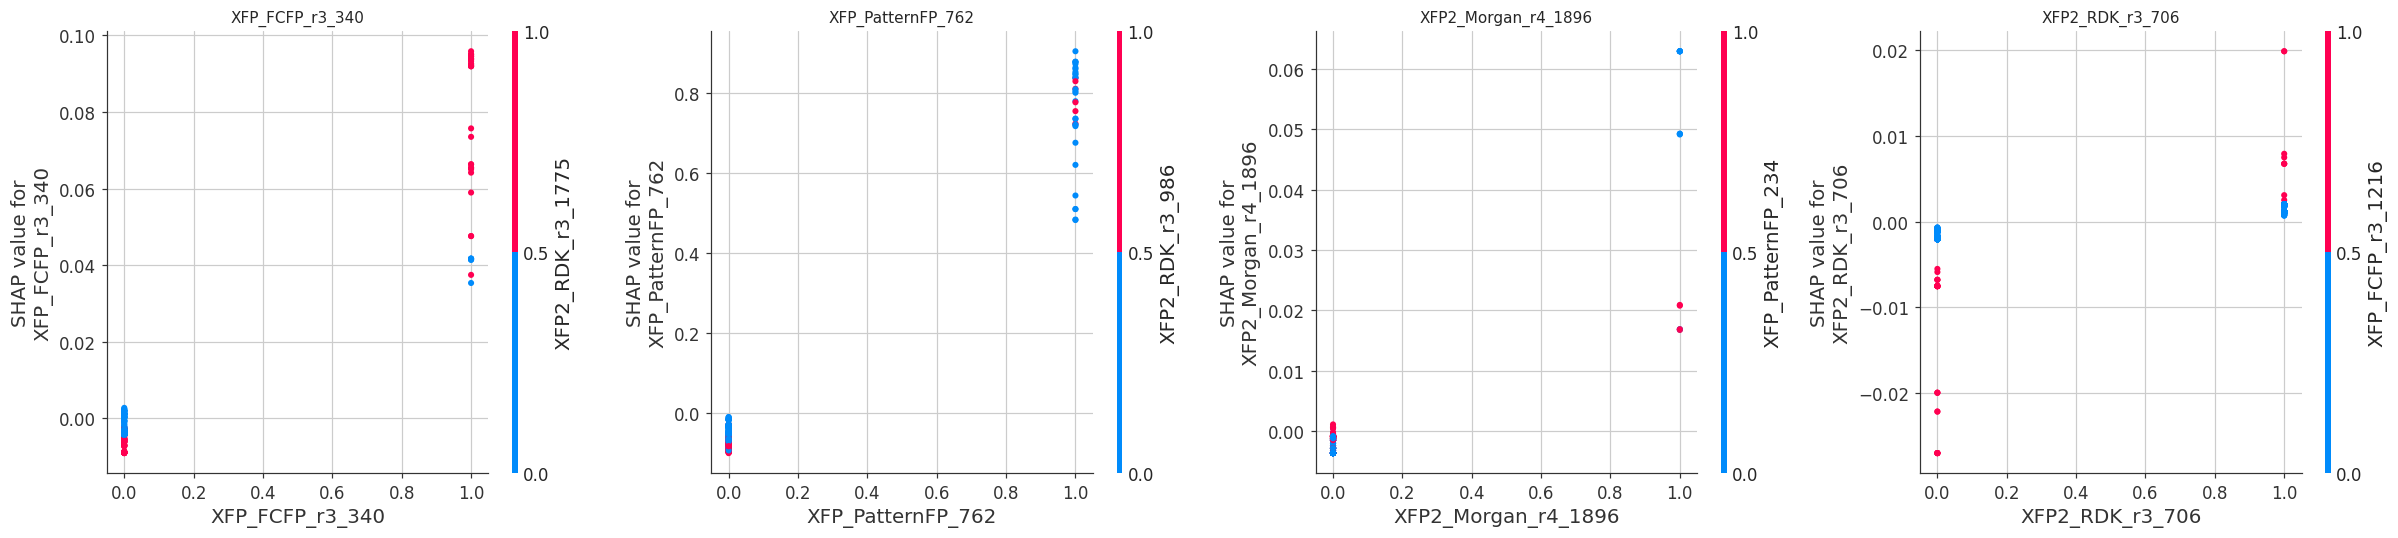

In [136]:
import shap

explainer = shap.TreeExplainer(pipe.named_steps['clf'])
# Impute test set the same way as training
X_te_imp = pd.DataFrame(
    pipe.named_steps['imputer'].transform(X_te),
    columns=X_te.columns,
    index=X_te.index
)

shap_vals = explainer.shap_values(X_te_imp)

top4 = pd.Series(pipe.named_steps['clf'].feature_importances_,
                 index=X_full_final.columns).sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, feat in zip(axes, top4):
    shap.dependence_plot(feat, shap_vals, X_te_imp,
                         ax=ax, show=False)
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.show()

**SHAP force plot (individual predictions)**


--- Most confidently toxic ---
Molecule: Pentacosane
True label: 1 | Predicted P(toxic) = 1.000


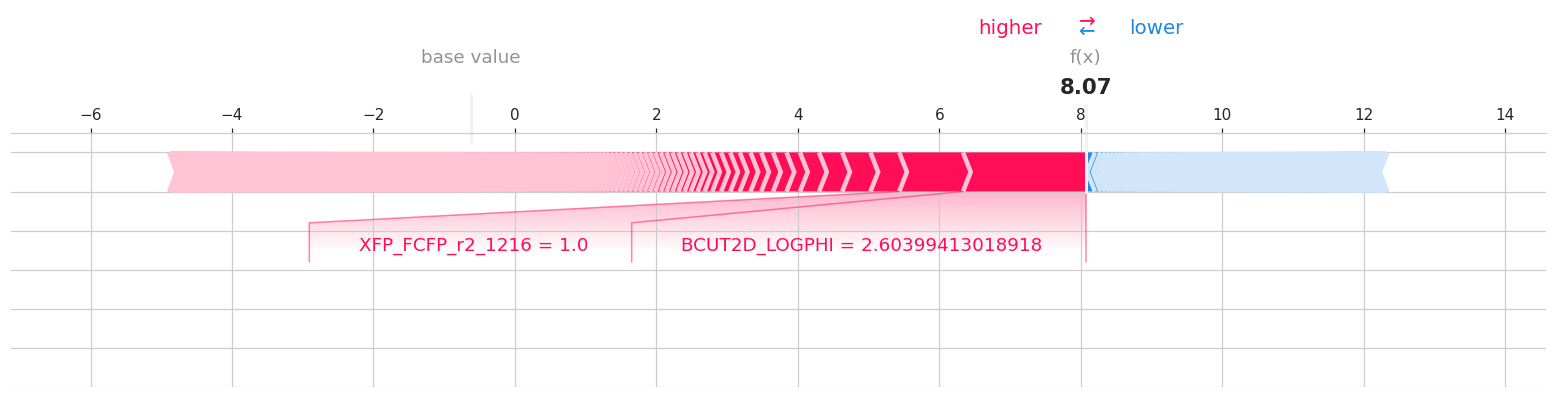

None


--- Most confidently non-toxic ---
Molecule: Methyl cyclohexenone
True label: 0 | Predicted P(toxic) = 0.000


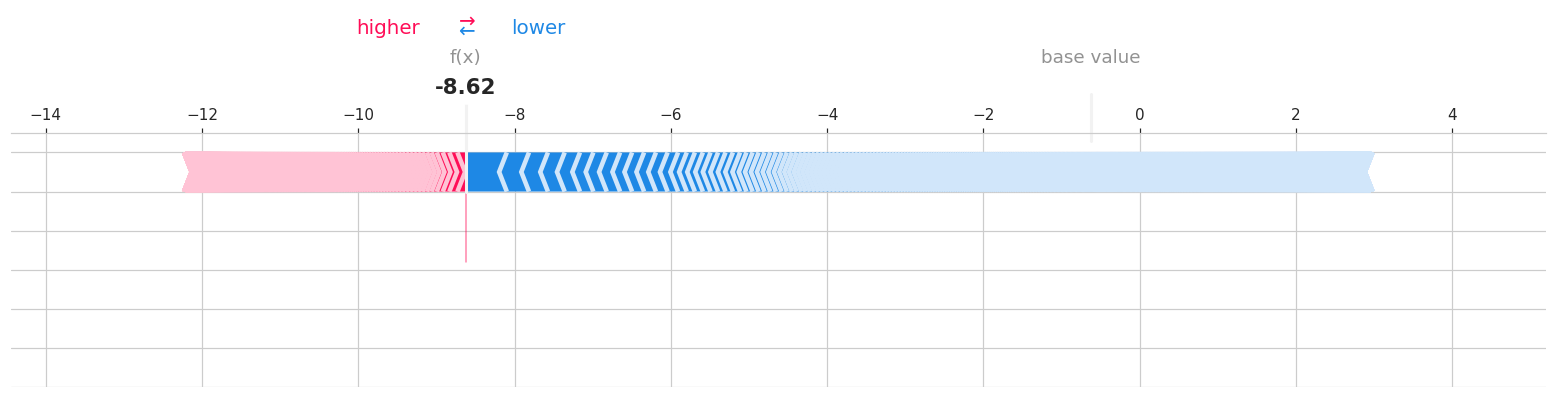

None


--- Most borderline ---
Molecule: Bensulfuron-methyl (Ref: DPX F5384)
True label: 0 | Predicted P(toxic) = 0.375


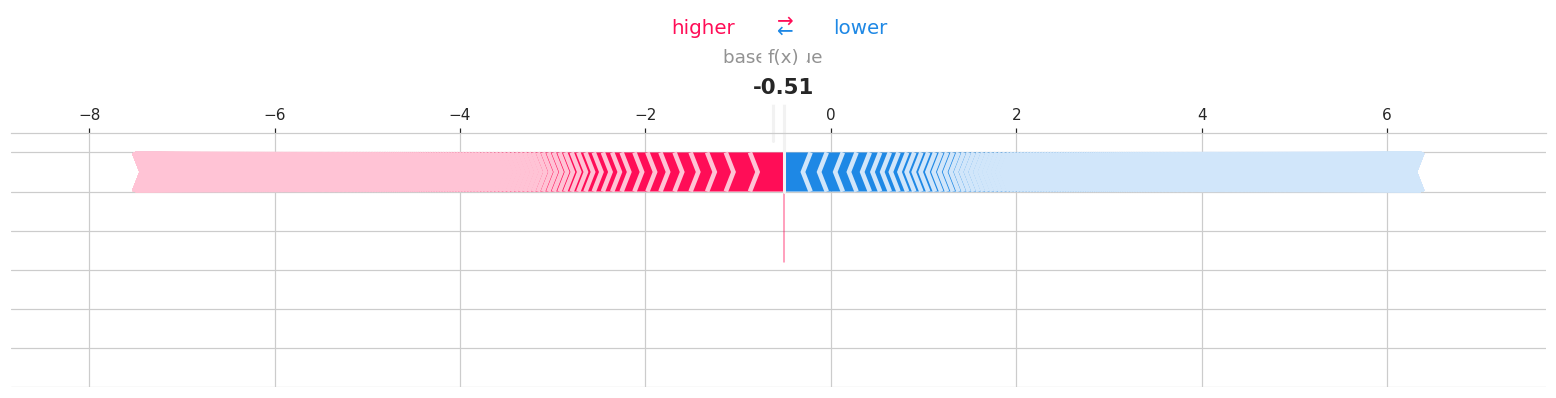

None

In [137]:
# Show 3 individual cases: confidently toxic, confidently non-toxic, borderline
idx_toxic = np.argmax(p_test)
idx_nontoxic = np.argmin(p_test)
idx_border = np.argmin(np.abs(p_test - 0.5))

shap.initjs()
for label, idx in [('Most confidently toxic',  idx_toxic),
                   ('Most confidently non-toxic', idx_nontoxic),
                   ('Most borderline', idx_border)]:
    print(f"\n--- {label} ---")
    print(f"Molecule: {df_clean['name'].iloc[idx] if idx < len(df_clean) else 'n/a'}")
    print(f"True label: {y_te[idx]} | Predicted P(toxic) = {p_test[idx]:.3f}")
    display(shap.force_plot(
        explainer.expected_value,
        shap_vals[idx],
        X_te_imp.iloc[idx],
        matplotlib=True, figsize=(18, 3)
    ))